In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from tqdm import tqdm
import numpy as np
import scipy
from tqdm.notebook import tqdm
import time
import psutil
from datetime import datetime
from functools import wraps
from joblib import Parallel, delayed
hartree = 27.2113845

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from matplotlib.collections import LineCollection
from matplotlib.ticker import MultipleLocator
import os
hartree = 27.2113845
hatree = 27.2113845
np.set_printoptions(precision=8)
np.set_printoptions(suppress=True, floatmode='fixed')
from matplotlib import rcParams
config = {
    "font.family":'serif',
    "font.size": 10,
    "mathtext.fontset":'stix',
    "font.serif": ['Times New Roman'], # simsun字体中文版就是宋体
}

plt.rc('font',family='Times New Roman')

rcParams.update(config)
def smooth_curve(x, y, num_points=1000):
    """
    Smooth a curve using interpolation.

    Parameters:
        x (array-like): Array of x coordinates.
        y (array-like): Array of y coordinates.
        num_points (int): Number of points for interpolation (default: 1000).

    Returns:
        array-like: Smoothed y coordinates.
    """
    f = interp1d(x, y, kind='cubic')
    x_smooth = np.linspace(x.min(), x.max(), num_points)
    return x_smooth, f(x_smooth)

def plot_band_structure_new_(ax, x, bands, values,lw, label, linestyle, offset, num,loc,vmin,vmax,cmap='viridis_r',bar_show=False,**kwargs):
    """
    Plot a band structure with values represented by color.

    Parameters:
        x (array-like): Array of x coordinates.
        bands (array-like): 2D array of y coordinates representing the bands.
        values (array-like): Array of values corresponding to each point in bands.

    Returns:
        None
    """
    # Create line segments for each band
    segments_list = []
    for band in bands.T:
        points = np.array([x, band]).T.reshape(-1, 1, 2)
        segments_list.append(np.concatenate([points[:-1], points[1:]], axis=1))

    # Create a colormap and normalize
    cmap = plt.get_cmap(cmap)
    # cmap = plt.get_cmap('viridis')
    if vmin == 0 and vmax == 1:
        norm = plt.Normalize(np.min(values), np.max(values))
    else:
        norm = plt.Normalize(vmin, vmax)
    print("shape of segments_list",np.shape(segments_list))
    # Create subplots
    # fig, ax = plt.subplots()

    # Loop through each set of line segments and create LineCollection
    # for i, segments in enumerate(segments_list):
    #     if i == offset:
    #         print("shit")
    #         lc = LineCollection(segments, cmap=cmap, norm=norm, label=label)
    #         lc = LineCollection(segments, cmap=cmap, norm=norm)
    #         lc.set_array(values[i])
    #         lc.set_linewidth(1)
    #         line = ax.add_collection(lc)
    #     elif i < offset + num:
    #         lc = LineCollection(segments, cmap=cmap, norm=norm)
    #         lc.set_array(values[i])
    #         lc.set_linewidth(1)
    #         ax.add_collection(lc)
        # Loop through each set of line segments and create LineCollection
    for i, segments in enumerate(segments_list):
        lc = LineCollection(segments, cmap=cmap, norm=norm)
        lc.set_array(values[:, i])  # 设置每个点的值
        lc.set_linewidth(lw)
        ax.add_collection(lc)
        if i == offset:
            lc.set_label(label)  # 设置标签

    # for i in range(num):
    #     if i == num-1:
    #         ax.plot(x, bands[:,i+offset], color=cmap(norm(np.mean(values[:,i+offset]))), linewidth=lw, linestyle=linestyle, label=label)
    #     else:
    #         ax.plot(x, bands[:,i+offset], color=cmap(norm(np.mean(values[:,i+offset]))), linewidth=lw, linestyle=linestyle)
    

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    if bar_show:
        cbar = plt.colorbar(sm, ax=ax)
        # cbar.set_label('Values')
        print(ax.get_position())
        # cbar.ax.set_position(loc)
        # 设置颜色条的刻度间隔
        cbar.locator = MultipleLocator(0.02)
        cbar.update_ticks()
    # plt.show()
    # cbar.ax.tick_params(labelsize=12)

    # Add colorbar
    # cbar = fig.colorbar(line, ax=ax)
    # cbar.set_label('Values')

    # Set axis limits
    # ax.set_xlim(x.min(), x.max())
    # ax.set_ylim(np.min(bands)*0-0.12, np.max(bands)+0.02)

def plot_band_structure_new(ax, x, bands, values, lw, label, linestyle, offset, num, loc, vmin=0, vmax=1, cmap='viridis_r',bar_show=False,**kwargs):
    """
    Plot a band structure with values represented by color.

    Parameters:
        ax (matplotlib.axes.Axes): The axes on which to plot.
        x (array-like): Array of x coordinates.
        bands (array-like): 2D array of y coordinates representing the bands.
        values (array-like): Array of values corresponding to each point in bands.
        lw (float): Line width for the bands.
        label (str): Label for the plot.
        linestyle (str): Line style for the bands.
        offset (float): Offset value for shifting the bands.
        num (int): Number of bands to plot.
        loc (str): Location for the legend.
        vmin (float): Minimum value for normalization.
        vmax (float): Maximum value for normalization.
        cmap (str): Colormap for representing values.

    Returns:
        None
    """
    # Ensure values are in the correct shape
    values = np.array(values)

    # Create a colormap and normalize
    cmap = plt.get_cmap(cmap)
    norm = plt.Normalize(vmin, vmax)

    for i in range(num):
        band = bands[:, i] + offset
        proj = values[:, i]

        # Create line segments for each band
        points = np.array([x, band]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        # Create a LineCollection for the current band
        lc = LineCollection(segments, cmap=cmap, norm=norm)
        lc.set_array(proj)
        lc.set_linewidth(lw)
        lc.set_linestyle(linestyle)
        if i == 0:
            lc.set_label(label)
        ax.add_collection(lc)

    # Add colorbar
    if bar_show:
        cbar = plt.colorbar(lc, ax=ax)
    # cbar.set_label('Projection Intensity')

    # Set labels and title
    # ax.set_xlabel('k-point')
    # ax.set_ylabel('Energy (eV)')
    ax.set_title(label)

    # Adjust axis limits
    # ax.set_xlim(x.min(), x.max())
    # ax.set_ylim(np.min(bands + offset), np.max(bands + offset))

    # Add legend
    # ax.legend(loc=loc)

def plot_band(ax, kx1, band, c="dodgerblue", lw=1.5, linestyle='-', label='', offset=2000, num=200, smooth=False,num_points=1000,values=[],
              proj=False,loc=[0.9,0,0.02,0.5],vmin=0,vmax=1,cmap='viridis_r',sca=False,bar_show=False,**kwargs):
    """
    Plot a band structure.

    Parameters:
        ax (Axes): Matplotlib Axes object to plot on.
        kx1 (array-like): Array of x coordinates.
        band (array-like): 2D array of y coordinates representing the bands.
        c (str): Color of the curve (default: 'dodgerblue').
        lw (float): Line width (default: 1.5).
        linestyle (str): Line style (default: '-').
        label (str): Label for the curve (default: 'TAPW').
        offset (int): Offset index (default: 2000).
        num (int): Number of curves to plot (default: 200).
        smooth (bool): Whether to apply smoothing (default: False).

    Returns:
        None
    """
    # for i in range(num):
        # y = band[:, offset + i]
        # if smooth:
        #     y = smooth_curve(kx1, y, num_points=num_points)
        # if i == 0:
        #     ax.plot(kx1, y, c=c, linestyle=linestyle, lw=lw, label=label)
        # else:
        #     ax.plot(kx1, y, c=c, linestyle=linestyle, lw=lw)
    if smooth:
        bands_smooth = []
        for i in range(np.shape(band)[1]):
            kx1_smooth, y_smooth = smooth_curve(kx1, band[:, i], num_points=num_points)
            bands_smooth.append(y_smooth)
        bands = np.array(bands_smooth).T
        kx = kx1_smooth
    else:
        bands = band
        kx = kx1
    
    if proj:
        plot_band_structure_new(ax, kx, bands, values, lw, label,linestyle,offset,num,loc,vmin,vmax,cmap=cmap,bar_show=bar_show,**kwargs)
    else:
        if sca:
            for i in range(num):
                if len(label)>0:
                    if i == num-1:
                        ax.scatter(kx, bands[:,i+offset], c=c, s=lw, label=label, **kwargs)
                    else:
                        ax.scatter(kx, bands[:,i+offset], c=c, s=lw, **kwargs) 
                else:
                    ax.scatter(kx, bands[:,i+offset], c=c, s=lw, **kwargs)
        else:
            for i in range(num):
                if len(label)>0:
                    if i == num-1:
                        ax.plot(kx, bands[:,i+offset], c=c, linestyle=linestyle, lw=lw, label=label, **kwargs)
                    else:
                        ax.plot(kx, bands[:,i+offset], c=c, linestyle=linestyle, lw=lw, **kwargs) 
                else:
                    ax.plot(kx, bands[:,i+offset], c=c, linestyle=linestyle, lw=lw, **kwargs)

def set_pic(ax,ymin,ymax,ylim = True,meV=True,xticks =np.array([0, 0.125, 0.197, 0.341]),legend_show=True,transparent_flag = False,
            xlabels = [r'${\Gamma}_{\mathrm{M}}$', r'${\mathrm{M}}_{\mathrm{M}}$', r'${\mathrm{K}}_{\mathrm{M}}$', r'${\Gamma}_{\mathrm{M}}$'], 
            title = '4.41 Bilayer tMoTe2 w SOC G vally',save = False,savepath = '',legend_fontsize = 9):
    # Add reference lines
    ax.plot([0, np.max(xticks)], [0, 0], c='black', lw=0.6, linestyle='-',alpha=0.4)
    for i in range(len(xticks)-2):
        ax.plot([xticks[i+1], xticks[i+1]], [ymin-0.1, ymax + 0.1], lw=0.6,c='black', linestyle='-',alpha=0.4)
    # ax.plot([0.125, 0.125], [ymin-0.1, ymax + 0.1], lw=1,c='black', linestyle='--')
    # ax.plot([0.197, 0.197], [ymin-0.1, ymax + 0.1], lw=1,c='black', linestyle='--')
    # ax.plot([0.341, 0.341], [emin, emax + 0.01], c='blue', linestyle='--')

    # Set y-axis limits
    if ylim:
        ax.set_ylim(ymin, ymax)

    # Set x-axis limits and ticks
    ax.set_xlim(np.min(xticks), np.max(xticks))
    ax.set_xticks(xticks)
    print(xticks)
    print(xlabels)
    scale = 1.5
    ax.set_xticklabels(xlabels,fontsize=11*scale,fontfamily='Times New Roman')  # Bold x-axis tick labels
    if meV:
        # plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0f}'.format(x*1000)))
        ax.set_ylabel('Energy (meV)', fontsize=12*scale,fontfamily='Times New Roman')  # Bold y-axis label
    else:
        ax.set_ylabel('Energy (eV)', fontsize=12*scale,fontfamily='Times New Roman')  # Bold y-axis label 

    # ax.set_yticks(fontproperties = 'Times New Roman', size = 12)
    # ax.tick_params(axis='y', labelsize=12, labelfamily='Times New Roman')
    y1_label = ax.get_yticklabels() 
    [y1_label_temp.set_fontname('Times New Roman') for y1_label_temp in y1_label]
    [y1_label_temp.set_fontsize(11*scale) for y1_label_temp in y1_label]
    [y1_label_temp.set_position((0.01, y1_label_temp.get_position()[1])) for y1_label_temp in y1_label]  # Adjust the x position



    # Set plot title
    ax.set_title(title,fontsize=12*scale,fontfamily= 'Times New Roman')
    if legend_show:
        legend = ax.legend(loc='upper right',fontsize=legend_fontsize*scale)
        labelss = legend.get_texts()
        [label.set_fontname('Times New Roman') for label in labelss]

    # Show the plot
    if save:
        ax.set_facecolor('none')
        plt.savefig(savepath, dpi=300,bbox_inches='tight',transparent=transparent_flag)
    plt.show()

Nk = 11
kx1 = np.hstack(
    (np.hstack((np.linspace(0,0.125,Nk+1),np.linspace(0.125,0.197177,Nk+1)[1:])),
    np.linspace(0.197177,0.341521,Nk+1)[1:]))
"""  0.000000   0.000000   0.000000   0.000000
  0.333333   0.333333   0.000000   0.065313
  0.666667  -0.333333   0.000000   0.130626
  0.000000   0.500000   0.000000   0.217027
  0.500000   0.000000   0.000000   0.273589
  0.500000  -0.500000   0.000000   0.330152 """
kx_GK1K2M1M2M3 = np.array([0.000000, 0.065313, 0.130626, 0.217027, 0.273589, 0.330152])
Nk = 20
kx61 = np.hstack(
    (np.hstack((np.linspace(0,0.125,Nk+1),np.linspace(0.125,0.197177,Nk+1)[1:])),
    np.linspace(0.197177,0.341521,Nk+1)[1:]))

Nk = 6
kx19 = np.hstack(
    (np.hstack((np.linspace(0,0.125,Nk+1),np.linspace(0.125,0.197177,Nk+1)[1:])),
    np.linspace(0.197177,0.341521,Nk+1)[1:]))


In [4]:
def timing_decorator_factory(process_id):
    def timing_decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            if process_id == 0:
                start_time = time.time()
                process = psutil.Process()
                mem_before = process.memory_info().rss / (1024 * 1024 * 1024)  # Convert to GB

                result = func(*args, **kwargs)

                mem_after = process.memory_info().rss / (1024 * 1024 * 1024)  # Convert to GB
                end_time = time.time()
                duration = end_time - start_time
                mem_peak = mem_after - mem_before

                current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                print(f"[{current_time}] Function '{func.__name__}' executed in {duration:.6f} seconds, Memory peak: {mem_peak:.6f} GB")
            else:
                result = func(*args, **kwargs)
            return result
        return wrapper
    return timing_decorator

class KPathGenerator:
    
    def __init__(self, Amat):
        self.Amat = Amat
        self.astar, self.bstar, self.cstar = self.calculate_reciprocal_vectors(Amat)

        self.x_ticks = []
        self.labels_ticks = []
        self.kpoints = []
        self.high_symmetry_points = []
        self.labels = []
        self.segment_points = 0

    @staticmethod
    def calculate_reciprocal_vectors(Amat):
        a, b, c = Amat
        vol = np.dot(a, np.cross(b, c))
        astar = 2 * np.pi * np.cross(b, c) / vol
        bstar = 2 * np.pi * np.cross(c, a) / vol
        cstar = 2 * np.pi * np.cross(a, b) / vol
        return astar, bstar, cstar
    
    def read_and_generate_kpath(self, file_path: str, output_file_path: str) -> None:
        # 读取kpath文件
        with open(file_path, 'r') as input_file:
            lines = input_file.readlines()

        self.segment_points = int(lines[1])
        self.high_symmetry_points = []
        self.labels = []

        for i in range(4, len(lines)):
            coordinates = np.array([float(coord) for coord in lines[i].split()[:3]])
            if len(coordinates) == 3:
                label = lines[i].split()[-1]
                if label in ['GAMMA', '\\GAMMA', 'G']:
                    label = r'$\Gamma$'
                self.high_symmetry_points.append(coordinates)
                self.labels.append(label)

        self.high_symmetry_points = np.array(self.high_symmetry_points)

        # 生成kpath
        Amat_reciprocal = np.array([self.astar, self.bstar, self.cstar])
        x = 0.0
        num_high_symmetry_points = len(self.high_symmetry_points)
        self.x_ticks = []
        self.labels_ticks = []
        self.kpoints = []

        with open(output_file_path, 'w') as output_file:
            self.x_ticks.append(x)
            self.labels_ticks.append(self.labels[0])
            for i in range(int(num_high_symmetry_points / 2)):
                delta = self.distance(
                    self.direct_cart_real(Amat_reciprocal, self.high_symmetry_points[2 * i + 1]),
                    self.direct_cart_real(Amat_reciprocal, self.high_symmetry_points[2 * i])
                ) / self.segment_points

                for j in range(self.segment_points):
                    fraction = 1.0 * j / self.segment_points
                    interpolated_point = (1.0 - fraction) * self.high_symmetry_points[2 * i] + fraction * self.high_symmetry_points[2 * i + 1]

                    output_file.write(f'{interpolated_point[0]:>10.6f} {interpolated_point[1]:>10.6f} {interpolated_point[2]:>10.6f} {x:>10.6f}\n')
                    self.kpoints.append(np.append(interpolated_point, x))
                    x += delta

                if i < int(num_high_symmetry_points / 2) - 1 and self.labels[2 * i + 2] != self.labels[2 * i + 1]:
                    output_file.write(f'{self.high_symmetry_points[2 * i + 1][0]:>10.6f} {self.high_symmetry_points[2 * i + 1][1]:>10.6f} {self.high_symmetry_points[2 * i + 1][2]:>10.6f} {x:>10.6f}\n')
                    self.kpoints.append(np.append(self.high_symmetry_points[2 * i + 1], x))

                if i < int(num_high_symmetry_points / 2) - 1:
                    if self.labels[2 * i + 2] == self.labels[2 * i + 1]:
                        self.x_ticks.append(x)
                        self.labels_ticks.append(self.labels[2 * i + 1])
                    else:
                        self.x_ticks.append(x)
                        self.labels_ticks.append(f"{self.labels[2 * i + 1]}|{self.labels[2 * i + 2]}")

            self.x_ticks.append(x)
            self.labels_ticks.append(self.labels[-1])
            output_file.write(f'{self.high_symmetry_points[2 * i + 1][0]:>10.6f} {self.high_symmetry_points[2 * i + 1][1]:>10.6f} {self.high_symmetry_points[2 * i + 1][2]:>10.6f} {x:>10.6f}\n')
            self.kpoints.append(np.append(self.high_symmetry_points[2 * i + 1], x))
            self.kpoints = np.array(self.kpoints)

    @staticmethod
    def distance(p1, p2):
        return np.sqrt(np.sum((p1 - p2) ** 2))

    @staticmethod
    def cart_direct_real(Amat, pos_cart):
        return np.dot(np.linalg.inv(Amat.T), np.array(pos_cart))

    @staticmethod
    def direct_cart_real(Amat, pos_direct):
        return np.dot(Amat.T, np.array(pos_direct))

    @staticmethod
    def generate_chern_kmesh(num):
        num_k = num ** 2
        kpoints = np.zeros((num_k, 3))
        for i in range(num):
            for j in range(num):
                kpoints[i * num + j] = np.array([i / (num - 1), j / (num - 1), 0])
        return kpoints

    @staticmethod
    def generate_foundamental_kmesh(num, a1, a2):
        num_k = num ** 2
        kpoints = np.zeros((num_k, 3))
        for i in range(num):
            for j in range(num):
                kpoints[i * num + j] = i / (num - 1) * a1 + j / (num - 1) * a2
        return kpoints

    @staticmethod
    def generate_foundamental_kmesh_kpBC(delta_a1, delta_a2, num, BM):
        # num = int(np.linalg.norm(a2)/delta+1e-3)+1
        num_k = num ** 3
        kpoints = np.zeros((num_k, 3))
        for i in range(num):
            for j in range(num):
                kpoints[i * num + j] = (i-int(num/2))*delta_a1 + (j-int(num/2))*delta_a2
        # kpoints = kpoints@np.linalg.inv(BM)
        return kpoints


In [4]:
def rot(vec,theta):
    theta = theta/180*np.pi
    rot_mat = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
    return np.dot(rot_mat,vec)

def align_eigenstates(U_low, Phi_ref):
    """
    对齐低能子空间的 eigenstates，使其与参考态接近。

    参数:
      U_low: np.ndarray, shape (M, N)
             数值对角化得到的低能态，本征态展开矩阵。每列为一条低能态在原始基底中的展开系数。
      Phi_ref: np.ndarray, shape (M, N)
             预先定义的参考态，每列代表期望的物理成分，N 为目标低能态数量（例如 4）。
      
    返回:
      U_aligned: np.ndarray, shape (M, N)
                 对齐后的低能态。
      V: np.ndarray, shape (N, N)
         构造出来的幺正变换矩阵。
    """
    # 计算重叠矩阵 O = Φ_ref^\dagger U_low
    O = np.dot(Phi_ref.conj().T, U_low)
    # 对重叠矩阵 O 进行 SVD 分解 O = X Σ Y^†
    X, s, Yh = np.linalg.svd(O)
    # 构造最优的幺正矩阵 V = Y X^†
    V = np.dot(Yh.conj().T, X.conj().T)
    # 使用 V 对 U_low 进行重新组合，得到对齐后的 eigenstates
    U_aligned = np.dot(U_low, V)
    return U_aligned, V

def get_H_block(Hamk_list, Qlayer_list, num_layer_list, num_orb_per_layer_list, nlow_state_list, norb_fix_list, spin='up', mode='gamma'):
    """
    Get the Hamiltonian block for the given spin and layer.

    Parameters:
    Hamk_list (list): List of Hamiltonian matrices.
    Qlayer_list (list): List of Q layers. [[Qlayer1], [Qlayer2, Qlayer2]] for A-AB tMote2 and [[Qlayer1], [Qlayer2, Qlayer2, Qlayer2]] for A-ABA tMote2.
    num_layer_list (list): List of number of layers, like [1, 2] for A-AB tMote2 and [1, 3] for A-ABA tMote2.
    num_orb_per_layer_list (list): List of number of orbitals in each layer. like [[71], [71, 71]] for A-AB tMote2 and [[71], [71, 71, 71]] for A-ABA tMote2.
    spin (str): The spin type ('up' or 'down' or 'all').

    Returns:
    numpy.ndarray: The Hamiltonian block for the specified spin and layer.
    """
    # return None, None, None
    num_hamk = 1
    # H_diag_block = [[] for _ in range(num_hamk)]
    # H_GM_diag_eig = [[] for _ in range(num_hamk)]
    # H_GM_diag_eig_vec = [[] for _ in range(num_hamk)]
    H_diag_block = []
    H_GM_diag_eig = []
    H_GM_diag_eig_vec = []
    U_new_block = []
    
    # Qlayer_list = np.array(Qlayer_list)
    num_layer_list = np.array(num_layer_list)
    num_orb_per_layer_list = [np.array(num_orb_per_layer_list[i]) for i in range(len(num_layer_list))]                  
    num_q_list = [np.array([len(gamma_layer) for gamma_layer in qlayer_group]) for qlayer_group in Qlayer_list] # [[21], [21,21]]
    
    flag = False

    hamk = Hamk_list
    ihx=0
    U_big_ix = []
    U_big_iy = []
    U_big_val = []
    if mode == 'gamma':
        for iqx in tqdm(range(num_q_list[0][0]), total=num_q_list[0][0],miniters=1):
            same_q_index = []
            for ilx in range(2):
                for j in range(num_layer_list[ilx]):
            # 生成基础索引，不变的原始索引数组
            # base_same_q_index = np.arange(iqx * num_orb_per_layer_list[0][0],
            #                                 (iqx + 1) * num_orb_per_layer_list[0][0])
            # # 计算每层的平移量
            # shift = num_q_list[0][0] * num_orb_per_layer_list[0][0]
            # # 根据层数（np.sum(num_layer_list)）计算所有层的索引
            # same_q_index = np.concatenate([base_same_q_index + shift * j for j in range(np.sum(num_layer_list))])
                    iqx_ = iqx*num_layer_list[ilx] + j
                    base_same_q_index = np.arange(iqx_ * num_orb_per_layer_list[0][0],
                                                (iqx_ + 1) * num_orb_per_layer_list[0][0])
                    # base_same_q_index *= num_layer_list[ilx]
                    # base_same_q_index += j
                    shift = num_q_list[0][0] * num_orb_per_layer_list[0][0]
                
                    same_q_index.append(  base_same_q_index +  shift*num_layer_list[:ilx].sum())
            same_q_index = np.concatenate(same_q_index)
            if hamk[same_q_index].shape[0] != np.sum(num_layer_list)*num_orb_per_layer_list[0][0]:
                raise ValueError(f"The shape of the Hamk is {hamk[ihx][same_q_index].shape[0]} not equal to the number of bands {np.sum(num_layer_list)}@{num_orb_per_layer_list[0]}={np.sum(num_layer_list)*num_orb_per_layer_list[0][0]} and spin {spin}.")
            if spin == 'all':
                same_q_index = np.concatenate((same_q_index, same_q_index + np.shape(hamk)[1]//2))
            elif spin == 'down' and flag:
                same_q_index = same_q_index + np.shape(hamk)[1]//2
            # print(f"len of same_q_index = {len(same_q_index)}")
            hamk_i = hamk[np.ix_(same_q_index,same_q_index)]
            print("shape of hamk i = ",np.shape(hamk_i))
            # H_diag_block[ihx].append(temp)
            
            # print(f"ihx = {ihx} iqx = {iqx} shape of hamk = {hamk[np.ix_(same_q_index,same_q_index)].shape}")
            eig,vec = np.linalg.eigh(hamk_i)
            bands = np.array(nlow_state_list[0])
            comps = norb_fix_list[0]
            
            # eig, vec, U_new = find_unitary_for_multiple_bands(hamk_i, bands, comps)
            Phi_ref = np.zeros_like(vec[:,bands], dtype=complex)
            for i in range(len(nlow_state_list[0])):
                # for j in comps:
                Phi_ref[comps[i], i] = 1
            
            # Phi_ref[248, 0] = 1
            # Phi_ref[35, 1] = 1
            # Phi_ref[319, 2] = np.sqrt(2)/2
            # Phi_ref[390, 2] = 1j*np.sqrt(2)/2
            # Phi_ref[106, 3] = np.sqrt(2)/2
            # Phi_ref[177, 3] = -1j*np.sqrt(2)/2
            U_aligned, V_1 = align_eigenstates(vec[:,bands], Phi_ref)
            vec[:, bands] = U_aligned
            # vec[:, bands] = Phi_ref
            V_0 = np.zeros((len(bands), len(bands)), dtype=complex)
            # for i in range(len(bands)):
            #     phase = np.abs(vec[comps[i], bands[i]]) / vec[comps[i], bands[i]]
            #     V_0[i, i] = phase
            # vec[:, bands] = vec[:, bands] @ V_0
                
            
            row_idx, col_idx = np.meshgrid(same_q_index, same_q_index, indexing='ij')
            rows = row_idx.ravel()       # 长度 k*k
            cols = col_idx.ravel()       # 长度 k*k
            # data = U_new.ravel()         # 长度 k*k
            U_big_ix.append(rows)
            U_big_iy.append(cols)
            # U_big_val.append(data)
            # print(f"shape of U_new = {np.shape(U_new)} len of U_big_ix = {len(U_big_ix)} len of same_q_index = {len(same_q_index)} len of nonzero = {len(U_new[U_new.nonzero()])}")
            # print(f"U_new = {U_new}")
            # vec =  U_new.conj().T@vec @U_new
            # eig,vec = np.linalg.eigh(U_new@hamk_i@U_new.conj().T)
            # eig,vec = _,_
            H_GM_diag_eig.append(eig)
            H_GM_diag_eig_vec.append(vec)
            H_diag_block.append(hamk_i)
            # U_new_block.append(U_new)
        H_GM_diag_eig = np.array(H_GM_diag_eig)
        H_GM_diag_eig_vec = np.array(H_GM_diag_eig_vec)
        H_diag_block = np.array(H_diag_block)
    
    else:
        for ilx in range(2):
            for j in range(num_layer_list[ilx]):
                for iqx in range(num_q_list[ilx][0]):
                    iqx = iqx*num_layer_list[ilx] + j
                    base_same_q_index = np.arange(iqx * num_orb_per_layer_list[0][0],
                                                (iqx + 1) * num_orb_per_layer_list[0][0])
                    # base_same_q_index *= num_layer_list[ilx]
                    # base_same_q_index += j
                    shift = num_q_list[0][0] * num_orb_per_layer_list[0][0]
                
                    same_q_index =  base_same_q_index + shift*j*0 + shift*num_layer_list[:ilx].sum()
                    # print(f"ilx = {ilx} iqx = {iqx} j = {j} same_q_index = {same_q_index[0]} shift = {shift} num_layer_list = {num_layer_list[:ilx].sum()}")
                    if spin == 'all':
                        same_q_index = np.concatenate((same_q_index, same_q_index + np.shape(hamk)[1]//2))
                    elif spin == 'down':# and flag:
                        same_q_index = same_q_index + np.shape(hamk)[1]//2
                    
                    H_diag_block.append(hamk[np.ix_(same_q_index,same_q_index)])
                    eig,vec = np.linalg.eigh(hamk[np.ix_(same_q_index,same_q_index)])
                    
                    
                    bands = np.array(nlow_state_list[ilx])
                    comps = norb_fix_list[ilx]
                    # Phi_ref = np.zeros_like(vec[:,bands], dtype=complex)
                    # for i in range(len(nlow_state_list[ilx])):
                    #     # for j in comps:
                    #     Phi_ref[comps[i], i] = 1
                    # if ilx == 1:
                    #     Phi_ref[5, 0] = 1
                    #     Phi_ref[41, 1] = 1
                    #     Phi_ref[42, 1] = -1j
                        # Phi_ref[57, 2] = 1j
                        # Phi_ref[62, 2] = 1
                    # U_aligned, V_1 = align_eigenstates(vec[:,bands], Phi_ref)
                    # vec[:, bands] = U_aligned

                    
                    
                    H_GM_diag_eig.append(eig)
                    H_GM_diag_eig_vec.append(vec)
                    # print(f"ilx = {ilx} iqx = {iqx} j = {j} shape of hamk = {hamk[np.ix_(same_q_index,same_q_index)].shape}")
        H_GM_diag_eig = np.array(H_GM_diag_eig)
        H_GM_diag_eig_vec = np.array(H_GM_diag_eig_vec)
    # U_big = scipy.sparse.csr_matrix((np.concatenate(U_big_val), (np.concatenate(U_big_ix), np.concatenate(U_big_iy))), shape=np.shape(Hamk_list))
    # return H_GM_diag_eig, H_GM_diag_eig_vec,H_diag_block, U_big
    return H_GM_diag_eig, H_GM_diag_eig_vec, H_diag_block, U_new_block

def calculate_energy_lists(H_GM_diag_eig_vec,nlow_state_list,norb_fix_list, Qlayer1,Qlayer2):
    """
    Calculate low energy and high energy lists from the given eigenvector matrix.

    Parameters:
    H_GM_diag_eig_vec (numpy.ndarray): Eigenvector matrix.
    norb_fix (int): Index of the fixed orbital.
    nlow_state (int): Index of the low energy state.
    theta_rot (float): Rotation angle in degrees.
    orb_num (int): Number of orbitals.

    Returns:
    tuple: Low energy list (numpy.ndarray), High energy list (numpy.ndarray).
    """
    # nlow_state_list = self.nlow_state
    # norb_fix_list = self.norb_fix
    theta_rot = 0
    #============================================20241104============================================
    # orb_num = self.temp_num_orbs_per_unit_cell
    # ULowEnergyList = []
    U_low_proj = None
    U_low_proj_list = []
    phase = 1
    for ilayer in range(len(nlow_state_list)):
        nlow_state = nlow_state_list[ilayer]
        if nlow_state == []:
            continue
        norb_fix = norb_fix_list[ilayer]
        Qlayer = Qlayer1 if ilayer == 0 else Qlayer2
        ULowEnergyList = [[] for _ in range(len(nlow_state))]
        Phi_ref = np.zeros_like(H_GM_diag_eig_vec[0][:, nlow_state], dtype=complex)
        for i in range(len(nlow_state)):
            # for j in norb_fix:
                # Phi_ref[j,i] = 1
            Phi_ref[norb_fix[i], i] = 1
        
        for i in range(len(Qlayer)):
            V_0 = np.zeros((len(nlow_state), len(nlow_state)), dtype=complex)
            U_aligned, V_1 = align_eigenstates(H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state], Phi_ref)
            for j in range(len(nlow_state)):
                # vecpart = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]]
                vecpart = U_aligned[:, j]
                # print(f"Q_{i} {j} vecpart[norb_fix[j]] = {vecpart[norb_fix[j]]} phi_ref[end=j] = {Phi_ref[norb_fix[j],j]} original = {H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]][norb_fix[j]]}")
                # print(f"Q_{i} {j} vecpart[norb_fix[j]] = {abs(vecpart[norb_fix[j]])} phi_ref[end=j] = {Phi_ref[norb_fix[j],j]} original = {abs(H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]][norb_fix[j]])} diff = {abs(vecpart[norb_fix[j]]) - abs(H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]][norb_fix[j]])}")
                # phase =  ((vecpart[norb_fix[j]] / np.abs(vecpart[norb_fix[j]])) ** (-1)) * np.exp(-1j * 2 * theta_rot * np.pi / 180)
                phase =  np.exp(-1j * 2 * theta_rot * np.pi / 180)
                V_0[j,j] = phase
            # print(f" {np.sum(abs(vecpart[norb_fix])**2)}, { np.sum(np.abs(H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]][norb_fix])**2)}")
            # H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state] = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state] @ V
            H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state] = U_aligned@V_0
            
        for j in range(len(nlow_state)):
            # if j == 0 and ilayer == 1:
            #     phase = -1
            for i in range(len(Qlayer)):
                vecpart = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]]
                # vecpart = vecpart * ((vecpart[norb_fix[j]] / np.abs(vecpart[norb_fix[j]])) ** (-1)) * np.exp(-1j * 2 * theta_rot * np.pi / 180)

                ULowEnergyList[j].append(vecpart)
            ULowEnergyList[j] = scipy.linalg.block_diag(*ULowEnergyList[j])
        U_low_proj_list.append(np.concatenate(ULowEnergyList,axis=0))
    U_low_proj = scipy.linalg.block_diag(*U_low_proj_list).T
    # spin_up = np.array([j for i in range(57) for j in range(i * 142, i * 142 + 71)])
    # spin_down = np.array([j for i in range(57) for j in range(i * 142 + 71, i * 142 + 142)])
    n_g = len(Qlayer1)
    nlayers = 2
    spin_up = np.array([j for i in range(n_g) for j in range(i * 152*nlayers, i * 152*nlayers + 76*nlayers)])
    spin_down = np.array([j for i in range(n_g) for j in range(i * 152*nlayers + 76*nlayers, i * 152*nlayers + 152*nlayers)])
    # print("max of spin_up = ",np.max(spin_up))
    # print("max of spin_down = ",np.max(spin_down))
    orb_layer1_up = np.array([j for i in range(n_g) for j in range(i * 76*nlayers, i * 76*nlayers + 76)])
    orb_layer1_down = orb_layer1_up+np.shape(U_low_proj)[0]//2
    orb_layer2_up = np.array([j for i in range(n_g) for j in range(i * 76*nlayers + 76, i * 76*nlayers + 76*nlayers)])
    orb_layer2_down = orb_layer2_up+np.shape(U_low_proj)[0]//2
    # print(len(spin_up),len(spin_down),len(orb_layer1_up),len(orb_layer1_down),len(orb_layer2_up),len(orb_layer2_down))
    
    # U_low_proj = np.concatenate((U_low_proj[orb_layer1_up], U_low_proj[orb_layer2_up], U_low_proj[orb_layer1_down], U_low_proj[orb_layer2_down]), axis=0)
    
    # U_low_proj = np.concatenate((U_low_proj[spin_up], U_low_proj[spin_down]), axis=0)
    # U_low_proj = np.concatenate((U_low_proj[orb_layer1_up], U_low_proj[orb_layer2_up]), axis=0)
    
    if len(nlow_state_list) == 2:
        if nlow_state_list[0] == []:
            U_low_proj = np.concatenate((np.zeros((len(H_GM_diag_eig_vec[0])*len(Qlayer1),np.shape(U_low_proj)[1])),U_low_proj),axis=0)
        if nlow_state_list[1] == []:
            U_low_proj = np.concatenate((U_low_proj,np.zeros((len(H_GM_diag_eig_vec[-1])*len(Qlayer2),np.shape(U_low_proj)[1]))),axis=0)
    
    # print("shape of Uproj = ",np.shape(U_low_proj))
    U_high_proj = None
    UHighEnergyList = []
    for ilayer in range(len(nlow_state_list)):
        nlow_state = nlow_state_list[ilayer]
        if nlow_state == []:
            continue
        Qlayer = Qlayer1 if ilayer == 0 else Qlayer2
        for i in range(len(Qlayer)):
            orb_num = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)].shape[1]
            vecpart = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, np.delete(np.arange(orb_num), nlow_state)]
            # for j in range(vecpart.shape[1]):
            #     vecpart[:,j] = vecpart[:,j] * ((vecpart[norb_fix,j] / np.abs(vecpart[norb_fix,j])) ** (-1)) * np.exp(-1j * 2 * theta_rot * np.pi / 180)
            vecpart_transposed = vecpart
            UHighEnergyList.append(vecpart_transposed)
    U_high_proj = scipy.linalg.block_diag(*UHighEnergyList)
    
    # U_high_proj = np.concatenate((U_high_proj[orb_layer1], U_high_proj[orb_layer2]), axis=0)
    # U_high_proj = np.concatenate((U_high_proj[orb_layer1_up], U_high_proj[orb_layer2_up], U_high_proj[orb_layer1_down], U_high_proj[orb_layer2_down]), axis=0)
    
    # U_high_proj = np.concatenate((U_high_proj[spin_up], U_high_proj[spin_down]), axis=0)
    # U_high_proj = np.concatenate((U_high_proj[orb_layer1_up], U_high_proj[orb_layer2_up]), axis=0)
    
    if len(nlow_state_list) == 2:
        if nlow_state_list[0] == []:
            U_high_proj = np.concatenate((np.zeros((len(H_GM_diag_eig_vec[0])*len(Qlayer1),np.shape(U_high_proj)[1])),U_high_proj),axis=0)
        if nlow_state_list[1] == []:
            U_high_proj = np.concatenate((U_high_proj,np.zeros((len(H_GM_diag_eig_vec[-1])*len(Qlayer2),np.shape(U_high_proj)[1]))),axis=0)
    # print("shape of U_high_proj = ",np.shape(U_high_proj))
    # ULowEnergyList = np.array(ULowEnergyList)
    # UHighEnergyList = np.array(UHighEnergyList)

    # return ULowEnergyList, UHighEnergyList
    return U_low_proj, U_high_proj

def get_h_dft_low(hamk, nlow_state_list, norb_fix_list, Qlayer1, Qlayer2):
    Qlayer_list = [[Qlayer1], [Qlayer2]]
    h_dft = hamk* hartree #* 1000
    H_GM_diag_eig, H_GM_diag_eig_vec, H_diag_block, U_new_block  = get_H_block(h_dft, Qlayer_list, [1, 1], [[76], [76]],nlow_state_list, norb_fix_list, spin='up', mode='K')
    Uproj, UHighEnergy = calculate_energy_lists(H_GM_diag_eig_vec, nlow_state_list, norb_fix_list, Qlayer1, Qlayer2)
    # Uproj = U_big.conj().T @ Uproj
    # UHighEnergy = U_big.conj().T @ UHighEnergy
    dim = h_dft.shape[0]
    h_dft = h_dft[:dim//2,:dim//2]
    h00 = np.dot(Uproj.T.conj(), np.dot(h_dft, Uproj))
    # print(f"end h00 time = {time.strftime('%Y-%m-%d %H:%M:%S',time.localtime())}")
    X = np.dot(h_dft, UHighEnergy)
    h11 = np.dot(UHighEnergy.T.conj(), X)
    h01 = np.dot(Uproj.T.conj(), X)
    h10 = h01.T.conj()
    # eff_energy = np.mean(np.linalg.eigvalsh(h00))+00
    
    eff_energy = np.mean(np.linalg.eigvalsh(h00))
    eff_energy = eff_energy#*hartree
    eff_energy = efermi*hartree-0.1
    print(f"eff_energy = {eff_energy}")
    # heff = h00 + h01 @ np.linalg.inv(eff_energy * np.identity(h11.shape[0]) - h11) @ h10
    temp = np.linalg.solve(eff_energy * np.identity(h11.shape[0]) - h11, h10)
    heff = h00 + h01 @ temp
    heff = (heff+heff.T.conj())/2
    eig,eig_vec = np.linalg.eigh(heff)
    sort_index = np.argsort(eig)
    eig = eig[sort_index]
    eig_vec = eig_vec[:,sort_index]
    
    return heff, eig, eig_vec



### model function

In [6]:
SYMMETRIZE_GLOBAL_CACHE = {}

In [7]:


#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
完整连续模型生成与系数提取框架
==================================

【主要功能】
1. 根据输入的 Q 点（两层 Q_set，第一层与第二层各自的轨道数可能不同）、
   倒格基矢 bM1、bM2 以及跃迁 harmonic 映射（intra_harmonics_map 与 inter_harmonics_map），
   自动构造连续模型中所有 term（项）。每个 term 的指标（包括 Mz、Mz_star、层、轨道、p）
   由用户输入的多项式阶数限制决定（例如 Kinect 项中 Mz+Mz_star 最大为 max_order["Kinect"]，
   并且 Kinect 条件为层内且 p=0 且轨道相同，其中 Mz=Mz^*=0 对应 onsite 项）。
2. 每个 term 都有一个基函数 Y_basis(k)（由 make_Y_basis_function 生成），
   此基函数的矩阵维度为：第一层 Q 点数量×第一层轨道数 + 第二层 Q 点数量×第二层轨道数，
   且索引按：第一层 Q 的第1轨道、第2轨道…，然后第二层 Q 的第1轨道、第2轨道…排序。
3. 对称化：每个 term 都附带一组对称操作（例如 "C3z"、"C2yT"、"C2zT"），
   对称化采用公式
         Y_symm(k) = (1/N) Σ_g D(g) Y(g⁻¹k) D(g)†,
   最后对结果做 Hermitian 化，即 (Y + Y†)/2。  
   此处对称操作矩阵 D(g)不是固定的，而是根据输入的 Q 自动生成，
   例如 C3z 的矩阵由 SymmetryGenerator.get_C3z_operator() 生成，其维度与 Y_basis 保持一致。
4. 每个 term 分成两部分：一部分是直接由 Y_basis 得到，对应 r_value_real，
   另一部分是先乘以 i 后再进行对称化，对应 r_value_imag。
5. 根据 term 的 tag（"Kinect", "intra", "inter"）分组，
   分别对每组 term（以及各部分）在多 k 点下采样（block_diag拼接后）进行正交化，
   并利用数值哈密顿量 heff 与正交化后的基函数取迹求解线性方程组得到系数。
6. 最后将所有 term 的系数保存（例如保存在一个字典中），同时提供 assemble_hamiltonian(k)
   方法组装连续模型哈密顿量。

【注意】  
– 本代码中所有对外接口均封装在 ContinuumModelBuilder 类中；  
– 对称操作矩阵由 SymmetryGenerator 类根据输入 Q 自动生成；  
– 各函数均带有详细注释，可根据实际模型调整。

"""

import numpy as np
import scipy.linalg
from scipy import sparse
from dataclasses import dataclass, field
from typing import Callable, Dict, Tuple, List, Any
import json
import time
import sys
from datetime import datetime
from functools import wraps
import psutil
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

def timing_decorator_factory(process_id):
    def timing_decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            if process_id == 0:
                start_time = time.time()
                process = psutil.Process()
                mem_before = process.memory_info().rss / (1024 * 1024 * 1024)  # Convert to GB

                result = func(*args, **kwargs)

                mem_after = process.memory_info().rss / (1024 * 1024 * 1024)  # Convert to GB
                end_time = time.time()
                duration = end_time - start_time
                mem_peak = mem_after - mem_before

                current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                print(f"[{current_time}] Function '{func.__name__}' executed in {duration:.6f} seconds, Memory peak: {mem_peak:.6f} GB")
                sys.stdout.flush() 
            else:
                result = func(*args, **kwargs)
            return result
        return wrapper
    return timing_decorator

def generate_orb(classname,l1,l2, max_M_sum, max_p_order,orb_list,intra_harmonics_map, symm=[{"name":"TR"}]):
    """
    classname: same_spin_diag, same_spin_offdiag, diff_spin_diag, diff_spin_offdiag
    max_M_sum: 最大 M_sum
    max_p_order: 最大 p_order
    """
    key_list = []
    if classname == "same_spin_diag":
        for a in range(1,orb_list[l1-1]+1):
            for b in range(1,orb_list[l2-1]+1):
                if (a-b)%2 != 0:
                    continue
                for M_sum in range(0, max_M_sum+1):
                    for Mz in range(0, M_sum+1):
                        Mz_star = M_sum - Mz
                        for p_order in range(1, 2):
                            p = intra_harmonics_map[p_order]
                            key = ContinuumTermKey(Mz, Mz_star, l1, l2, a, b, tuple(p))
                            key_list.append(key)
    elif classname == "same_spin_offdiag":
        for a in range(1,orb_list[l1-1]+1):
            for b in range(1,orb_list[l2-1]+1):
                if (a-b)%2 != 0:
                    continue
                for M_sum in range(0, max_M_sum+1):
                    for Mz in range(0, M_sum+1):
                        Mz_star = M_sum - Mz
                        for p_order in range(2, max_p_order+1):
                            p = intra_harmonics_map[p_order]
                            key = ContinuumTermKey(Mz, Mz_star, l1, l2, a, b, tuple(p))
                            key_list.append(key)
    elif classname == "diff_spin_diag":
        for a in range(1,orb_list[l1-1]+1):
            for b in range(1,orb_list[l2-1]+1):
                if (a-b)%2 == 0:
                    continue
                for M_sum in range(0, max_M_sum+1):
                    for Mz in range(0, M_sum+1):
                        Mz_star = M_sum - Mz
                        for p_order in range(1, 2):
                            p = intra_harmonics_map[p_order]
                            key = ContinuumTermKey(Mz, Mz_star, l1, l2, a, b, tuple(p))
                            key_list.append(key)
    elif classname == "diff_spin_offdiag":
        for a in range(1,orb_list[l1-1]+1):
            for b in range(1,orb_list[l2-1]+1):
                if (a-b)%2 == 0:
                    continue
                for M_sum in range(0, max_M_sum+1):
                    for Mz in range(0, M_sum+1):
                        Mz_star = M_sum - Mz
                        for p_order in range(2, max_p_order+1):
                            p = intra_harmonics_map[p_order]
                            key = ContinuumTermKey(Mz, Mz_star, l1, l2, a, b, tuple(p))
                            key_list.append(key)
    elif classname == "Kinect":
        for a in range(1,orb_list[l1-1]+1):
            b = a
            for M_sum in range(0, max_M_sum+1):
                for Mz in range(0, M_sum+1):
                    Mz_star = M_sum - Mz
                    if Mz + Mz_star == 0 or (Mz - Mz_star) % 3 != 0 or Mz_star>Mz:
                        continue
                    for p_order in range(1, 2):
                        p = intra_harmonics_map[p_order]
                        key = ContinuumTermKey(Mz, Mz_star, l1, l2, a, b, tuple(p))
                        key_list.append(key)
    elif classname == "Onsite":
        for a in range(1,orb_list[l1-1]+1):
            b = a
            key = ContinuumTermKey(0, 0, l1, l2, a, b, (0.0, 0.0))
            key_list.append(key)
    else:
        raise ValueError("Invalid classname. Choose from 'same_spin_diag', 'same_spin_offdiag', 'diff_spin_diag', 'diff_spin_offdiag'.")
    
    #根据对称性删除一些key
    def get_opposite_spin(a):
        return 2-(a-1)%2+(a-1)//2*2
    for symm_op in symm:
        if symm_op["name"] == "TR":

            key_list_new = []
            
            spin_up_dn_list = []
            spin_up_dn_list_diag = []
            spin_up_dn_list_offdiag = []
            
            for a in range(1,orb_list[l1-1]+1):
                for b in range(1,orb_list[l2-1]+1):
                    if (a-b)%2 == 1:
                        spin_up_dn_list.append((a,b))
            for a,b in spin_up_dn_list:
                a_, b_ = get_opposite_spin(a), get_opposite_spin(b)
                if a_ > a or a < b:
                    spin_up_dn_list_diag.append((a,b))
                if a < b-1 or (b%2 !=0 and b-a ==1):
                    spin_up_dn_list_offdiag.append((a,b))
            
            for key in key_list:
                a, b, p = key.orbital_from, key.orbital_to, key.p
                if a%2 == 0 and b%2 == 0: #spin down
                    continue
                elif a%2 == 1 and b%2 == 1: #spin up
                    if a <= b and (np.sum(np.abs(np.array(p))) < 1e-5 and classname not in  ["Kinect", "Onsite"]):
                        continue
                elif (a-b)%2 == 1: #spin up - spin down
                    if (a,b) in spin_up_dn_list_diag and np.sum(np.abs(np.array(p))) < 1e-5:
                        continue
                    if (a,b) in spin_up_dn_list_offdiag and np.sum(np.abs(np.array(p))) > 1e-5:
                        continue
                # print(f"a = {a}, b = {b}, p = {p}")
                key_list_new.append(key)
            return key_list_new
    
    return key_list

def make_hashable(obj: Any) -> Any:
    """
    将对象转换为可哈希的版本。
    - 对于 list 和 tuple，递归将每个元素转换为 tuple。
    - 对于 dict，将其转换为 sorted 的 (key, value) tuple。
    - 对于 numpy 数组，使用 .tobytes()（也可以用 tuple(obj.tolist())）
    - 其它类型保持不变。
    """
    if isinstance(obj, (list, tuple)):
        return tuple(make_hashable(item) for item in obj)
    elif isinstance(obj, dict):
        return tuple(sorted((k, make_hashable(v)) for k, v in obj.items()))
    elif isinstance(obj, np.ndarray):
        # 使用 tobytes() 保证数组的位表示是唯一的  
        return obj.tobytes()
    elif isinstance(obj, ContinuumTerm):
        # 利用 term 的 key，该 key 需是可哈希的（比如 @dataclass(frozen=True)）
        return make_hashable(obj.key)
    # elif isinstance(obj, int):
    #     return obj
    # elif isinstance(obj, float):
    #     return obj
    # #如果是None，直接返回
    # elif obj is None:
    #     return 0
    # elif isinstance(obj, str):
    #     return obj
    # elif isinstance(obj, complex):
    #     return (obj.real, obj.imag)
    # elif hasattr(obj, '__hash__'):
    #     # 如果对象有 __hash__ 方法，则直接返回其哈希值
    #     return hash(obj)
    else:
        return obj
        raise TypeError(f"Unsupported type for hashing: {type(obj)}")

def get_function_hash(fn: Callable) -> int:
    try:
        closure = fn.__closure__
        if closure is not None:
            closure_values = tuple(make_hashable(c.cell_contents) for c in closure)
        else:
            closure_values = None
        defaults = make_hashable(fn.__defaults__)
        return hash((fn.__code__.co_code, defaults, closure_values))
    except AttributeError:
        # 如果函数没有 __code__ 属性，则退化处理
        return id(fn)
    
def truncate_indices(Q_set1: np.ndarray, Q_set2: np.ndarray, n_orb1: int, n_orb2: int, cutoff_shells: int, spin: bool = False) -> tuple[np.ndarray, np.ndarray]:
    """
    按“圈数”对平面波基做截断。

    参数
    ----
    Q_sets : list of (n_Q_i, 2) ndarray  
        每层的 Q 向量列表，Q_sets[i].shape == (n_Q_i, 2)  
    orbitals_per_layer : list of int  
        每层的轨道数 len(orbitals_per_layer)==len(Q_sets)  
    cutoff_shells : int  
        截断的圈数（包含中心的第 0 圈），例如 cutoff_shells=3 表示保留半径最小的 4 个壳：第 0 圈 + 前 3 圈  
    spin : bool  
        是否包含自旋。如果 True，则每个轨道先放完所有 up 的 Q，再放所有 down 的 Q  

    返回
    ----
    keep_idx, remove_idx : ndarray of int  
        分别为需要保留和平面波截断后丢弃的全局基函数下标  
    """
    keep = []
    remove = []
    offset = 0
    Q_sets = [Q_set1, Q_set2]
    orbitals_per_layer = [n_orb1, n_orb2]

    for Q, n_orb in zip(Q_sets, orbitals_per_layer):
        # 计算这一层各 Q 的径向距离，找到“壳”半径
        r = np.linalg.norm(Q, axis=1)
        shells = np.sort(np.unique(np.round(r, 6)))
        # 阈值半径：第 cutoff_shells 个半径（如果索引越界，就取最大壳）
        if cutoff_shells < len(shells):
            r_thresh = shells[cutoff_shells]
        else:
            r_thresh = shells[-1]
        mask = r <= r_thresh+1e-5  # True 表示保留

        n_Q = Q.shape[0]
        for orb in range(n_orb):
            if spin:
                # up 态
                for iq in range(n_Q):
                    idx = offset + iq
                    (keep if mask[iq] else remove).append(idx)
                offset += n_Q
                # down 态
                for iq in range(n_Q):
                    idx = offset + iq
                    (keep if mask[iq] else remove).append(idx)
                offset += n_Q
            else:
                # 无自旋
                for iq in range(n_Q):
                    idx = offset + iq
                    (keep if mask[iq] else remove).append(idx)
                offset += n_Q

    return np.array(keep, dtype=int), np.array(remove, dtype=int)



def truncate_Q_indices(Q_set1: np.ndarray, cutoff_shells: int) -> tuple[np.ndarray, np.ndarray]:
    """
    按“圈数”对平面波基做截断。

    参数
    ----
    Q_set1 : (n_Q1, 2) ndarray
        第一层的 Q 向量列表，Q_set1.shape == (n_Q1, 2)
    cutoff_shells : int  
        截断的圈数（包含中心的第 0 圈），例如 cutoff_shells=3 表示保留半径最小的 4 个壳：第 0 圈 + 前 3 圈  

    返回
    ----
    keep1_indices, remove1_indices : ndarray of int  
        第一层需要保留和平面波截断后丢弃的全局基函数下标
    """
    keep1 = []
    remove1 = []
    
    # 计算第一层各 Q 的径向距离，找到“壳”半径
    r1 = np.linalg.norm(Q_set1, axis=1)
    shells1 = np.sort(np.unique(np.round(r1, 6)))
    # 阈值半径：第 cutoff_shells 个半径（如果索引越界，就取最大壳）
    if cutoff_shells < len(shells1):
        r_thresh1 = shells1[cutoff_shells]
    else:
        r_thresh1 = shells1[-1]
    mask1 = r1 <= r_thresh1+1e-5  # True 表示保留


    n_Q1 = Q_set1.shape[0]

    for iq in range(n_Q1):
        idx = iq
        (keep1 if mask1[iq] else remove1).append(idx)



    return np.array(keep1, dtype=int), np.array(remove1, dtype=int)


# =============================================================================
# 1. 数据结构定义
# =============================================================================

@dataclass(frozen=True)
class ContinuumTermKey:
    """
    唯一标识连续模型中一项 term 的指标

    属性：
      Mz, Mz_star: 多项式阶数（满足 Mz+Mz_star <= max_order）
      layer_from, layer_to: 层号（1 或 2）
      orbital_from, orbital_to: 轨道编号（从1开始）
      p: 跃迁动量，以 tuple 表示，如 (px, py)
    """
    Mz: int
    Mz_star: int
    layer_from: int
    layer_to: int
    orbital_from: int
    orbital_to: int
    p: Tuple[float, float]
    
    def __post_init__(self):
        # 但 dataclass(frozen=True) 下不能直接赋值；可以用 object.__setattr__
        object.__setattr__(self, 'p', (float(self.p[0]), float(self.p[1])))

@dataclass
class ContinuumTerm:
    """
    表示连续模型中的一项 term

    属性：
      key: 唯一标识 term 的指标
      Y_basis: 一个函数，输入 k 返回基函数矩阵（维度由各层 Q 数和轨道数决定）
      r_value_real, r_value_imag: 分别对应原基和 i×原基的系数（待求解）
      active: 正交化后标记该项是否为线性无关
      tag: "Kinect", "intra", "inter"，用于区分 onsite（Kinect且Mz=Mz_star=0）与耦合项
      symmetry_ops: 对称操作列表，每个元素为字典，如 {"name": "C3z", "params": 1}
    """
    key: ContinuumTermKey
    Y_basis: Callable[[np.ndarray], np.ndarray]
    r_value_real: Any = 0
    r_value_imag: Any = 0
    active: bool = False
    tag: str = "intra"
    symmetry_ops: List[Dict[str, Any]] = field(default_factory=list)

class ContinuumModel:
    """
    存储所有 term 的集合，并提供组装连续模型哈密顿量的方法。

    组装公式：
       H_cont(k) = Σ_{term active} [ r_value_real * Y_symm(k) + r_value_imag * (i*Y_symm(k)) ]
    """
    def __init__(self):
        self.terms: Dict[ContinuumTermKey, ContinuumTerm] = {}
    
    def add_term(self, key: ContinuumTermKey, Y_basis: Callable[[np.ndarray], np.ndarray],
                 tag: str = "intra", symmetry_ops: List[Dict[str, Any]] = None):
        if symmetry_ops is None:
            symmetry_ops = []
        if key in self.terms:
            print(f"Warning: Term {key} already exists, overwriting.")
        self.terms[key] = ContinuumTerm(key, Y_basis, tag=tag, symmetry_ops=symmetry_ops)
    
    def update_term_coefficients(self, key: ContinuumTermKey, r_real: complex, r_imag: complex):
        if key not in self.terms:
            raise ValueError(f"Term {key} does not exist.")
        self.terms[key].r_value_real = r_real
        self.terms[key].r_value_imag = r_imag

    def assemble_hamiltonian(self, k: np.ndarray, symmetry_gen: any, use_cache=True) -> np.ndarray:
        """
        对所有 active term 组装哈密顿量
        """
        H_cont = 0
        # 注意：这里组装时调用的是 builder 中封装的对称化方法（由 builder 实例调用）
        # 本方法仅简单地遍历各 term
        for term in self.terms.values():
            # print(f"Assembling term {term.key}... ativated: {term.active}")
            if term.active:
                if term.r_value_real is None or term.r_value_imag is None:
                    raise ValueError(f"Term {term.key} coefficients not assigned!")
                # 使用外部封装好的对称化函数（注意：此处仅作为占位，实际由 builder 调用）
                Y_symm = ContinuumModelBuilder.symmetrize_Y_basis_static(term.Y_basis, k, term.symmetry_ops, symmetry_gen, term,use_cache)
                Y_symm_imag = ContinuumModelBuilder.symmetrize_Y_basis_static(lambda k: 1j*term.Y_basis(k), k, term.symmetry_ops, symmetry_gen, term,use_cache)
                contribution = term.r_value_real * Y_symm + term.r_value_imag * Y_symm_imag
                if term.tag == "onsite":
                    print(f"Adding onsite energy {term.r_value_real} {term.r_value_imag} to term {term.key}")
                    print(f"Y basis for onsite term {term.key}:\n{Y_symm}")
                H_cont += contribution
        return H_cont

# =============================================================================
# 2. 对称操作生成封装：SymmetryGenerator
# =============================================================================

class SymmetryGenerator:
    """
    根据输入的 Q 数据生成对称操作矩阵，其维度与基函数矩阵一致。
    """

    def __init__(self, Qlayer1: np.ndarray, Qlayer2: np.ndarray, nlow_state: List[int]):
        self.Qlayer1 = Qlayer1
        self.Qlayer2 = Qlayer2
        self.nlow_state = nlow_state
        self.Q_set = np.concatenate([Qlayer1, Qlayer2], axis=0)

        # 预计算所有操作矩阵并缓存
        self.cached_operators = {}
        # self._cache_all_operators()

    def _cache_all_operators(self):
        """
        预计算并缓存所有的对称操作矩阵。
        这里考虑 C3z 有参数，因此我们缓存一个字典存储不同参数的 C3z 操作矩阵。
        """
        # 预缓存C3z矩阵（假设params为0，1，2）
        for params in range(3):
            self.cached_operators[f'C3z_{params}'] = self.get_C3z_operator(params)
        
        # 计算C2yT矩阵
        self.cached_operators['C2yT'] = self.get_C2yT_operator()
        # 计算C2zT矩阵
        self.cached_operators['C2zT'] = self.get_C2zT_operator()

    def rotation_matrix(self, theta: float) -> np.ndarray:
        """生成二维旋转矩阵"""
        return np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta),  np.cos(theta)]])

    def get_C3z_operator(self, params: int) -> np.ndarray:
        """
        生成 C3z 对称操作的投影矩阵（示例代码，维度与各层 Q 数和轨道数匹配）
        这里利用输入的 Qlayer 与 nlow_state 生成 block_diag 矩阵
        """
        q1norm = np.max(np.linalg.norm(self.Q_set, axis=1)) - np.min(np.linalg.norm(self.Q_set, axis=1))
        value = np.exp(-1j*np.pi/3)
        value = 1
        C3_matrix = []
        for i in range(2):
            Qlayer = self.Qlayer1 if i == 0 else self.Qlayer2
            num_low_orb = self.nlow_state[i]
            for j in range(num_low_orb):
                if j%2 == 0:
                    value = np.exp(1j*np.pi/3)
                else:
                    value = np.exp(-1j*np.pi/3)
                matrix = np.array([
                    [value if np.linalg.norm(ii - self.rotation_matrix(np.deg2rad(120)) @ jj) < q1norm/60 else 0
                     for jj in Qlayer]
                    for ii in Qlayer
                ])
                C3_matrix.append(matrix)
        C3_proj_matrix = scipy.linalg.block_diag(*C3_matrix)
        # C3_temp = np.load("/data/work/zy/software/TAPW_tmdc/dft_relax_from_mlff/3.48_same/2soc/Q_shell_7/band_data/C3_matrix.npy")
        # if params == 2:
        #     C3_temp = C3_temp @ C3_temp
        # if params == 0:
        #     C3_temp = np.eye(C3_temp.shape[0], dtype=complex)
        # if np.sum(np.abs(C3_proj_matrix@C3_proj_matrix - C3_proj_matrix.T)) > 1e-8:
        # if np.sum(np.abs(C3_proj_matrix - C3_temp.T)) > 1e-8:
        #     raise ValueError("C3z operator not orthogonal.")
        if params == 2:
            C3_proj_matrix = C3_proj_matrix @ C3_proj_matrix
        if params == -1:
            C3_proj_matrix = np.linalg.inv(C3_proj_matrix)
        if params == -2:
            C3_proj_matrix = np.linalg.inv(C3_proj_matrix) @ np.linalg.inv(C3_proj_matrix)
        return C3_proj_matrix

    def get_time_reversal_matrix(self) -> np.ndarray:
        """
        构造仅含自旋部分的时间反演酉算符矩阵 (i * sigma_y)。
        
        假设每个层对轨道与自旋的排列顺序是：
          - 对第 n 个轨道：
            先遍历该轨道的 “down” 自旋在所有 Q 的分量，
            再遍历该轨道的 “up” 自旋在所有 Q 的分量，
          - 然后再切换到 (n+1)-th 轨道，重复上述 down->up。

        记法：对第 i 层，
          nQ = len(Qlayer_i),
          num_low_orb = self.nlow_state[i] (不含自旋数),
          则该层总维度为 nQ * (2 * num_low_orb) 
                        = nQ * 2 * num_low_orb。

        注意：这里只构造 spin-space 上的 i*sigma_y 块，
             未包含复共轭 K，也未做 Q->-Q 的交换。

        Returns
        -------
        TR_proj_matrix : np.ndarray
            时间反演(自旋部分)在整个多层空间的投影矩阵（分块对角拼接）。
        """

        # 先写好 i*sigma_y 在基 (down, up) 下的 2x2 矩阵：
        #   i*sigma_y = [[0, -1],
        #                [1,  0]]
        # 表示下->-上, 上->下
        spin_block = np.array([
            [0, -1],
            [1,  0]
        ], dtype=complex)

        # 存储每一层的矩阵块
        T_blocks = []

        # 两层循环（如需更多层可在此扩展）
        for i in range(2):
            Qlayer = self.Qlayer1 if i == 0 else self.Qlayer2
            nQ = len(Qlayer)
            num_low_orb = self.nlow_state[i]

            # 该层总维度 = 2 自旋 * num_low_orb 轨道 * nQ 个 Q
            dim_layer = num_low_orb * nQ
            T_matrix_layer = np.zeros((dim_layer, dim_layer), dtype=complex)

            # 定义一个 index 函数，用来返回 (orb, spin, q) 在矩阵里的行列号
            # 这里 spin=0 表示 down, spin=1 表示 up
            # “先遍历该轨道 down 在所有Q, 再该轨道 up 在所有Q”，然后下个轨道
            def idx(orb, spin, q):
                # 每个轨道有 2*nQ 维度 (down block + up block)
                # orb_offset = orb*(2*nQ)
                # spin_offset = spin*(nQ)
                # return orb_offset + spin_offset + q
                return orb*(2*nQ) + spin*nQ + q

            # 在该层内部构造时间反演(自旋部分)的耦合
            for orb_i in range(num_low_orb//2):
                for q_i in range(nQ):
                    for q_j in range(nQ):
                        if np.sum(np.abs(Qlayer[q_i] + Qlayer[q_j])) < 1e-8:
                            # (down, up) => 用 spin_block 表示
                            row_down = idx(orb_i, 0, q_i)  # down
                            col_down = row_down
                            row_up = idx(orb_i, 1, q_j)    # up
                            col_up = row_up

                            # 根据 2x2 子矩阵 spin_block 填充：
                            # spin_block[0,0]  ->  (down, down)
                            # spin_block[0,1]  ->  (down, up)
                            # spin_block[1,0]  ->  (up, down)
                            # spin_block[1,1]  ->  (up, up)
                            T_matrix_layer[row_down, col_down] = spin_block[0, 0]
                            T_matrix_layer[row_down, col_up]   = spin_block[0, 1]
                            T_matrix_layer[row_up,   col_down] = spin_block[1, 0]
                            T_matrix_layer[row_up,   col_up]   = spin_block[1, 1]

            T_blocks.append(T_matrix_layer)

        # 分块对角拼接两层
        TR_proj_matrix = scipy.linalg.block_diag(*T_blocks)

        return TR_proj_matrix
    
    def get_C2yT_operator(self) -> np.ndarray:
        """
        生成 C2yT 对称操作的投影矩阵
        这里利用反射矩阵 R_y = diag(1,-1)
        """
        Qset = self.Q_set
        q1norm = np.min(np.linalg.norm(Qset, axis=1))
        mat = np.zeros((len(Qset), len(Qset)), dtype=complex)
        if self.nlow_state[0] != self.nlow_state[1] or len(self.Qlayer1) != len(self.Qlayer2) or self.nlow_state[0] != 1:
            raise ValueError("Different number of low energy states or Q points or not 1 low energy state per layer. Not supported C2yT.")
        
        for i in range(2):
            Qlayer_i = self.Qlayer1 if i == 0 else self.Qlayer2
            for j in range(2):
                Qlayer_j = self.Qlayer1 if j == 0 else self.Qlayer2
                R_y = np.array([[1,0],[0,-1]])
                for ii in range(len(Qlayer_i)):
                    for jj in range(len(Qlayer_j)):
                        if np.linalg.norm(Qlayer_i[ii] - R_y @ Qlayer_j[jj]) < q1norm/10:
                            mat[ii + i*len(Qlayer_i), jj + j*len(Qlayer_j)] = 1
        C2yT_proj = mat.T
        return C2yT_proj

    def get_C2zT_operator(self) -> np.ndarray:
        """
        生成 C2zT 对称操作的投影矩阵
        这里简单取负单位阵作为示例
        """
        C2zT_matrices = []
        for i in range(2):
            Qlayer = self.Qlayer1 if i == 0 else self.Qlayer2
            n = len(Qlayer)
            C2zT_matrices.append(-np.eye(n, dtype=complex))
        C2zT_proj = scipy.linalg.block_diag(*C2zT_matrices)
        return C2zT_proj

    def get_operator(self, name: str, params: Any) -> np.ndarray:
        """
        根据对称操作名称返回变换后的 k（此处保持不变）和操作矩阵 D。
        根据名称调用相应函数。
        """
        # 检查缓存中是否存在对应的操作矩阵
        if name == 'C3z':
            operator_name = f'C3z_{params}'  # 对于 C3z 操作，使用参数来区分
        else:
            operator_name = name
        
        if operator_name not in self.cached_operators:
            if name == "C3z":
                D = self.get_C3z_operator(params)
            elif name == "C2yT":
                D = self.get_C2yT_operator()
            elif name == "C2zT":
                D = self.get_C2zT_operator()
            elif name == "TR":
                D = self.get_time_reversal_matrix()
            else:
                raise ValueError(f"Unknown symmetry operation: {name}")
            self.cached_operators[operator_name] = D
        return self.cached_operators[operator_name]

# =============================================================================
# 3. 模型构建封装：ContinuumModelBuilder
# =============================================================================
class ContinuumModelBuilder:
    """
    封装连续模型构建、基函数生成、对称化、正交化与系数提取等接口，
    对外只暴露 build_terms()、compute_coefficients() 与 assemble_hamiltonian() 等接口。

    构造时需要传入：
      Q_set1, Q_set2: 两层的 Q 点（二维数组）
      n_orb1, n_orb2: 两层轨道数
      bM1, bM2: 倒格基矢（二维向量）
      intra_harmonics_map, inter_harmonics_map: 跃迁 harmonic 映射（字典）
      max_order: dict，给出 "Kinect","intra","inter" 对应的 Mz+Mz_star 最大阶数
      symmetry_gen: 一个 SymmetryGenerator 实例（根据 Q 数据生成对称操作矩阵）
    """
    _SYMMETRIZE_GLOBAL_CACHE = SYMMETRIZE_GLOBAL_CACHE
    
    def __init__(self, Q_set1: np.ndarray, Q_set2: np.ndarray,
                 n_orb1: int, n_orb2: int,
                 bM1: np.ndarray, bM2: np.ndarray,
                 intra_harmonics_map: Dict[int, np.ndarray],
                 inter_harmonics_map: Dict[int, np.ndarray],
                 max_order: Dict[str, int],
                 symmetry_gen: SymmetryGenerator,
                 symmetry_map: Dict[str, List[Dict[str, Any]]] = None):
        self.Q_set1 = Q_set1
        self.Q_set2 = Q_set2
        self.n_orb1 = n_orb1
        self.n_orb2 = n_orb2
        self.bM1 = bM1
        self.bM2 = bM2
        self.intra_harmonics_map = intra_harmonics_map
        self.inter_harmonics_map = inter_harmonics_map
        self.max_order = max_order
        self.symmetry_gen = symmetry_gen
        # 如果没有传入 symmetry_map，则使用默认设置
        self.symmetry_map = symmetry_map if symmetry_map is not None else {
            "Onsite": [{"name": "C3z", "params": 1}],
            "Kinect": [{"name": "C3z", "params": 1}, {"name": "C3z", "params": 2},
                       {"name": "C2yT"}, {"name": "C2zT"}],
            "intra":  [{"name": "C3z", "params": 1}, {"name": "C3z", "params": 2},
                       {"name": "C2yT"}, {"name": "C2zT"}],
            "inter":  [{"name": "C3z", "params": 1}, {"name": "C3z", "params": 2},
                       {"name": "C2yT"}, {"name": "C2zT"}]
        }
        self.model = ContinuumModel()
    
    @staticmethod
    def make_Y_basis_function_(key: ContinuumTermKey,
                              Q_set1: np.ndarray, Q_set2: np.ndarray,
                              n_orb1: int, n_orb2: int, tol: float = 1e-5) -> Callable[[np.ndarray], np.ndarray]:
        """
        根据 term 的 key 与各层 Q 数据生成 Y_basis 函数

        实现公式：
          [Y(k)]_{row,col} = δ(row∈layer1,a1) δ(col∈layer2,a2)
                             × (k-Q)_z^{Mz} (k-Q)_z^*^{Mz_star}
                             ，当 Q' 满足 Q = Q'+p（tol 容差）时取值，否则 0
        注意：内部使用 get_global_index() 确保排列顺序正确
        """
        p_vec = np.array(key.p)
        Mz = key.Mz
        Mz_star = key.Mz_star
        l1 = key.layer_from
        l2 = key.layer_to
        a1 = key.orbital_from - 1  # 转为 0 开始
        a2 = key.orbital_to - 1

        def Y_func(k: np.ndarray) -> np.ndarray:
            dim = Q_set1.shape[0] * n_orb1 + Q_set2.shape[0] * n_orb2
            Y = np.zeros((dim, dim), dtype=complex)
            # 选择对应层的 Q 集合
            if l1 == 1:
                Q_rows = Q_set1
            else:
                Q_rows = Q_set2
            if l2 == 1:
                Q_cols = Q_set1
            else:
                Q_cols = Q_set2
            # 遍历 Q_rows
            for i, Q in enumerate(Q_rows):
                row_index = ContinuumModelBuilder.get_global_index(l1, i, a1, Q_set1, Q_set2, n_orb1, n_orb2)
                k_minus_Q = k - Q
                kz = k_minus_Q[0] + 1j*k_minus_Q[1]
                kz_star = np.conjugate(kz)
                for j, Qp in enumerate(Q_cols):
                    if np.linalg.norm(Q - p_vec - Qp) < tol:
                        col_index = ContinuumModelBuilder.get_global_index(l2, j, a2, Q_set1, Q_set2, n_orb1, n_orb2)
                        Y[row_index, col_index] = (kz**Mz) * (kz_star**Mz_star)

            # if l1 == l2 and a1 == a2 and np.linalg.norm(p_vec) < tol:
            #     if l1 == 1:
            #         Q_rows = Q_set2
            #     else:
            #         Q_rows = Q_set1
            #     if l2 == 1:
            #         Q_cols = Q_set2
            #     else:
            #         Q_cols = Q_set1
            #     # 遍历 Q_rows
            #     for i, Q in enumerate(Q_rows):
            #         row_index = ContinuumModelBuilder.get_global_index(l1+1, i, a1, Q_set1, Q_set2, n_orb1, n_orb2)
            #         k_minus_Q = k - Q
            #         kz = k_minus_Q[0] + 1j*k_minus_Q[1]
            #         kz_star = np.conjugate(kz)
            #         for j, Qp in enumerate(Q_cols):
            #             if np.linalg.norm(Q - p_vec - Qp) < tol:
            #                 col_index = ContinuumModelBuilder.get_global_index(l2+1, j, a2, Q_set1, Q_set2, n_orb1, n_orb2)
            #                 Y[row_index, col_index] = (kz**Mz) * (kz_star**Mz_star)            
                        
            if l1 == l2 and a1 == a2 and Mz != Mz_star and np.linalg.norm(p_vec) < tol:
                return Y + Y.conj().T
            # elif l1 == l2 and a1 == a2 and np.linalg.norm(p_vec) > tol:
            #     return Y + Y.conj().T
            else:
                return Y
        return Y_func

    @staticmethod
    def make_Y_basis_function(key: ContinuumTermKey,
                          Q_set1: np.ndarray, Q_set2: np.ndarray,
                          n_orb1: int, n_orb2: int, tol: float = 1e-5) -> Callable[[np.ndarray], np.ndarray]:
        """
        根据 term 的 key 与各层 Q 数据生成 Y_basis 函数

        实现公式：
        [Y(k)]_{row,col} = δ(row∈layer1,a1) δ(col∈layer2,a2)
                            × (k-Q)_z^{Mz} (k-Q)_z^*^{Mz_star}
                            ，当 Q' 满足 Q = Q'+p（tol 容差）时取值，否则 0
        注意：内部使用 get_global_index() 确保排列顺序正确
        """
        p_vec = np.array(key.p)
        Mz = key.Mz
        Mz_star = key.Mz_star
        l1 = key.layer_from
        l2 = key.layer_to
        a1 = key.orbital_from - 1  # 转为 0 开始
        a2 = key.orbital_to - 1

        def Y_func(k: np.ndarray) -> np.ndarray:
            # 总维度
            dim = Q_set1.shape[0] * n_orb1 + Q_set2.shape[0] * n_orb2
            Y = np.zeros((dim, dim), dtype=complex)
            
            # 选择对应层的 Q 集合
            Q_rows = Q_set1 if l1 == 1 else Q_set2
            Q_cols = Q_set1 if l2 == 1 else Q_set2
            
            # 预计算全局索引（假定 ContinuumModelBuilder.get_global_index 可直接调用）
            row_indices = np.array([ContinuumModelBuilder.get_global_index(l1, i, a1, Q_set1, Q_set2, n_orb1, n_orb2)
                                    for i in range(Q_rows.shape[0])])
            col_indices = np.array([ContinuumModelBuilder.get_global_index(l2, j, a2, Q_set1, Q_set2, n_orb1, n_orb2)
                                    for j in range(Q_cols.shape[0])])
            
            # 计算 k - Q (对每个 Q_rows)
            # Q_rows 的形状为 (N1, 2)，k 的形状为 (2,)，广播后 diff 的形状为 (N1, 2)
            diff = k - Q_rows  
            # 计算 kz = (k_x - Q_x) + i*(k_y - Q_y)
            kz = diff[:, 0] + 1j * diff[:, 1]
            # 计算指数值：每一行对应的值 (kz**Mz)*(conj(kz)**Mz_star)
            value = (kz ** Mz) * (np.conjugate(kz) ** Mz_star)
            
            # 利用矢量化判断：寻找满足 Q - p_vec 与 Q' 的匹配关系
            # Q_rows[:, None, :] 的形状为 (N1,1,2)，Q_cols[None, :, :] 为 (1,N2,2)
            # 相减后得到 (N1, N2, 2)
            diff_Q = Q_rows[:, None, :] - p_vec - Q_cols[None, :, :]
            mask = np.linalg.norm(diff_Q, axis=2) < tol  # (N1, N2) 布尔矩阵
            
            # 找到所有满足条件的 (i,j)
            i_idx, j_idx = np.nonzero(mask)
            # 直接赋值：对于每个满足条件的 (i,j)，对应的行索引和列索引分别为 row_indices[i] 和 col_indices[j]
            Y[row_indices[i_idx], col_indices[j_idx]] = value[i_idx]
            
            # 对称化：如果满足特定条件，则返回 Y + Y.conj().T
            if l1 == l2 and a1 == a2 and Mz != Mz_star and np.linalg.norm(p_vec) < tol:
                return Y + Y.conjugate().T
            else:
                return Y

        return Y_func
    
    @staticmethod
    def get_global_index(layer: int, q_index: int, orb: int,
                         Q_set1: np.ndarray, Q_set2: np.ndarray,
                         n_orb1: int, n_orb2: int) -> int:
        """
        根据层号、Q 点索引与轨道号返回全局矩阵索引
        """
        if layer == 1:
            return Q_set1.shape[0] * orb + q_index
        elif layer == 2:
            return Q_set1.shape[0] * n_orb1 + Q_set2.shape[0] * orb + q_index
        else:
            raise ValueError("Layer must be 1 or 2.")

    @staticmethod
    def symmetrize_Y_basis_static(Y_basis: Callable[[np.ndarray], np.ndarray],
                                  k: np.ndarray,
                                  sym_ops: List[Dict[str, Any]],
                                  symmetry_gen: Any = None,
                                  term = ContinuumTerm,
                                  use_cache=False) -> np.ndarray:
        """
        静态版本的对称化函数（当不需要调用 symmetry_gen 时可传 None）
        如果 symmetry_gen 不为 None，则调用 symmetry_gen.get_operator()。
        对称平均后 Hermitian 化。
        """
        
                # 如果外部没有传一个缓存字典，就用 local Cache
        # cache_dict = ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE
        if ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE is None:
            ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE = {}

        # 1. 构造可哈希的 cache_key
        #    - Y_basis 用它的 id() 作区分
        #    - k 可以转成 tuple of float
        #    - sym_ops 可以转成 tuple of frozenset (或者字符串序列化)
        #    - symmetry_gen 如果会变化，可以拿 id(symmetry_gen)
        #    - 另外 term 也可以根据它的 key 做区分 (term.key 需要可哈希或可字符串)
        Y_id = get_function_hash(Y_basis)
        k_key = tuple(float(x) for x in k)
        # 这里 sym_ops 里是 dict，如 {"name": "C3z", "params":1}，可以序列化成 tuple
        # 要小心 "params" 可能是 None
        sym_ops_key = tuple(
            (op["name"], op.get("params", None))
            for op in sym_ops
        )
        sym_gen_id = get_function_hash(symmetry_gen)
        term_key = None
        if isinstance(term, ContinuumTerm) and term.key is not None:
            term_key = (
                term.key.Mz, term.key.Mz_star,
                term.key.layer_from, term.key.layer_to,
                term.key.orbital_from, term.key.orbital_to,
                term.key.p
            )
        
        cache_key = (Y_id, k_key, sym_ops_key, term_key)

        # 2. 如果已经在缓存中，则直接返回
        # print(f"key = {cache_key}")
        if use_cache:
            if cache_key in ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE:
                # print(f"key in cache")
                return ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE[cache_key]
        
        
        # l1, l2 = term.key.layer_from, term.key.layer_to
        # if l1!=l2:
        #     phase = np.exp(-2j*np.pi/3)
        # else:
        phase = 1
        def rot(k, theta):
            """二维旋转"""
            theta = np.deg2rad(theta)
            return np.array([np.cos(theta)*k[0] - np.sin(theta)*k[1],
                             np.sin(theta)*k[0] + np.cos(theta)*k[1]])
        
        def gen_symm_k(base_k):
            """生成对称操作后的k点及操作序列"""
            points = [base_k.copy()]
            op_seqs = [[]]
            
            op_actions = {
                'C3z': lambda k, n: rot(k, -120*n),
                'C2yT': lambda k: np.array([k[0], -k[1]]),
                'C2x': lambda k: np.array([-k[0], k[1]]),
                'C2zT': lambda k: -k,
                'TR': lambda k: -k
            }
            
            for op in sym_ops:
                op_name = op["name"]
                new_pts, new_ops = [], []
                for pt, seq in zip(points, op_seqs):
                    if any(s[0] == op_name for s in seq):
                        continue
                    
                    if op_name == 'C3z':
                        # 生成两个旋转点(120°, 240°)
                        for n in [1,2]:
                            new_pt = op_actions[op_name](pt, n)
                            # print(f"pt = {pt}, new_pt = {new_pt},op_name = {op_name}, n = {n}")
                            new_pts.append(new_pt)
                            new_ops.append(seq + [(op_name, n)])
                    else:
                        new_pt = op_actions[op_name](pt)
                        new_pts.append(new_pt)
                        new_ops.append(seq + [(op_name, None)])
                
                points += new_pts
                op_seqs += new_ops
            
            return points, op_seqs
        
        # @timing_decorator_factory(0)
        def apply_symm(YY, kk, op_seq):
            """
            应用对称操作序列的逆操作：
            Y_symm = (1/N)Σ_g D(g) Y(g^{-1}k) D(g)^†
            """
            Y = YY(kk)
            for  op in reversed(op_seq):
                op_name, param = op
                # 获取对称操作矩阵
                if op_name == 'C3z':
                    D = symmetry_gen.get_operator(op_name, param)  # C3^param 操作矩阵
                    D_inv = symmetry_gen.get_operator(op_name, -param)  # C3^{-param} 操作矩阵
                    # if np.sum(np.abs(Y - D.T @ Y @ D)) > 1e-8:
                        
                    #     print(f"Y = {Y}")
                    #     print(f"term key: {term.key}")
                    #     print(f"k = {kk}")
                    #     print(f"op_seq = {op_seq}")
                    #     # print(f"DYD = {D @ Y @ D.conj().T}")
                    #     print(f"sum abs of Y - DYD^T = {np.sum(np.abs(YY(kk) - D @ YY(rot(kk,-120)) @ D.T))}")
                    #     print(f"sum abs of Y - D^TYD = {np.sum(np.abs(YY(kk) - D.T @ YY(rot(kk,-120)) @ D))}")
                    #     raise ValueError(f"Y not orthogonal to C3z operator {op_name} {param}.")
                    # else:
                    #     print(f"Y orthogonal to C3z operator {op_name} {param}.")
                    Y = D @ Y @ D_inv
                elif op_name in ['C2yT', 'C2zT','TR']:
                    D = symmetry_gen.get_operator(op_name, param)
                    Y = D @ Y.conj() @ D.conj().T
                    # print(f"operator {op_name} applied.")
                else:
                    raise ValueError(f"Unknown symmetry operation: {op_name}")
            return Y
        
        symm_points, op_seqs = gen_symm_k(k)
        # print(f"k: {k}, symm_points: {symm_points}, op_seqs: {op_seqs}")
        
        Y_symm = np.sum([apply_symm(Y_basis, kk, op_seq) for kk, op_seq in zip(symm_points, op_seqs)], axis=0)
        
        # symm_points, op_seqs = gen_symm_k(-k)
        # Y_symm_k = np.sum([apply_symm(Y_basis, kk, op_seq) for kk, op_seq in zip(symm_points, op_seqs)], axis=0)
        # TR = symmetry_gen.get_operator("TR", None)
        # Y_symm = (Y_symm + TR@Y_symm_k.conj()@(TR.conj().T)) / 2
        Y_symm = (Y_symm + Y_symm.conjugate().T) / 2
        ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE[cache_key] = Y_symm
        # print(f"cache_key = {cache_key}, sum abs = {np.sum(np.abs(Y_symm))}")
        # if ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE.get(cache_key) is not None:
        #     diff = np.sum(np.abs(Y_symm - ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE[cache_key]))
        #     if diff > 1e-8:
        #         print(f"key = {cache_key}")
        #         print(f"Y_symm not equal to cache, diff = {diff}")
        #         print(f"Y_symm = {np.sum(np.abs(Y_symm))}")
        #         print(f"cache sum = {np.sum(np.abs(ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE[cache_key]))}")
                # print(f"cache = {ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE[cache_key]}")
                
        # if cache_key in ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE:
        #     # print(f"key in cache")
        #     return ContinuumModelBuilder._SYMMETRIZE_GLOBAL_CACHE[cache_key]
        return Y_symm

    @staticmethod
    def symmetrize_Y_basis_static_(Y_basis: Callable[[np.ndarray], np.ndarray],
                                k: np.ndarray,
                                sym_ops: List[Dict[str, Any]],
                                symmetry_gen: Any = None,
                                term=ContinuumTerm) -> np.ndarray:
        """
        静态版本的对称化函数（当不需要调用 symmetry_gen 时可传 None）
        如果 symmetry_gen 不为 None，则调用 symmetry_gen.get_operator()。
        对称平均后 Hermitian 化。
        
        这里所有矩阵操作均使用 scipy.sparse 中的稀疏矩阵，最后转换为 np.array 返回。
        """
        
        def rot(k, theta):
            """二维旋转"""
            theta = np.deg2rad(theta)
            return np.array([np.cos(theta)*k[0] - np.sin(theta)*k[1],
                            np.sin(theta)*k[0] + np.cos(theta)*k[1]])
        
        def gen_symm_k(base_k: np.ndarray) -> Tuple[List[np.ndarray], List[List[Tuple[str, Any]]]]:
            """生成对称操作后的 k 点及对应的操作序列"""
            points = [base_k.copy()]
            op_seqs = [[]]
            
            # 定义各对称操作对应的 k 变换
            op_actions = {
                'C3z': lambda k, n: rot(k, -120*n),
                'C2yT': lambda k: np.array([k[0], -k[1]]),
                'C2x': lambda k: np.array([-k[0], k[1]]),
                'C2zT': lambda k: -k,
                'TR': lambda k: -k
            }
            
            for op in sym_ops:
                op_name = op["name"]
                new_pts, new_ops = [], []
                for pt, seq in zip(points, op_seqs):
                    # 避免重复应用相同操作
                    if any(s[0] == op_name for s in seq):
                        continue
                    if op_name == 'C3z':
                        # 对于 C3z，生成两个旋转点（120°, 240°）
                        for n in [1, 2]:
                            new_pt = op_actions[op_name](pt, n)
                            new_pts.append(new_pt)
                            new_ops.append(seq + [(op_name, n)])
                    else:
                        new_pt = op_actions[op_name](pt)
                        new_pts.append(new_pt)
                        new_ops.append(seq + [(op_name, None)])
                points += new_pts
                op_seqs += new_ops
            
            return points, op_seqs
        
        def apply_symm(YY: Callable[[np.ndarray], np.ndarray], kk: np.ndarray, op_seq: List[Tuple[str, Any]]):
            """
            应用对称操作序列的逆操作：
            Y_symm = (1/N)Σ_g D(g) Y(g^{-1}k) D(g)^†
            这里所有操作均使用稀疏矩阵，D(g)^† 使用 getH()（即共轭转置）。
            """
            # 将 Y_basis 的结果转换为稀疏矩阵
            Y = sparse.csr_matrix(YY(kk))
            # 依次对逆序的操作进行变换
            for op in reversed(op_seq):
                op_name, param = op
                if op_name == 'C3z':
                    D = sparse.csr_matrix(symmetry_gen.get_operator(op_name, param))
                    Y = D @ Y @ D.getH()
                elif op_name in ['C2yT', 'C2zT','TR']:
                    D = sparse.csr_matrix(symmetry_gen.get_operator(op_name, param))
                    Y = D @ Y.conjugate() @ D.getH()
                else:
                    raise ValueError(f"Unknown symmetry operation: {op_name}")
            return Y
        
        # 生成对称操作下的 k 点与对应的操作序列
        symm_points, op_seqs = gen_symm_k(k)
        # 累加所有对称化后的矩阵
        Y_symm = None
        for kk, op_seq in zip(symm_points, op_seqs):
            Y_part = apply_symm(Y_basis, kk, op_seq)
            if Y_symm is None:
                Y_symm = Y_part
            else:
                Y_symm = Y_symm + Y_part
        # Hermitian 化：取矩阵与其共轭转置的平均
        Y_symm = (Y_symm + Y_symm.getH()) / 2
        # 转换为密集数组返回
        return Y_symm.toarray()

    # @timing_decorator_factory(0)
    def stack_Y_for_term(self, term: ContinuumTerm, k_points: List[np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
        """
        对于 term，在各个 k 点下分别计算对称化后的两部分矩阵：
          - real 部分：直接 symmetrize_Y_basis
          - imag 部分：先乘 i，再 symmetrize_Y_basis
        最后以 block_diag 拼接后返回。
        """
        # Y_real_list = [self.symmetrize_Y_basis(term.Y_basis, k) for k in k_points]
        # Y_imag_list = [self.symmetrize_Y_basis(lambda k: 1j * term.Y_basis(k), k) for k in k_points]
        Y_real_list = [self.symmetrize_Y_basis_static(term.Y_basis, k, term.symmetry_ops, symmetry_gen=self.symmetry_gen, term = term) for k in k_points]
        Y_imag_list = [self.symmetrize_Y_basis_static(lambda k: 1j * term.Y_basis(k), k, term.symmetry_ops, symmetry_gen=self.symmetry_gen, term = term) for k in k_points]
        # if term.tag == "Kinect":
        #     print(f"Y_real_list for term {term.key}:\n{np.sum(np.abs(np.array(Y_real_list)))}")
        #     print(f"Y_imag_list for term {term.key}:\n{np.sum(np.abs(np.array(Y_imag_list)))}")
            # print(f"Y_imag_list for term {term.key}:\n{Y_imag_list[0]}")
        return (scipy.linalg.block_diag(*Y_real_list),
                scipy.linalg.block_diag(*Y_imag_list))

    def symmetrize_Y_basis(self, Y_basis: Callable[[np.ndarray], np.ndarray], k: np.ndarray) -> np.ndarray:
        """
        对给定 Y_basis 进行对称化，调用内部的 symmetry_gen
        """
        return ContinuumModelBuilder.symmetrize_Y_basis_static(Y_basis, k, 
                                                                sym_ops=[],  # 外部调用时每个 term 自带对称操作
                                                                symmetry_gen=self.symmetry_gen)

    # 以下正交化与系数求解函数与之前类似，仅不再暴露为全局函数

    @timing_decorator_factory(0)
    def orthogonalize_hermitian_matrices_(self, matlist: List[np.ndarray], tol: float = 1e-8) -> Tuple[np.ndarray, np.ndarray]:
        print(f"orthogonalize_hermitian_matrices num of matlist old: {len(matlist)} dim: {matlist[0].shape}")
        orthogonallist = []
        includinglist = []
        # mat_traceless_list = [mat - np.trace(mat)/len(mat)*np.eye(len(mat)) for mat in matlist]
        mat_traceless_list = matlist
        for i, M in tqdm(enumerate(mat_traceless_list)):
            U = M.copy()
            for Q in orthogonallist:
                Q_dagger = np.conj(Q).T
                projection = np.trace(Q_dagger @ M) / np.trace(Q_dagger @ Q)
                U -= projection * Q
            norm = np.linalg.norm(U)
            if norm > tol:
                orthogonallist.append(U / norm)
                includinglist.append(i)
        return np.array(orthogonallist), np.array(includinglist, dtype=int)
    
    @timing_decorator_factory(0)
    def orthogonalize_hermitian_matrices(self,matlist: List[np.ndarray], tol: float = 1e-8) -> Tuple[np.ndarray, np.ndarray]:
        print(f"orthogonalize_hermitian_matrices num of matlist new: {len(matlist)} dim: {matlist[0].shape}")
        orthonormal_list = []
        including_list = []
        flattened = [mat.flatten() for mat in matlist]
        for i, v in tqdm(enumerate(flattened)):
            U = v.copy()
            for w in orthonormal_list:
                # 利用 np.vdot 计算内积（假设 w 已归一化）
                projection = np.vdot(w, v)
                U -= projection * w
            norm = np.linalg.norm(U)
            if norm > tol:
                orthonormal_list.append(U / norm)
                including_list.append(i)
        # 还原形状
        n = matlist[0].shape[0]
        orthonormal_matrices = [v.reshape(n, n) for v in orthonormal_list]
        return np.array(orthonormal_matrices), np.array(including_list, dtype=int)

    @timing_decorator_factory(0)
    def get_orthogonalized_terms_subset_by_part_(self, keys: List[ContinuumTermKey], k_points: List[np.ndarray],
                                                 tol: float = 1e-8, part: str = "real", tag: str = None) -> Tuple[List[ContinuumTermKey], List[np.ndarray], np.ndarray, np.ndarray]:
        initialterms = []
        for key in keys:
            mat_real, mat_imag = self.stack_Y_for_term(self.model.terms[key], k_points)
            initialterms.append(mat_real if part=="real" else mat_imag)
        initialterms = np.array(initialterms)
        initalterms_copy = initialterms
        print("sum abs of initialterms", [np.sum(np.abs(initialterm)) for initialterm in initialterms])
        onsite_energy_list = []
        if tag == "inter":
            print("sum abs of initialterms", [np.trace(initialterm) for initialterm in initialterms])
        if tag == "Onsite" or tag == "Kinect":
            # print("tag", tag)
            # print("trace of initialterms", [np.trace(initialterm) for initialterm in initialterms])
            for i, key in enumerate(keys):
                l1, l2 = key.layer_from, key.layer_to
                orb1, orb2 = key.orbital_from, key.orbital_to
                # index_start = self.get_global_index(l1, 0, orb1-1, self.Q_set1, self.Q_set2, self.n_orb1, self.n_orb2)
                # index_end = self.get_global_index(l2, len(self.Q_set2)-1, orb2-1, self.Q_set1, self.Q_set2, self.n_orb1, self.n_orb2)
                for idx, term in enumerate(initialterms):
                    for ikx, kx in enumerate(k_points):
                        index_start = self.get_global_index(l1, 0, orb1-1, self.Q_set1, self.Q_set2, self.n_orb1, self.n_orb2) + ikx*(len(self.Q_set1)*self.n_orb1 + len(self.Q_set2)*self.n_orb2)
                        index_end = self.get_global_index(l2, len(self.Q_set2), orb2-1, self.Q_set1, self.Q_set2, self.n_orb1, self.n_orb2) + ikx*(len(self.Q_set1)*self.n_orb1 + len(self.Q_set2)*self.n_orb2)
                        # print("index_start", index_start)
                        # print("index_end", index_end)
                        index_start = 0 + ikx*60
                        index_end = 60 + ikx*60
                        onsite_energy = np.trace(term[index_start:index_end, index_start:index_end])/(index_end-index_start)
                        initialterms[idx][index_start:index_end, index_start:index_end] -= onsite_energy*np.eye(index_end-index_start)
                        onsite_energy_list.append(onsite_energy)
        # for idx, term in enumerate(initialterms):
        #     for ikx, kx in enumerate(k_points):
        #         initialterms[idx][0+ikx*60:60+ikx*60, 0+ikx*60:60+ikx*60] -= np.trace(initialterms[idx][0+ikx*60:60+ikx*60, 0+ikx*60:60+ikx*60])/(60)*np.eye(60)
        finalterms, includinglist = self.orthogonalize_hermitian_matrices(initialterms, tol=tol)
        if tag == "Onsite" and part == "real":
            includinglist = np.arange(len(keys))
            finalterms = initalterms_copy
            print("trace of finalterms", [np.trace(finalterm) for finalterm in finalterms])
        for i, key in enumerate(keys):
            if not self.model.terms[key].active:
                self.model.terms[key].active = (i in includinglist)
        return keys, initialterms, finalterms, includinglist

    def compute_coefficients_by_tag_(self, heff: np.ndarray, k_points: List[np.ndarray], tol: float = 1e-8) -> Dict[str, Dict[str, np.ndarray]]:
        tag_groups: Dict[str, List[ContinuumTermKey]] = {}
        for key, term in self.model.terms.items():
            tag_groups.setdefault(term.tag, []).append(key)
        coeffs_by_tag = {}
        for tag, keys in tag_groups.items():
            print(f"Processing tag '{tag}' with {len(keys)} terms. Time: {time.strftime('%H:%M:%S', time.localtime())}")
            group_coeffs = {}
            for part in ["real", "imag"]:
                grp_keys, initialterms, finalterms, includinglist = self.get_orthogonalized_terms_subset_by_part(keys, k_points, tol=tol, part=part, tag=tag)
                print(f"  {len(includinglist)} terms included for {part} part. Time: {time.strftime('%H:%M:%S', time.localtime())}")
                if len(finalterms) == 0:
                    group_coeffs[part] = np.array([])
                    continue
                transfermat = np.array([[np.trace(finalterms[i] @ initialterms[includinglist[j]])
                                          for j in range(len(includinglist))]
                                         for i in range(len(finalterms))])

                if tag != "Onsite":
                    rhs = np.array([np.trace(heff @ finalterm) for finalterm in finalterms])
                    coeffs = np.linalg.inv(transfermat) @ rhs
                    for idx, grp_idx in enumerate(includinglist):
                        key = grp_keys[grp_idx]
                        term = self.model.terms[key]
                        c = coeffs[idx]
                        # 对于 （onsite）项单独处理
                        # if term.tag == "Onsite":
                        #     # onsite = np.trace(heff)/len(heff)
                        #     onsite = onsite_energy_list[idx]
                            # c = onsite
                        if part=="real":
                            term.r_value_real = c
                        else:
                            term.r_value_imag = c
                else:
                    if part == "imag" and len(includinglist) > 0:
                        raise ValueError("Onsite energy should be added to real part.")
                    coeffs = []
                    for idx, grp_idx in enumerate(includinglist):
                        key = grp_keys[grp_idx]
                        l1, l2 = key.layer_from, key.layer_to
                        orb1, orb2 = key.orbital_from, key.orbital_to
                        index_start = self.get_global_index(l1, 0, orb1-1, self.Q_set1, self.Q_set2, self.n_orb1, self.n_orb2) 
                        index_end = self.get_global_index(l2, len(self.Q_set2), orb2-1, self.Q_set1, self.Q_set2, self.n_orb1, self.n_orb2)
                        
                        coeffs_i = np.trace(heff @ finalterms[idx])/((index_end-index_start)*len(k_points))
                        print(f"onsite energy for term {key}: {coeffs_i}",np.trace(finalterms[idx]))
                        term = self.model.terms[key]
                        term.r_value_real = coeffs_i
                        term.r_value_imag = 0
                        coeffs.append(coeffs_i)
                    
                group_coeffs[part] = coeffs
                print(f"Updated {part} coefficients for tag '{tag}': {coeffs}")
            coeffs_by_tag[tag] = group_coeffs
        return coeffs_by_tag

    @timing_decorator_factory(0)
    def get_orthogonalized_terms_subset_old(self, keys: List[ContinuumTermKey], k_points: List[np.ndarray],
                                        tol: float = 1e-8, tag: str = None) -> Tuple[List[ContinuumTermKey], List[np.ndarray], np.ndarray, np.ndarray]:
        """
        对模型中指定 keys 的项，在 k_points 下采样后，
        对于每个 term同时采样 real 与 imag 两部分（分别由 stack_Y_for_term 返回），
        将这两部分都添加到 initialterms 中（顺序为 term1_real, term1_imag, term2_real, term2_imag, ...）。
        
        对于 onsite 或 Kinect 类项（tag=="Onsite"或tag=="Kinect"），还会在每个 k 点下对该部分做去迹处理，
        并将对应子矩阵的 trace 用于 onsite 能量的校正。
        
        返回：
        keys: 原 keys 列表（顺序不变）
        initialterms: 每个 term 得到的 block_diag 拼接矩阵（总数为 2*N）
        finalterms: 经过正交化后的矩阵数组
        includinglist: 正交化中被认为是线性独立的矩阵的原始索引数组
        """
        initialterms = []
        initialterms_copy = []
        for key in tqdm(keys):
            mat_real, mat_imag = self.stack_Y_for_term(self.model.terms[key], k_points)
            l1, l2 = key.layer_from, key.layer_to
            orb1, orb2 = key.orbital_from, key.orbital_to
            n_orb1, n_orb2 = self.n_orb1, self.n_orb2
            Q_set1 = self.Q_set1
            Q_set2 = self.Q_set2
            H_dim = len(Q_set1)*self.n_orb1 + len(Q_set2)*self.n_orb2
            
            Qlayer = Q_set1 if l1 == 1 else Q_set2
            # 若是 onsite 或 Kinect 项，则对每个 k 点对应的子块进行校正
            if tag in ("Kinect"): # l1 = l2 and orb1 = orb2
                # C2yT_flag = "C2yT" in self.symmetry_map[tag]
                # 判断是否有 C2yT 对称性
                C2yT_flag = any(sym["name"] == "C2yT" for sym in self.symmetry_map[tag])

                # print(f"tag: {tag}, C2yT_flag: {C2yT_flag}, {self.symmetry_map[tag]}")
                
                for ik, _ in enumerate(k_points):
                    # 计算子块索引（这里假设每个 k 点 block 的尺寸为 block_dim）
                    # block_dim = self.Q_set1.shape[0]*self.n_orb1 + self.Q_set2.shape[0]*self.n_orb2
                    # idx_start = ik * block_dim
                    # idx_end = (ik+1) * block_dim
                    if C2yT_flag:
                        idx_start = ik * H_dim
                        idx_end = (ik+1) * H_dim
                    else:
                        idx_start = ik * H_dim + self.get_global_index(l1, 0, orb1-1, Q_set1, Q_set2, n_orb1, n_orb2)
                        idx_end = ik * H_dim + self.get_global_index(l1, len(Qlayer), orb1-1, Q_set1, Q_set2, n_orb1, n_orb2)
                    block_dim = np.abs(idx_end - idx_start)
                    if idx_end < idx_start:
                        raise ValueError(f"Invalid index range: {idx_start} to {idx_end}")
                    onsite_energy = np.trace(mat_real[idx_start:idx_end, idx_start:idx_end]) / block_dim
                    # 去除子块的平均值
                    mat_real[idx_start:idx_end, idx_start:idx_end] -= onsite_energy * np.eye(block_dim)
                    # 同时记录 onsite 能量（这里可扩展存入 term 中，此处仅作示例）
            initialterms.append(mat_real)
            initialterms.append(mat_imag)
        initialterms = np.array(initialterms)
        initialterms_copy = initialterms.copy()
        finalterms, includinglist = self.orthogonalize_hermitian_matrices(initialterms, tol=tol)
        # 更新每个 term 的 active 标志：如果 term 对应的两个矩阵中至少有一个被保留，则该 term 保持 active
        if tag == "Onsite":
            finalterms = initialterms_copy
            includinglist = np.arange(len(finalterms))
        for i, key in enumerate(keys):
            idx1, idx2 = 2*i, 2*i+1
            self.model.terms[key].active = (idx1 in includinglist or idx2 in includinglist)
        return keys, initialterms, finalterms, includinglist
    
    @timing_decorator_factory(0)
    def get_orthogonalized_terms_subset(self, keys: List[ContinuumTermKey], k_points: List[np.ndarray],
                                        tol: float = 1e-8, tag: str = None) -> Tuple[List[ContinuumTermKey], List[np.ndarray], np.ndarray, np.ndarray]:
        """
        对模型中指定 keys 的项，在 k_points 下采样后，
        对于每个 term同时采样 real 与 imag 两部分（分别由 stack_Y_for_term 返回），
        将这两部分都添加到 initialterms 中（顺序为 term1_real, term1_imag, term2_real, term2_imag, ...）。
        
        对于 onsite 或 Kinect 类项（tag=="Onsite"或tag=="Kinect"），还会在每个 k 点下对该部分做去迹处理，
        并将对应子矩阵的 trace 用于 onsite 能量的校正。
        
        返回：
        keys: 原 keys 列表（顺序不变）
        initialterms: 每个 term 得到的 block_diag 拼接矩阵（总数为 2*N）
        finalterms: 经过正交化后的矩阵数组
        includinglist: 正交化中被认为是线性独立的矩阵的原始索引数组
        """
        
        # 内部定义处理单个 key 的函数
        def _process_single_term(key):
            # 采样获得实部与虚部矩阵
            mat_real, mat_imag = self.stack_Y_for_term(self.model.terms[key], k_points)
            l1, l2 = key.layer_from, key.layer_to
            orb1, orb2 = key.orbital_from, key.orbital_to
            n_orb1, n_orb2 = self.n_orb1, self.n_orb2
            Q_set1 = self.Q_set1
            Q_set2 = self.Q_set2
            H_dim = len(Q_set1) * self.n_orb1 + len(Q_set2) * self.n_orb2
            

            Qlayer = Q_set1 if l1 == 1 else Q_set2
            
            # 若是 Kinect 项，则对每个 k 点对应的子块进行校正
            if tag in ("Kinect",):
                # 判断是否有 C2yT 对称性
                C2yT_flag = any(sym["name"] == "C2yT" for sym in self.symmetry_map[tag])
                for ik, _ in enumerate(k_points):
                    # if C2yT_flag:
                        # idx_start = ik * H_dim
                        # idx_end = (ik + 1) * H_dim
                    # else:
                        # idx_start = ik * H_dim + self.get_global_index(l1, 0, orb1 - 1, Q_set1, Q_set2, n_orb1, n_orb2)
                        # idx_end = ik * H_dim + self.get_global_index(l1, len(Qlayer), orb1 - 1, Q_set1, Q_set2, n_orb1, n_orb2)
                    # block_dim = np.abs(idx_end - idx_start)
                    # if idx_end < idx_start:
                    #     raise ValueError(f"Invalid index range: {idx_start} to {idx_end}")
                    # onsite_energy = np.trace(mat_real[idx_start:idx_end, idx_start:idx_end]) / block_dim
                    # mat_real[idx_start:idx_end, idx_start:idx_end] -= onsite_energy * np.eye(block_dim)
                    sub_block = self.get_mat_blocks([mat_real], key, len(k_points))[0]
                    block_dim = sub_block.shape[0]
                    onsite_energy = np.trace(sub_block) / block_dim
                    mat_real -= onsite_energy * np.eye(mat_real.shape[0])
            # 返回该 key 对应的两个矩阵
            return mat_real, mat_imag

        # 并行处理 keys，使用所有 CPU 核心
        time_start = time.time()
        results = Parallel(n_jobs=1)(
            delayed(_process_single_term)(key) for key in tqdm(keys, desc="Processing terms")
        )
        time_end = time.time()
        print(f"Time elapsed for processing terms: {time_end - time_start:.2f} s")
        # 组合结果：每个 key 返回的两个矩阵依次放入 initialterms 列表
        initialterms = []
        for mat_real, mat_imag in results:
            initialterms.append(mat_real)
            initialterms.append(mat_imag)
            # print(f"shape of mat_real: {mat_real.shape}, mat_imag: {mat_imag.shape}")
        initialterms = np.array(initialterms)
        initialterms_copy = initialterms.copy()
        
        subgroup_0 = (keys[0].layer_from, keys[0].layer_to, keys[0].orbital_from, keys[0].orbital_to)
        for key in keys:
            subgroup = (key.layer_from, key.layer_to, key.orbital_from, key.orbital_to)
            if subgroup != subgroup_0:
                raise ValueError("Different subgroups in keys.")

        initialterms = np.array(self.get_mat_blocks(initialterms, keys[0], len(k_points)))
        initialterms_copy = initialterms.copy()
        
        # 正交化
        finalterms, includinglist = self.orthogonalize_hermitian_matrices(initialterms, tol=tol)

        # 如果 tag 为 "Onsite"，则不进行正交化，直接保留所有初始矩阵
        if tag == "Onsite":
            finalterms = initialterms_copy
            includinglist = np.arange(len(finalterms))
        
        # 更新每个 term 的 active 标志：如果该 term 对应的两个矩阵中至少有一个被保留，则 active 为 True
        for i, key in enumerate(keys):
            idx1, idx2 = 2 * i, 2 * i + 1
            self.model.terms[key].active = (idx1 in includinglist or idx2 in includinglist)
        
        return keys, initialterms, finalterms, includinglist
    
    
    def compute_coeffs_extreme(self,finalterms, initialterms, includinglist, heff):
        """
        极致向量化实现：
        transfermat[i, j] = trace(finalterms[i] @ initialterms[includinglist[j]])
        rhs[i] = trace(heff @ finalterms[i])
        
        具体方法：
        - 将 finalterms 重塑为 (m, n*n)
        - 选取 initialterms[includinglist] 后对每个矩阵先取转置，再重塑为 (k, n*n)
        - 利用 F @ I_T.T 计算 transfermat
        - 利用 F @ (heff.T).ravel() 计算 rhs
        
        返回求解出的系数 coeffs。
        """
        m, n, _ = finalterms.shape
        # 选取包含项
        init_included = initialterms[includinglist]  # shape (k, n, n)
        # 将 finalterms 重塑为 (m, n*n)
        F = finalterms.reshape(m, -1)
        # 对初始矩阵先取转置，再重塑为 (k, n*n)
        I_T = init_included.transpose(0, 2, 1).reshape(len(includinglist), -1)
        # 利用矩阵乘法计算 transfermat (m x k)
        transfermat = F @ I_T.T
        # 计算 rhs：heff 部分先转置后展平
        H_T = heff.T.ravel()
        rhs = F @ H_T
        # 求解线性方程组
        coeffs = np.linalg.solve(transfermat, rhs)
        return coeffs
    
    @timing_decorator_factory(0)
    def compute_coefficients_by_tag_(self, heff: np.ndarray, k_points: List[np.ndarray], tol: float = 1e-8) -> Dict[str, Dict[str, np.ndarray]]:
        """
        对模型中不同 tag（例如 "Onsite", "Kinect", "intra", "inter"）的项分组求解系数，
        对于每组项，采用 get_orthogonalized_terms_subset 得到初始采样矩阵和正交化后的矩阵。
        注意：每个 term 对应两个矩阵（real 与 imag），
        最终解出的系数向量 x 为长度为 2*N 的向量，
        每个 term 的系数组合为 r = x[2*i] + i*x[2*i+1].
        
        对于 onsite 项（tag=="Onsite"）单独处理：直接使用 onsite 能量（例如取 heff 的 trace 平均）。
        
        返回一个字典，键为 tag，值为一个字典，包含 key "coeffs" 对应各项复数系数（按 keys 顺序）。
        """
        tag_groups: Dict[str, List[ContinuumTermKey]] = {}
        for key, term in self.model.terms.items():
            tag_groups.setdefault(term.tag, []).append(key)
        coeffs_by_tag = {}
        for tag, keys in tag_groups.items():
            # print("="*100)
            print("\n"+"="*100)
            print(f"Processing tag '{tag}' with {len(keys)} terms. Time: {time.strftime('%H:%M:%S', time.localtime())}")
            # 对于每组项，获取正交化结果（同时处理 real 和 imag 部分）
            grp_keys, initialterms, finalterms, includinglist = self.get_orthogonalized_terms_subset(keys, k_points, tol=tol, tag=tag)
            print(f"  {len(includinglist)} terms included. Time: {time.strftime('%H:%M:%S', time.localtime())}")
            # total = len(finalterms)  # 此处应为2*N
            if len(finalterms) == 0:
                coeffs_by_tag[tag] = {"coeffs": np.array([])}
                continue
            coeffs_print = []
            if tag == "Onsite":
                C2yT_flag = any(sym["name"] == "C2yT" for sym in self.symmetry_map[tag])
                H_dim = len(Q_set1)*self.n_orb1 + len(Q_set2)*self.n_orb2
                # 对于 onsite 项，直接使用 onsite 能量作为系数
                coeffs = []
                Qlayer = self.Q_set1 if grp_keys[0].layer_from == 1 else self.Q_set2
                
                for i in tqdm(range(len(keys))):
                    idx_real = includinglist.tolist().index(2*i) if 2*i in includinglist.tolist() else None
                    idx_imag = includinglist.tolist().index(2*i+1) if (2*i+1) in includinglist.tolist() else None
                    # l1, l2 = grp_keys[grp_idx].layer_from, grp_keys[grp_idx].layer_to
                    # orb1, orb2 = grp_keys[grp_idx].orbital_from, grp_keys[grp_idx].orbital_to
                    # n_orb1, n_orb2 = self.n_orb1, self.n_orb2
                    # Q_set1, Q_set2 = self.Q_set1, self.Q_set2
                    # if C2yT_flag:
                    #     idx_start = 0
                    #     idx_end = H_dim
                    # else:
                    #     idx_start = self.get_global_index(l1, 0, orb1-1, Q_set1, Q_set2, n_orb1, n_orb2)
                    #     idx_end = self.get_global_index(l1, len(Q_set1), orb1-1, Q_set1, Q_set2, n_orb1, n_orb2)
                    block_dim = H_dim if C2yT_flag else len(Qlayer)
                    # if idx_end < idx_start:
                    #     raise ValueError(f"Invalid index range: {idx_start} to {idx_end}")
                    print("sum abs of finalterms", [np.sum(np.abs(finalterm)) for finalterm in finalterms])
                    coeffs_i = np.trace(heff @ finalterms[idx_real]) / (block_dim*len(k_points))
                    coeffs.append(coeffs_i)
                    self.model.terms[keys[i]].r_value_real = coeffs_i
                    self.model.terms[keys[i]].r_value_imag = 0
                    coeffs_print.append(coeffs_i)
            else:
                # 构造 transfer matrix T: T[i,j] = trace( finalterms[i] @ initialterms[includinglist[j]] )
                print(f'before transfermat time: {time.strftime("%H:%M:%S", time.localtime())}')
                # transfermat = np.array([[np.trace(finalterms[i] @ initialterms[includinglist[j]]) 
                #                 for j in range(len(includinglist))] 
                #             for i in range(len(finalterms))])
                # # 构造右侧向量 b: b[i] = trace(heff @ finalterms[i])
                # rhs = np.array([np.trace(heff @ finalterm) for finalterm in finalterms])
                # coeffs = np.linalg.inv(transfermat) @ rhs
                coeffs = self.compute_coeffs_extreme(finalterms, initialterms, includinglist, heff)
                print(f'after transfermat time: {time.strftime("%H:%M:%S", time.localtime())}')
                # 对每个 term，组合其两个系数
                
                for i in tqdm(range(len(keys))):
                    idx_real = includinglist.tolist().index(2*i) if 2*i in includinglist.tolist() else None
                    idx_imag = includinglist.tolist().index(2*i+1) if (2*i+1) in includinglist.tolist() else None
                    r_real = coeffs[idx_real] if idx_real is not None else 0
                    r_imag = coeffs[idx_imag] if idx_imag is not None else 0
                    r = r_real + 1j*r_imag
                    coeffs_print.append(r)
                    self.model.terms[keys[i]].r_value_real = r_real
                    self.model.terms[keys[i]].r_value_imag = r_imag
            print(f"Updated coefficients for tag '{tag}': {coeffs_print}")
            print("="*100)
            coeffs_by_tag[tag] = {"coeffs": np.array(coeffs)}
        return coeffs_by_tag

    # def get_mat_blocks(self, mat_list: List[np.ndarray], subgroup: Tuple[int, int, int, int], num_kpoints: int = 1) -> List[np.ndarray]:
    def get_mat_blocks(self, mat_list: List[np.ndarray], key: ContinuumTermKey, num_kpoints: int = 1) -> List[np.ndarray]:
        """
        从 mat_list 中提取子块，子块的索引由 subgroup 指定。
        subgroup 为 (layer_from, layer_to, orbital_from, orbital_to) 的一个 tuple。

        如果是对角块（layer_from == layer_to 且 orbital_from == orbital_to），直接提取子块。
        如果不是，则认为是非对角块，此时构造一个 2×2 的块矩阵：
        [[0, A],
        [B, 0]]
        其中 A 是从 (layer_from, orbital_from) 到 (layer_to, orbital_to) 的子块，
        而 B 则是 (layer_to, orbital_to) 到 (layer_from, orbital_from) 的子块。
        """
        # 解包 subgroup 信息
        l1, l2, orb1, orb2 = key.layer_from, key.layer_to, key.orbital_from, key.orbital_to
        # l1, l2, orb1, orb2 = subgroup
        n_orb1, n_orb2 = self.n_orb1, self.n_orb2
        Q_set1, Q_set2 = self.Q_set1, self.Q_set2
        H_dim = len(Q_set1)*n_orb1 + len(Q_set2)*n_orb2
        
        tag, symm = self.model.terms[key].tag, self.model.terms[key].symmetry_ops

        
        if H_dim * num_kpoints != mat_list[0].shape[0]:
            print(f"mat_list[0].shape[0]: {mat_list[0].shape[0]}, H_dim: {H_dim}, num_kpoints: {num_kpoints}")
            raise ValueError("Mismatched matrix shape and H_dim.")

        # 根据层号确定 Q 集合
        Qlayer1 = Q_set1 if l1 == 1 else Q_set2
        Qlayer2 = Q_set1 if l2 == 1 else Q_set2

        # 计算全局索引范围
        idx_start = self.get_global_index(l1, 0, orb1-1, Q_set1, Q_set2, n_orb1, n_orb2)
        idx_end   = self.get_global_index(l1, len(Qlayer1), orb1-1, Q_set1, Q_set2, n_orb1, n_orb2)
        idy_start = self.get_global_index(l2, 0, orb2-1, Q_set1, Q_set2, n_orb1, n_orb2)
        idy_end   = self.get_global_index(l2, len(Qlayer2), orb2-1, Q_set1, Q_set2, n_orb1, n_orb2)
        idx_inc = np.arange(idx_start, idx_end, dtype=int)
        idy_inc = np.arange(idy_start, idy_end, dtype=int)
        # print("="*100)
        # print(f"idx_inc: {idx_inc}, idy_inc: {idy_inc}")
        symm_ops = [sym["name"] for sym in symm]
        if 'TR' in symm_ops:
            # print(f"TR symmetry detected for tag '{tag}'")
            l1_prime, l2_prime = l1, l2
            orb1_prime, orb2_prime = 2-(orb1-1)%2+(orb1-1)//2*2, 2-(orb2-1)%2+(orb2-1)//2*2
            idx_start_prime = self.get_global_index(l1_prime, 0, orb1_prime-1, Q_set1, Q_set2, n_orb1, n_orb2)
            idx_end_prime   = self.get_global_index(l1_prime, len(Qlayer1), orb1_prime-1, Q_set1, Q_set2, n_orb1, n_orb2)
            idy_start_prime = self.get_global_index(l2_prime, 0, orb2_prime-1, Q_set1, Q_set2, n_orb1, n_orb2)
            idy_end_prime   = self.get_global_index(l2_prime, len(Qlayer2), orb2_prime-1, Q_set1, Q_set2, n_orb1, n_orb2)
            idx_inc_prime = np.arange(idx_start_prime, idx_end_prime, dtype=int)
            idy_inc_prime = np.arange(idy_start_prime, idy_end_prime, dtype=int)
            idx_inc = np.concatenate((idx_inc, idx_inc_prime))
            idy_inc = np.concatenate((idy_inc, idy_inc_prime))
        idx_inc = np.sort(idx_inc)
        idy_inc = np.sort(idy_inc)
        if not np.array_equal(np.sort(idx_inc), np.sort(idy_inc)):
            # 1) 拼起来
            combined = np.concatenate((idx_inc, idy_inc))
            # 2) 去重并排序（也可以用 np.unique，它本身就会排序并去重）
            combined = np.unique(combined)
            # 3) 赋回
            idx_inc = combined.copy()
            idy_inc = combined.copy()
        # if orb1 != orb2:
        #     print("-"*100)
        #     print(f"idx_inc: {idx_inc}, idy_inc: {idy_inc}")
        #     print(f"symm: {symm}")
        mat_blocks = []
        for mat in mat_list:
            block_list = []
            for k in range(num_kpoints):
                # idx_start_k = idx_start + k*H_dim
                # idx_end_k = idx_end + k*H_dim
                # idy_start_k = idy_start + k*H_dim
                # idy_end_k = idy_end + k*H_dim
                # if l1 == l2 and orb1 == orb2:
                #     # 对角块：直接截取
                #     block = mat[idx_start_k:idx_end_k, idy_start_k:idy_end_k]
                # else:
                #     # 非对角块：需要组合两个方向的子块
                #     # A：从 (l1,orb1) 到 (l2,orb2)
                #     A = mat[idx_start_k:idx_end_k, idy_start_k:idy_end_k]
                #     # B：从 (l2,orb2) 到 (l1,orb1)
                #     B = mat[idy_start_k:idy_end_k, idx_start_k:idx_end_k]
                #     block = np.block([[np.zeros_like(A), A], 
                #                            [B, np.zeros_like(B)]])
                idx_inc_k = idx_inc + k*H_dim
                idy_inc_k = idy_inc + k*H_dim
                block = mat[np.ix_(idx_inc_k, idy_inc_k)]
                block_list.append(block)
            mat_blocks.append(scipy.linalg.block_diag(*block_list))

        return mat_blocks
        
            
    @timing_decorator_factory(0)
    def compute_coefficients_by_tag(self, heff: np.ndarray, k_points: List[np.ndarray], tol: float = 1e-8) -> Dict[str, Dict[Any, np.ndarray]]:
        """
        先按照 tag 对模型中的 term 进行分组，
        然后在每个 tag 内再按照 (layer_from, layer_to, orbital_from, orbital_to) 进行子分组，
        分别求解每个子组的系数。

        返回的字典结构为：
        {
            tag1: { subgroup1: coeffs_array, subgroup2: coeffs_array, ... },
            tag2: { subgroup1: coeffs_array, ... },
            ...
        }
        """
        # 按 tag 分组
        tag_groups: Dict[str, List[ContinuumTermKey]] = {}
        for key, term in self.model.terms.items():
            tag_groups.setdefault(term.tag, []).append(key)
        
        coeffs_by_tag = {}
        
        # 遍历每个 tag 组
        for tag, keys in tag_groups.items():
            symm = self.symmetry_map.get(tag, [])
            print("\n" + "="*100)
            print(f"Processing tag '{tag}' with {len(keys)} terms of symmetry {symm}. Time: {time.strftime('%H:%M:%S', time.localtime())}")
            
            # 在当前 tag 组内按 (layer_from, layer_to, orbital_from, orbital_to) 分组
            subgroup_dict: Dict[Tuple[int, int, int, int], List[ContinuumTermKey]] = {}
            for key in keys:
                subgroup = (key.layer_from, key.layer_to, key.orbital_from, key.orbital_to)
                subgroup_dict.setdefault(subgroup, []).append(key)
            
            coeffs_by_subgroup = {}
            
            # 遍历每个子组
            for subgroup, sub_keys in subgroup_dict.items():
                print(f"  Processing subgroup {subgroup} with {len(sub_keys)} terms. Time: {time.strftime('%H:%M:%S', time.localtime())}")
                # 获取正交化结果（同时处理 real 与 imag 部分）
                grp_keys, initialterms, finalterms, includinglist = self.get_orthogonalized_terms_subset(sub_keys, k_points, tol=tol, tag=tag)
                print(f"    {len(includinglist)} terms included after orthogonalization. Time: {time.strftime('%H:%M:%S', time.localtime())}")
                
                coeffs_print = []
                # heff_block = []
                # for ik in enumerate(k_points):
                #     heff_block.append(self.get_mat_blocks([heff[ik]], subgroup)[0])
                # heff_block = scipy.linalg.block_diag(*heff_block)
                
                heff_block = self.get_mat_blocks([heff], sub_keys[0], len(k_points))[0]
                print("rank of initialterms[0]", np.linalg.matrix_rank(initialterms[0]),"shape of initialterms[0]", initialterms[0].shape)
                if np.linalg.matrix_rank(initialterms[0]) < initialterms[0].shape[0]:
                    print(f"Warning: initialterms[0] is not full rank. Rank: {np.linalg.matrix_rank(initialterms[0])}, Shape: {initialterms[0].shape}")
                    # print(f"initialterms[0]: {initialterms[0]}")
                    
                # 对于 onsite 类型单独处理
                if tag == "Onsite":
                    # C2yT_flag = any(sym["name"] == "C2yT" for sym in self.symmetry_map[tag])
                    H_dim = len(self.Q_set1)*self.n_orb1 + len(self.Q_set2)*self.n_orb2
                    coeffs = []
                    Qlayer = self.Q_set1 if grp_keys[0].layer_from == 1 else self.Q_set2
                    for i in tqdm(range(len(sub_keys))):
                        # 找到对应的 real 部分在 includinglist 中的索引（若不存在，则返回 None）
                        try:
                            idx_real = includinglist.tolist().index(2*i)
                        except ValueError:
                            idx_real = None
                        try:
                            idx_imag = includinglist.tolist().index(2*i+1)
                        except ValueError:
                            idx_imag = None
                        # block_dim = H_dim if C2yT_flag else len(Qlayer)
                        block_dim = np.shape(heff_block)[0]
                        H_Kinect_list = []
                        for k in k_points:
                            H_Kinect=0
                            for key, term in self.model.terms.items():
                                if term.tag == "Kinect":
                                    H_Kinect += term.r_value_real*self.symmetrize_Y_basis_static(term.Y_basis, k, term.symmetry_ops, self.symmetry_gen, term)
                            H_Kinect_list.append(H_Kinect)
                        H_Kinect_list = scipy.linalg.block_diag(*H_Kinect_list)
                        H_Kinect_list = self.get_mat_blocks([H_Kinect_list], sub_keys[0], len(k_points))[0]
                        heff_block = heff_block - H_Kinect_list
                        # if block_dim != len(finalterms[idx_real]):
                        #     raise ValueError(f"Block dimension mismatch: {block_dim} vs {len(finalterms[idx_real])}")
                        coeffs_i = np.trace(heff_block @ finalterms[idx_real]) / (block_dim) if idx_real is not None else 0
                        coeffs_i = np.real(coeffs_i)
                        coeffs.append(coeffs_i)
                        # 更新每个 term 的系数
                        self.model.terms[sub_keys[i]].r_value_real = coeffs_i
                        self.model.terms[sub_keys[i]].r_value_imag = 0
                        coeffs_print.append(coeffs_i)
                else:
                    # 对非 Onsite 项，构造 transfer matrix 并求解
                    print(f'    before transfer matrix computation time: {time.strftime("%H:%M:%S", time.localtime())}')
                    if tag == "Kinect":
                        heff_block = heff_block - np.eye(heff_block.shape[0]) * np.trace(heff_block) / heff_block.shape[0]
                    coeffs = self.compute_coeffs_extreme(finalterms, initialterms, includinglist, heff_block)
                    coeffs = np.real(coeffs)
                    print(f'    after transfer matrix computation time: {time.strftime("%H:%M:%S", time.localtime())}')
                    for i in tqdm(range(len(sub_keys))):
                        try:
                            idx_real = includinglist.tolist().index(2*i)
                        except ValueError:
                            idx_real = None
                        try:
                            idx_imag = includinglist.tolist().index(2*i+1)
                        except ValueError:
                            idx_imag = None
                        r_real = coeffs[idx_real] if idx_real is not None else 0
                        r_imag = coeffs[idx_imag] if idx_imag is not None else 0
                        r = r_real + 1j*r_imag
                        coeffs_print.append(r)
                        self.model.terms[sub_keys[i]].r_value_real = r_real
                        self.model.terms[sub_keys[i]].r_value_imag = r_imag
                print(f"  Updated coefficients for subgroup {subgroup}: {coeffs_print}")
                coeffs_by_subgroup[subgroup] = np.array(coeffs)
            print("="*100)
            coeffs_by_tag[tag] = coeffs_by_subgroup
        return coeffs_by_tag


    def build_terms(self):
        """
        根据输入规则生成所有 term，并允许针对不同类别指定对称操作。
        """
        # 获取各类别对称操作设置
        sym_ops_onsite = self.symmetry_map.get("Onsite", [])
        sym_ops_Kinect = self.symmetry_map.get("Kinect", [])
        sym_ops_intra  = self.symmetry_map.get("intra",  [{"name": "C3z", "params": 1}, {"name": "C3z", "params": 2},
                                                        {"name": "C2yT"}, {"name": "C2zT"}])
        sym_ops_inter  = self.symmetry_map.get("inter",  [{"name": "C3z", "params": 1}, {"name": "C3z", "params": 2},
                                                        {"name": "C2yT"}, {"name": "C2zT"}])
        
        # Onsite 项：l1=l2, orbital相同, p=(0,0), Mz=Mz_star=0

        
        # Kinect 项：l1=l2, orbital相同, p=(0,0)
        for M_sum in range(0, self.max_order["Kinect"]+1):
            for Mz in range(0, M_sum+1):
                Mz_star = M_sum - Mz
                if Mz + Mz_star == 0 or (Mz - Mz_star) % 3 != 0 or Mz_star>Mz:
                    continue
                
                for l in [1,2]:
                    n_orb = self.n_orb1 if l==1 else self.n_orb2
                    for a in range(1, n_orb+1):
                        if a%2 == 0:
                            continue
                        key = ContinuumTermKey(Mz, Mz_star, l, l, a, a, (0.0, 0.0))
                        Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                                                            self.n_orb1, self.n_orb2)
                        self.model.add_term(key, Y_func, tag="Kinect", symmetry_ops=sym_ops_Kinect)
                        # print(f"Kinect term {key} generated. symmetry_ops: {sym_ops_Kinect}")
        print("Kinect terms generated.")
        
        
        for l in [1,2]:
            n_orb = self.n_orb1 if l==1 else self.n_orb2
            for a in range(1, n_orb+1):
                if a%2 == 0:
                    continue
                key = ContinuumTermKey(0, 0, l, l, a, a, (0.0, 0.0))
                Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                                                    self.n_orb1, self.n_orb2)
                self.model.add_term(key, Y_func, tag="Onsite", symmetry_ops=sym_ops_onsite)
        print("Onsite term generated.")
        
        # intra 项：l1=l2, p由intra_harmonics_map给出，且可考虑轨道不同
        for harmonic_order, p_val in self.intra_harmonics_map.items():
            continue
            for M_sum in range(0, self.max_order["intra"]+1):
                for Mz in range(0, M_sum+1):
                    Mz_star = M_sum - Mz
                    for l in [1,2]:
                        n_orb = self.n_orb1 if l==1 else self.n_orb2
                        if l == 1:
                            for a in range(1, n_orb+1):
                                for b in range(1, n_orb+1):
                                    if a == b and harmonic_order==1:
                                        continue
                                    key = ContinuumTermKey(Mz, Mz_star, l, l, a, b, tuple(p_val))
                                    Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                                                                        self.n_orb1, self.n_orb2)
                                    self.model.add_term(key, Y_func, tag="intra", symmetry_ops=sym_ops_intra)
                        elif l == 2:
                            for a in range(1, n_orb+1):
                                for b in range(1, n_orb+1):
                            # for a in [4,1]:
                            #     for b in [1]:
                                    # b = 5-a
                                    if a%2==0 and b%2==0:
                                        continue
                                    if b == 2 and a in [2,4]:
                                        continue
                                    if (a==2 and b==3) or (a==1 and b==4):
                                        continue
                                    # if a%2!=1 and b%2==1:
                                    #     continue
                                    # if (a==b and a == 10 and M_sum > 1) or harmonic_order > 10:
                                    #     continue
                                    if a <= b and harmonic_order == 1:# and (a-b)%2!=0:
                                        continue
                                    if a==3 and b==2 and harmonic_order== 1:
                                        continue
                                    
                                    
                                    if (a-b)%2 == 1 and ( harmonic_order > 3 or (M_sum>3 and harmonic_order>1)):
                                        continue
                                    if  harmonic_order >1 and M_sum>6:
                                        continue
                                    
                                    key = ContinuumTermKey(Mz, Mz_star, l, l, a, b, tuple(p_val))
                                    Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                                                                        self.n_orb1, self.n_orb2)
                                    self.model.add_term(key, Y_func, tag="intra", symmetry_ops=sym_ops_intra)
                                    # if harmonic_order >1:
                                    #     if (a==4 and b==1) or (a==2 and b==1) or (a==4 and b==3)
                                    #         key = ContinuumTermKey(Mz, Mz_star, l, l, a, b, tuple(-p_val))
                                    #         Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                    #                                                             self.n_orb1, self.n_orb2)
                                    #         self.model.add_term(key, Y_func, tag="intra", symmetry_ops=sym_ops_intra)
                                    # if a!=b:
                                    #     key = ContinuumTermKey(Mz, Mz_star, l, l, b, a, tuple(p_val))
                                    #     Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                    #                                                         self.n_orb1, self.n_orb2)
                                    #     self.model.add_term(key, Y_func, tag="intra", symmetry_ops=sym_ops_intra)
                                # key = ContinuumTermKey(Mz, Mz_star, l, l, a, b, tuple(-p_val))
                                # Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                #                                                     self.n_orb1, self.n_orb2)
                                # self.model.add_term(key, Y_func, tag="intra", symmetry_ops=sym_ops_intra)
                                    if a!=b and harmonic_order == 100:
                                        key = ContinuumTermKey(Mz, Mz_star, l, l, b, a, (0, 0))
                                        Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                                                                            self.n_orb1, self.n_orb2)
                                        self.model.add_term(key, Y_func, tag="intra", symmetry_ops=sym_ops_intra)
                        # if n_orb > 1:
                        #     for a in range(1, n_orb):
                        #         for b in range(a+1, n_orb+1):
                        #             key = ContinuumTermKey(Mz, Mz_star, l, l, a, b, (0.0, 0.0))
                        #             Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                        #                                                                 self.n_orb1, self.n_orb2)
                        #             self.model.add_term(key, Y_func, tag="intra", symmetry_ops=sym_ops_intra)
        for l1 in [1,2]:
            l2 = l1
            n_orb = self.n_orb1 if l1==1 else self.n_orb2
            if n_orb == 0:
                continue
            same_spin_diag_key_list =       generate_orb("same_spin_diag",    l1=l1, l2=l2, max_M_sum=10, max_p_order=len(self.intra_harmonics_map.items()), orb_list=[self.n_orb1,self.n_orb2], intra_harmonics_map=self.intra_harmonics_map, symm=sym_ops_intra)
            same_spin_offdiag_key_list =    generate_orb("same_spin_offdiag", l1=l1, l2=l2, max_M_sum=6, max_p_order=len(self.intra_harmonics_map.items()), orb_list=[self.n_orb1,self.n_orb2], intra_harmonics_map=self.intra_harmonics_map, symm=sym_ops_intra)
            diff_spin_diag_key_list =       generate_orb("diff_spin_diag",    l1=l1, l2=l2, max_M_sum=10, max_p_order=len(self.intra_harmonics_map.items()), orb_list=[self.n_orb1,self.n_orb2], intra_harmonics_map=self.intra_harmonics_map, symm=sym_ops_intra)
            diff_spin_offdiag_key_list =    generate_orb("diff_spin_offdiag", l1=l1, l2=l2, max_M_sum=6, max_p_order=len(self.intra_harmonics_map.items()), orb_list=[self.n_orb1,self.n_orb2], intra_harmonics_map=self.intra_harmonics_map, symm=sym_ops_intra)
            key_list = np.concatenate((same_spin_diag_key_list, same_spin_offdiag_key_list, diff_spin_diag_key_list, diff_spin_offdiag_key_list))
            for key in key_list:
                Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                                                    self.n_orb1, self.n_orb2)
                self.model.add_term(key, Y_func, tag="intra", symmetry_ops=sym_ops_intra)
        print("Intra terms generated.")
        
        # inter 项：l1≠l2, p由 inter_harmonics_map给出
        for harmonic_order, p_val in self.inter_harmonics_map.items():
            for M_sum in range(0, self.max_order["inter"]+1):
                for Mz in range(0, M_sum+1):
                    Mz_star = M_sum - Mz
                    n_orb1, n_orb2 = self.n_orb1, self.n_orb2
                    for a in range(1, n_orb1+1):
                        for b in range(1, n_orb2+1):

                            key = ContinuumTermKey(Mz, Mz_star, 2, 1, b, a, tuple(p_val))
                            Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                                                                                self.n_orb1, self.n_orb2)
                            self.model.add_term(key, Y_func, tag="inter", symmetry_ops=sym_ops_inter)
                    
                    # key = ContinuumTermKey(Mz, Mz_star, 2, 1, 2, 1, tuple(p_val))
                    # Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                    #                                                     self.n_orb1, self.n_orb2)
                    # self.model.add_term(key, Y_func, tag="inter", symmetry_ops=sym_ops_inter)
                    
                    # key = ContinuumTermKey(Mz, Mz_star, 1, 2, 1, 1, tuple(-p_val))
                    # Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                    #                                                     self.n_orb1, self.n_orb2)
                    # self.model.add_term(key, Y_func, tag="inter", symmetry_ops=sym_ops_inter)
                    
                    # key = ContinuumTermKey(Mz, Mz_star, 1, 2, 1, 2, tuple(-p_val))
                    # Y_func = ContinuumModelBuilder.make_Y_basis_function(key, self.Q_set1, self.Q_set2,
                    #                                                     self.n_orb1, self.n_orb2)
                    # self.model.add_term(key, Y_func, tag="inter", symmetry_ops=sym_ops_inter)
                                                   
        print("Inter terms generated.")
        print("All terms generated.")

    def get_term_metadata(self, key):
        """
        根据给定的 ContinuumTermKey，返回对应 term 的 tag 和 symmetry_ops。
        """
        try:
            term = self.model.terms[key]
        except KeyError:
            raise KeyError(f"No term found for key {key!r}")
        # # 如果 term 是字典
        # if isinstance(term, dict):
        #     return term["tag"], term["symmetry_ops"]
        # 如果 term 是对象
        return term.tag, term.symmetry_ops
    
    def get_model(self) -> ContinuumModel:
        return self.model

def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (int, float, str, bool)) or obj is None:
        return obj
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, dict):
        # 将键转换为字符串，防止循环引用
        return {str(key): convert_to_serializable(value) for key, value in obj.items()}
    else:
        return str(obj)



In [8]:
orb_s = ['s']
orb_p = ['px', 'py', 'pz']
orb_d = ['dz2', 'dx2-y2', 'dxy', 'dxz', 'dyz']
orb_f = ['f5z2', 'f5xz2', 'f5yz2', 'fzx2', 'fxyz', 'fx3', 'f3yx2']

Mo_orb = orb_s * 3 + orb_p * 2 + orb_d * 2
Te_orb = orb_s * 3 + orb_p * 2 + orb_d * 2 + orb_f

# 为第一个Te轨道添加前缀Te1，为Mo轨道添加前缀Mo，为第二个Te轨道添加前缀Te2
Te1_orb = ['Te1_' + o for o in Te_orb]
Mo_prefixed_orb = ['Mo_' + o for o in Mo_orb]
Te2_orb = ['Te2_' + o for o in Te_orb]

mote2_orb = Te1_orb + Mo_prefixed_orb + Te2_orb
mote2_orb = np.array(mote2_orb)
mote2_orb_spin = np.concatenate((mote2_orb,mote2_orb))
mote2_orb_6 = np.concatenate((mote2_orb,mote2_orb,mote2_orb,mote2_orb,mote2_orb,mote2_orb))
print(mote2_orb)

['Te1_s' 'Te1_s' 'Te1_s' 'Te1_px' 'Te1_py' 'Te1_pz' 'Te1_px' 'Te1_py'
 'Te1_pz' 'Te1_dz2' 'Te1_dx2-y2' 'Te1_dxy' 'Te1_dxz' 'Te1_dyz' 'Te1_dz2'
 'Te1_dx2-y2' 'Te1_dxy' 'Te1_dxz' 'Te1_dyz' 'Te1_f5z2' 'Te1_f5xz2'
 'Te1_f5yz2' 'Te1_fzx2' 'Te1_fxyz' 'Te1_fx3' 'Te1_f3yx2' 'Mo_s' 'Mo_s'
 'Mo_s' 'Mo_px' 'Mo_py' 'Mo_pz' 'Mo_px' 'Mo_py' 'Mo_pz' 'Mo_dz2'
 'Mo_dx2-y2' 'Mo_dxy' 'Mo_dxz' 'Mo_dyz' 'Mo_dz2' 'Mo_dx2-y2' 'Mo_dxy'
 'Mo_dxz' 'Mo_dyz' 'Te2_s' 'Te2_s' 'Te2_s' 'Te2_px' 'Te2_py' 'Te2_pz'
 'Te2_px' 'Te2_py' 'Te2_pz' 'Te2_dz2' 'Te2_dx2-y2' 'Te2_dxy' 'Te2_dxz'
 'Te2_dyz' 'Te2_dz2' 'Te2_dx2-y2' 'Te2_dxy' 'Te2_dxz' 'Te2_dyz' 'Te2_f5z2'
 'Te2_f5xz2' 'Te2_f5yz2' 'Te2_fzx2' 'Te2_fxyz' 'Te2_fx3' 'Te2_f3yx2']


In [9]:
import numpy as np

# 辅助函数：对轨道列表重复 count 次，并在前面添加编号
def multiply_orbitals(orb_list, count):
    """
    对传入的轨道列表 orb_list 重复 count 次，
    每一组加上对应的序号前缀，如：['s'] 重复3次 -> ["1s", "2s", "3s"]
    """
    return [f"{i+1}{orb}" for i in range(count) for orb in orb_list]

# 定义原始轨道
orb_s = ['s']
orb_p = ['px', 'py', 'pz']
orb_d = ['dz2', 'dx2-y2', 'dxy', 'dxz', 'dyz']
orb_f = ['f5z2', 'f5xz2', 'f5yz2', 'fzx2', 'fxyz', 'fx3', 'f3yx2']
orb_s = [r's']  # s 轨道本身没有下标
orb_p = [r'p$_x$', r'p$_y$', r'p$_z$']
orb_d = [r'd$_{z^2}$', r'd$_{x^2-y^2}$', r'd$_{xy}$', r'd$_{xz}$', r'd$_{yz}$']
orb_f = [r'f$_{5z^2}$', r'f$_{5xz^2}$', r'f$_{5yz^2}$', r'f$_{zx^2}$', r'f$_{xyz}$', r'f$_{x^3}$', r'f$_{3yx^2}$']
# 对 Mo 轨道：s 轨道重复 3 次，p 重复 2 次，d 重复 2 次
Mo_orb = multiply_orbitals(orb_s, 3) + multiply_orbitals(orb_p, 2) + multiply_orbitals(orb_d, 2)

# 对 Te 轨道：s 轨道重复 3 次，p 重复 2 次，d 重复 2 次，f 轨道（这里仅重复1次，同时加入编号）
Te_orb = (multiply_orbitals(orb_s, 3) +
          multiply_orbitals(orb_p, 2) +
          multiply_orbitals(orb_d, 2) +
          multiply_orbitals(orb_f, 1))
Ga_orb = multiply_orbitals(orb_s, 3) + multiply_orbitals(orb_p, 2) + multiply_orbitals(orb_d, 2)
Se_orb = multiply_orbitals(orb_s, 3) + multiply_orbitals(orb_p, 2) + multiply_orbitals(orb_d, 2)
# 为不同原子添加前缀：第一个 Te 添加 'Te1_'，Mo 添加 'Mo_'，第二个 Te 添加 'Te2_'
Te1_orb = [r'T$_1$' + o for o in Te_orb]
Mo_prefixed_orb = ['M' + o for o in Mo_orb]
Te2_orb = [r'T$_2$' + o for o in Te_orb]

Ga1_orb = [r'Ga$_1$' + o for o in Ga_orb]
Ga2_orb = [r'Ga$_2$' + o for o in Ga_orb]
Se1_orb = [r'Se$_1$' + o for o in Se_orb]
Se2_orb = [r'Se$_2$' + o for o in Se_orb]

# 合并三个区域的轨道
mote2_orb = Te1_orb + Mo_prefixed_orb + Te2_orb
mote2_orb = np.array(mote2_orb)
ga2se2_orb = Se1_orb + Ga2_orb + Se2_orb + Ga1_orb
ga2se2_orb = np.array(ga2se2_orb)
# 如果需要双倍自旋（两个副本），可以直接拼接：
mote2_orb_spin = np.concatenate((mote2_orb, mote2_orb))

# 对于六层自旋，即三个层次的上下自旋：
spin_prefixes = [r'u A$_1$', r'u A$_2$', 'u B', r'd A$_1$', r'd A$_2$', 'd B']
mote2_orb_6 = []
for prefix in spin_prefixes:
    # 每一块均在 mote2_orb 中每个轨道前加上层/自旋前缀
    mote2_orb_6.extend([f"{prefix}\n{orb}" for orb in mote2_orb])
mote2_orb_6 = np.array(mote2_orb_6)

# 输出各个数组查看结果
# print("mote2_orb:")
# print(mote2_orb)
# print("\nmote2_orb_spin:")
# print(mote2_orb_spin)
# print("\nmote2_orb_6:")
# print(mote2_orb_6)


In [125]:
def plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, mote2_orb_6, index_1, max_id = -1,cmap_name='coolwarm_r'):
    """
    Plot multiple orbital-scatter plots in a single row.
    
    Parameters:
    - band_indices: list of integer band indices to plot
    - H_GM_diag_eig_vec: list/array of eigenvector matrices
    - Q_set1: array of Q-point coordinates, shape (N, 2)
    - mote2_orb_6: list/array of orbital labels
    - index_1: list/array of point indices to plot
    - cmap_name: name of matplotlib colormap
    """
    n = len(band_indices)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    # ensure axes is iterable
    if n == 1:
        axes = [axes]
    
    max_possible = H_GM_diag_eig_vec[0].shape[0] - 1
    norm = plt.Normalize(vmin=0, vmax=max_possible)
    cmap = plt.get_cmap(cmap_name)
    
    for ax, band_index in zip(axes, band_indices):
        for idx in index_1:
            vec = H_GM_diag_eig_vec[idx][:, band_index]
            vec_abs = np.abs(vec)**2
            # mi = np.argmax(vec_abs)
            sorted_indices = np.argsort(vec_abs)
            mi = sorted_indices[max_id]
            # symmetric color mapping
            mid = max_possible / 2
            val = mi if mi < mid else mid + (max_possible - mi)
            color = cmap(norm(val))

            # scatter point
            # ax.scatter(Q_set1[idx, 0], Q_set1[idx, 1],
            #            marker='o', s=400, color=color, alpha=0.6)
            
            ax.scatter(Q_set1[idx%len(Q_set1), 0], Q_set1[idx%len(Q_set1), 1],
                       marker='o', s=vec_abs[mi]**2*5000, color=color, alpha=vec_abs[mi]/np.max(vec_abs)*0+0.9, linewidth=0.5)
            # label orbital index
            ax.annotate(f'{mi}',
                        (Q_set1[idx%len(Q_set1), 0], Q_set1[idx%len(Q_set1), 1]),
                        fontsize=12, ha='center', va='center')
            # ax.annotate(f'{mote2_orb_6[mi]}',
            #             (Q_set1[idx,0]+0.0, Q_set1[idx,1]+0.0),
            #             fontsize=9, color='black',
            #             ha='center', va='center')
            
            
            # circle at radius = |Q|
            circle = plt.Circle((0, 0), np.linalg.norm(Q_set1[idx%len(Q_set1), :]),
                                color=cmap(norm(np.linalg.norm(Q_set1[idx%len(Q_set1), :]))),
                                alpha=0.2, fill=False, linewidth=0.5, linestyle='--')
            ax.add_artist(circle)
            # annotate weight
            ax.annotate(f'{vec_abs[mi]:.2f}',
                        (Q_set1[idx%len(Q_set1), 0] + 0.01, Q_set1[idx%len(Q_set1), 1] + 0.01),
                        fontsize=8, color='black', ha='center', va='center')
        y_max = np.max(np.linalg.norm(Q_set1, axis=1))*1.1
        
        ax.set_xlim(-y_max, y_max)
        ax.set_ylim(-y_max, y_max)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'Band index: {band_index}')

    plt.tight_layout()
    plt.show()


In [11]:
import json
from collections import defaultdict
from typing import Dict, Any, Tuple, List
# from your_module import ContinuumTermKey  # 替换为你实际的导入路径

def save_continuum_terms(
    original_dict: Dict[ContinuumTermKey, Dict[str, Any]],
    filename: str
) -> None:
    """
    按照 tag 和 p 分组，将 original_dict 保存为 JSON。

    original_dict:
      key: ContinuumTermKey 实例
      value: {
        "tag": str,
        "r_value_real": float,
        "r_value_imag": float,
        "symmetry_ops": List[Dict[str,Any]]
      }
    filename: 输出 JSON 文件路径
    """
    # 先按 tag->p 分组
    data_by_tag: Dict[str, Dict[Tuple[float,float], List[Dict[str,Any]]]] = defaultdict(lambda: defaultdict(list))
    for key_obj, val in original_dict.items():
        tag = val["tag"]
        key_obj = eval(key_obj)
        p = (key_obj.p[0], key_obj.p[1])
        entry = {
            "Mz": key_obj.Mz,
            "Mz_star": key_obj.Mz_star,
            "layer_from": key_obj.layer_from,
            "layer_to": key_obj.layer_to,
            "orbital_from": key_obj.orbital_from,
            "orbital_to": key_obj.orbital_to,
            "r_value_real": val["r_value_real"],
            "r_value_imag": val["r_value_imag"],
            "symmetry_ops": val["symmetry_ops"],
        }
        data_by_tag[tag][p].append(entry)

    # 构造最终 JSON 结构
    json_struct: Dict[str, List[Dict[str,Any]]] = {}
    for tag, p_dict in data_by_tag.items():
        group_list = []
        for (px, py), terms in p_dict.items():
            group_list.append({
                "p": [px, py],
                "terms": terms
            })
        json_struct[tag] = group_list

    # 写入文件
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(json_struct, f, indent=2, ensure_ascii=False)


def load_continuum_terms(
    filename: str
) -> Dict[ContinuumTermKey, Dict[str, Any]]:
    """
    从上面保存的 JSON 文件中读取内容，重建 ContinuumTermKey→数据 字典。

    返回格式与 save_continuum_terms 接收的 original_dict 等价。
    """
    with open(filename, "r", encoding="utf-8") as f:
        loaded = json.load(f)

    restored: Dict[ContinuumTermKey, Dict[str, Any]] = {}
    for tag, groups in loaded.items():
        for group in groups:
            px, py = group["p"]
            for term in group["terms"]:
                key = ContinuumTermKey(
                    Mz=term["Mz"],
                    Mz_star=term["Mz_star"],
                    layer_from=term["layer_from"],
                    layer_to=term["layer_to"],
                    orbital_from=term["orbital_from"],
                    orbital_to=term["orbital_to"],
                    p=(px, py)
                )
                restored[key] = {
                    "tag": tag,
                    "r_value_real": term["r_value_real"],
                    "r_value_imag": term["r_value_imag"],
                    "symmetry_ops": term["symmetry_ops"],
                }
    return restored

### 6.01

In [12]:
#    37.1750081765    0.0000000000    0.0000000000
#   -18.5875040172   32.1945014528    0.0000000000
#     0.0000000000    0.0000000000   30.0000000000
Tmat = np.array([[ 37.1750081765, 0.0000000000, 0.0000000000],
                [-18.5875040172, 32.1945014528, 0.0000000000],
                [0.0000000000, 0.0000000000, 30.0000000000]])

reciprocal_Tmat = np.linalg.inv(Tmat).T*2*np.pi
print(reciprocal_Tmat)
phase = 210
kpath = '/data/home/zy/software/TAPW_tmdc/from_work/source_02/KPATH_GMKG.in'
kpath_out = "/data/home/zy/software/TAPW_tmdc/from_work/source_02/kpath.out"
kpath_config = KPathGenerator(Tmat)
kpath_config.read_and_generate_kpath(kpath,kpath_out)
kpath = np.array(kpath_config.kpoints)
kpath_dft = np.zeros_like(kpath)
for i in range(len(kpath)):
    kpath_dft[i, :2] = (np.array([reciprocal_Tmat[0][:2], reciprocal_Tmat[1][:2]]).T @ kpath[i, :2]).T
    kpath[i, :2] = rot(kpath_dft[i, :2], phase)
kpath = kpath[:, :2]

[[0.16901638 0.09758165 0.00000000]
 [0.00000000 0.19516331 0.00000000]
 [0.00000000 0.00000000 0.20943951]]


In [12]:

n_g = 4
angle = '6.01'
hamk_gamma    = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_{n_g}/band_K1_shell_{n_g}_st_nsymm_eigsh_50__hamk.npy")
Qlayer1 = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_{n_g}/g_vec_list_{n_g}_K1_1layer.npy")
Qlayer2 = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_{n_g}/g_vec_list_{n_g}_K1_2layer.npy")

# hamk_gamma = np.load("/data/work/zy/software/TAPW_tmdc/tMoS2/AA/3.89/2soc/Q_shell_4/band_K1_shell_4_st_nsymm_eigsh_50__hamk.npy")
# Qlayer1 = np.load("/data/work/zy/software/TAPW_tmdc/tMoS2/AA/3.89/2soc/Q_shell_4/g_vec_list_4_K1_1layer.npy")
# Qlayer2 = np.load("/data/work/zy/software/TAPW_tmdc/tMoS2/AA/3.89/2soc/Q_shell_4/g_vec_list_4_K1_2layer.npy")

Q_set1 = np.array([rot(np.mean(Qlayer1,axis=0) - Qlayer1[i],210) for i in range(len(Qlayer1))])
Q_set2 = np.array([rot(np.mean(Qlayer2,axis=0) - Qlayer2[i],210) for i in range(len(Qlayer2))])
index_1 = np.argsort(np.linalg.norm(Q_set1,axis=1))
index_2 = np.argsort(np.linalg.norm(Q_set2,axis=1))


In [210]:
n_g = 8
band = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_{n_g}/band_K1_shell_{n_g}_st_nsymm_eigsh_50_.npy")
efermi = np.max(band)
band = (band - np.max(band))*hartree

In [370]:
# band_vec = np.load("/data/work/zy/software/TAPW_tmdc/tGa2Se2/9.43/2soc/Q_shell_4/band_K1_shell_4_st_nsymm_eigsh_50__vec.npy")
# band_vec = np.load("/data/work/zy/software/TAPW_tmdc/tZrCl2/tZrCl2/7.34/2soc/Q_shell_4/band_K1_shell_4_st_nsymm_eigsh_50__vec.npy")
band_vec = np.load("/data/work/zy/software/TAPW_tmdc/dft_relax_from_mlff/9.43/2soc/Q_shell_3/K1_valley/K1_valley_up.npy")
band = np.load("/data/work/zy/software/TAPW_tmdc/dft_relax_from_mlff/9.43/2soc/Q_shell_3/band_K1_shell_3_st_symm_eigsh_50_.npy")

In [117]:
from joblib import Parallel, delayed
import numpy as np
from tqdm.notebook import tqdm

# 假设 hamk_gamma 是长度为 61 的列表或数组，每个元素都是一个 Hamiltonian 矩阵
dim = hamk_gamma[0].shape[0]

def diag_half(ham):
    """
    对 Hamiltonian 的下半区块（dim//2:, dim//2:）做对称实矩阵对角化，
    返回本征值（已排序）
    """
    dim = ham.shape[0]
    # block = ham[:dim//2, :dim//2]
    block = ham[:dim//2, :dim//2]
    return np.linalg.eigvalsh(block)

# 并行计算 61 个 k 点的本征值
eigenvalues_list = Parallel(n_jobs=4, verbose=5, backend='threading')(
    delayed(diag_half)(ham) for ham in tqdm(hamk_gamma)
)

# 如果需要，转换为 NumPy 数组，形状 (61, dim/2)
eigenvalues_nsoc = np.array(eigenvalues_list)
eigenvalues_nsoc = (eigenvalues_nsoc - efermi)*hartree

# 示例：打印第一个 k 点的本征值
# print(eigenvalues[0])


  0%|          | 0/61 [00:00<?, ?it/s]

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    5.9s
[Parallel(n_jobs=4)]: Done  61 out of  61 | elapsed:   30.5s finished


In [85]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.notebook import tqdm

def diag_half(ham):
    # 假设返回 eigenvalues
    block = ham[:dim//2, :dim//2]
    return np.linalg.eigvalsh(block)

results = []
with ProcessPoolExecutor(max_workers=20) as ex:
    futures = [ex.submit(diag_half, ham) for ham in hamk_gamma]
    for f in tqdm(as_completed(futures), total=len(futures)):
        results.append(f.result())
        


  0%|          | 0/61 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [18]:
eigenvalues = (eigenvalues - efermi)*hartree

In [20]:
efermi*hartree

-5.0905594975129596

In [154]:
eigenvalues.shape

(61, 2736)

[0.00000000 0.12500000 0.19700000 0.34100000]
['${\\Gamma}_{\\mathrm{M}}$', '${\\mathrm{M}}_{\\mathrm{M}}$', '${\\mathrm{K}}_{\\mathrm{M}}$', '${\\Gamma}_{\\mathrm{M}}$']


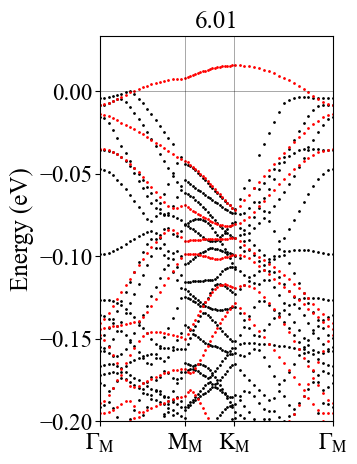

In [27]:
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
plot_band(ax,kx61,band+.00,offset=0,num=np.shape(band)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,eigenvalues-0.3,offset=600,num=200,lw=1.,linestyle='-',label="dft",smooth=False,c='red',sca=True)
ymin = -.2
ymax = - ymin / 6
title = rf'{angle}'
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

[0.00000000 0.12500000 0.19700000 0.34100000]
['${\\Gamma}_{\\mathrm{M}}$', '${\\mathrm{M}}_{\\mathrm{M}}$', '${\\mathrm{K}}_{\\mathrm{M}}$', '${\\Gamma}_{\\mathrm{M}}$']


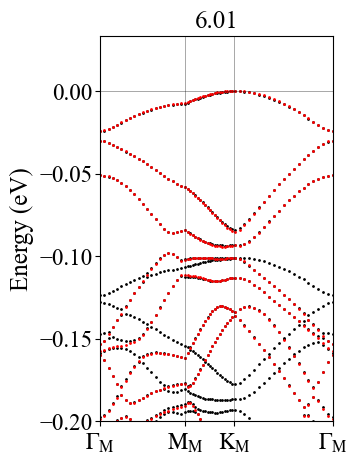

In [445]:
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
plot_band(ax,kx61,band+.00,offset=0,num=np.shape(band)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,eigenvalues+.00,offset=1350,num=50,lw=1.,linestyle='-',label="dft",smooth=False,c='red',sca=True)
ymin = -.2
ymax = - ymin / 6
title = rf'{angle}'
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

In [396]:
dim = np.shape(band_vec)[1]*2
band_idx = -6
k_idx = 40
np.linalg.norm(band_vec[k_idx,:dim//2,band_idx]),np.linalg.norm(band_vec[k_idx,dim//2:,band_idx])

(0.3389736363809127, 0.0)

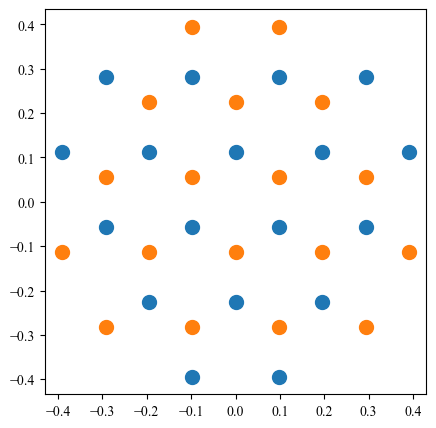

In [42]:
fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.scatter(Q_set1[:,0],Q_set1[:,1],marker='o',s=100)
ax.scatter(Q_set2[:,0],Q_set2[:,1],marker='o',s=100)
ax.set_aspect('equal',adjustable='box')

In [ ]:
19+26*2

71

In [193]:
76*len(Qlayer1),hamk_gamma[0].shape[0],len(Qlayer1),len(Qlayer2)

(1368, 5472, 18, 18)

In [28]:

nlow_state_list = [[22*6+2, 22*6+3, 22*6+4, 22*6+5]]
spin_shift = 71*3
norb_fix_list = [[spin_shift+71*2+35,71*2+35,spin_shift+71*1+35,71*1+35]]
nlow_state_list = [[10,1],[0,1]]
norb_fix_list = [[10,1],[0,1]]
nlow_state_list = [[16,17],[16,17,18]]
norb_fix_list = [[41,5],[5,42,62]]
# norb_fix_list[0] = norb_fix_list[0]
Qlayer_list = [[Q_set1], [Q_set2]]
H_GM_diag_eig, H_GM_diag_eig_vec, H_diag_block, U_new_block = get_H_block(hamk_gamma[0], Qlayer_list, [1, 1], [[76], [76]], nlow_state_list, norb_fix_list, spin='up', mode='K')
U_low_proj, U_high_proj = calculate_energy_lists(H_GM_diag_eig_vec, nlow_state_list, norb_fix_list, Q_set1, Q_set2)

U_low_proj layer 0:   0%|          | 0/2 [00:00<?, ?it/s]

U_low_proj layer 1:   0%|          | 0/3 [00:00<?, ?it/s]

U_high_proj layer 0:   0%|          | 0/18 [00:00<?, ?it/s]

U_high_proj layer 1:   0%|          | 0/18 [00:00<?, ?it/s]

In [43]:
nlow_state_list = [[16,17],[16,17,18]]
norb_fix_list = [[41,5],[5,42,62]]
results = Parallel(n_jobs=61)(delayed(get_h_dft_low)(hamk_gamma[i], nlow_state_list, norb_fix_list, Q_set1, Q_set2) for i in tqdm(range(61)))

# 解包结果到各自列表"
heff_list = [res[0] for res in results]
eig_list  = [res[1] for res in results]
eig_vec_list = [res[2] for res in results]

  0%|          | 0/61 [00:00<?, ?it/s]

In [402]:
nlow_state_list = [[16,17],[16,17]]
norb_fix_list = [[41,5],[5,42]]
nlow_state_list = [[13,14,15,16,17],[14,15,16,17,18]]
norb_fix_list = [[1,2,3,4,5],[1,2,3,4,5]]
nlow_state_list = [[14,15,16,17],[14,15,16,17]]
nlow_state_list = [range(14,22),range(14,22)]
norb_fix_list = nlow_state_list
results = Parallel(n_jobs=4)(delayed(get_h_dft_low)(hamk_gamma[i], nlow_state_list, norb_fix_list, Q_set1, Q_set2) for i in tqdm(range(61)))

# 解包结果到各自列表"
heff_list = [res[0] for res in results]
eig_list  = [res[1] for res in results]
eig_vec_list = [res[2] for res in results]

  0%|          | 0/61 [00:00<?, ?it/s]

In [77]:
nlow_state_list

[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72, 73, 74, 75])]

In [403]:
from joblib import Parallel, delayed
import numpy as np
from tqdm.notebook import tqdm

# 假设 hamk_gamma 是长度为 61 的列表或数组，每个元素都是一个 Hamiltonian 矩阵
dim = hamk_gamma[0].shape[0]

def diag_half(ham):
    """
    对 Hamiltonian 的下半区块（dim//2:, dim//2:）做对称实矩阵对角化，
    返回本征值（已排序）
    """
    # dim = np.shape(ham)[0]
    # ham = ham[dim//2:,dim//2:]
    return np.linalg.eigvalsh(ham)

# 并行计算 61 个 k 点的本征值
eigenvalues_list = Parallel(n_jobs=20, verbose=5, backend='threading')(
    delayed(diag_half)(ham) for ham in tqdm(heff_list)
)

# 如果需要，转换为 NumPy 数组，形状 (61, dim/2)
eigenvalues = np.array(eigenvalues_list)
# eigenvalues = (eigenvalues - efermi)*hartree
eigenvalues = eigenvalues - efermi*hartree
# 示例：打印第一个 k 点的本征值
# print(eigenvalues[0])


  0%|          | 0/61 [00:00<?, ?it/s]

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  35 out of  61 | elapsed:    0.8s remaining:    0.6s
[Parallel(n_jobs=20)]: Done  48 out of  61 | elapsed:    0.8s remaining:    0.2s
[Parallel(n_jobs=20)]: Done  61 out of  61 | elapsed:    0.8s finished


In [362]:
efermi

-0.1753853567232717

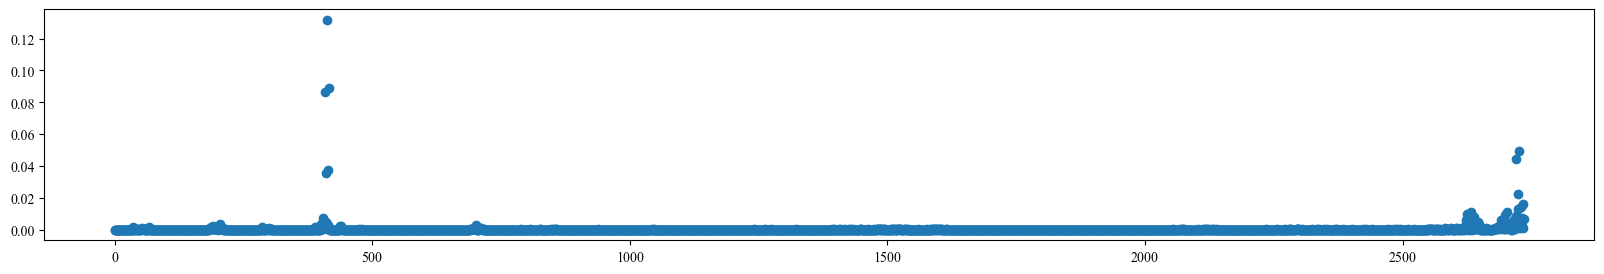

In [193]:
# eig,vec = np.linalg.eigh(heff_list[0])
fig, ax = plt.subplots(figsize=(20*1., 3*1.))
ax.scatter(range(len(vec)),np.abs(vec[684])**2)

[0.00000000 0.12500000 0.19700000 0.34100000]
['${\\Gamma}_{\\mathrm{M}}$', '${\\mathrm{M}}_{\\mathrm{M}}$', '${\\mathrm{K}}_{\\mathrm{M}}$', '${\\Gamma}_{\\mathrm{M}}$']


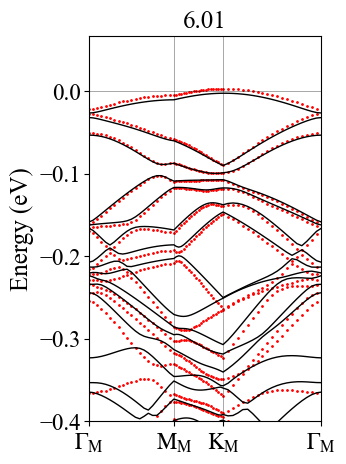

eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy = -4.8724783774666065
eff_energy

In [406]:
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
# plot_band(ax,kx61,eigenvalues_nsoc+.00,offset=0,num=np.shape(eigenvalues_nsoc)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,eigenvalues_nsoc+.00,offset=0,num=720,lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=False)
plot_band(ax,kx61,eigenvalues,offset=0,num=np.shape(eigenvalues)[1],lw=1.,linestyle='-',label="dft",smooth=False,c='red',sca=True)
# plot_band(ax,kx61,eigenvalues/hartree+4.598-0.72,offset=300,num=90,lw=1.,linestyle='-',label="dft",smooth=False,c='red',sca=True)
ymin = - .4
ymax = - ymin / 6
# ymax = 2
# ymin = -200000
# ymax = -130000
title = rf'{angle}'
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

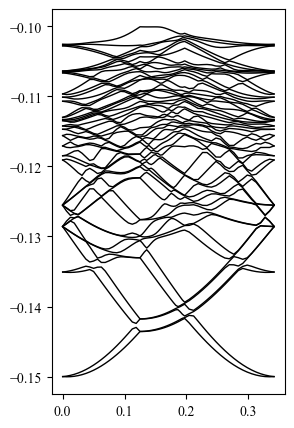

In [415]:
band_cbm_G = np.load("/data/work/zy/software/TAPW_tmdc/tGa2Se2/6.01/2soc/Q_shell_4_cbm/band_Gamma_shell_4_st_nsymm_eigsh_50__cbm.npy")
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
# plot_band(ax,kx61,eigenvalues_nsoc+.00,offset=0,num=np.shape(eigenvalues_nsoc)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,band_cbm_G+.00,offset=0,num=np.shape(band_cbm_G)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=False)

[0.00000000 0.12500000 0.19700000 0.34100000]
['${\\Gamma}_{\\mathrm{M}}$', '${\\mathrm{M}}_{\\mathrm{M}}$', '${\\mathrm{K}}_{\\mathrm{M}}$', '${\\Gamma}_{\\mathrm{M}}$']


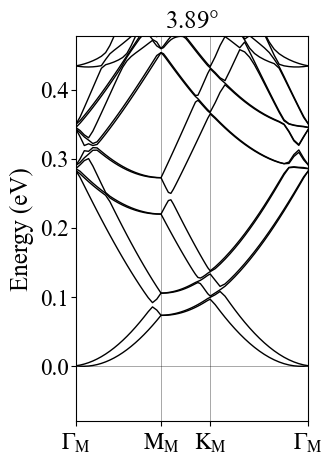

In [453]:
angle = '3.89'
band_cbm_G = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_6_cbm/band_Gamma_shell_6_st_nsymm_eigsh_50__cbm.npy")
band_cbm_G = (band_cbm_G-np.min(band_cbm_G))*hartree
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
# plot_band(ax,kx61,eigenvalues_nsoc+.00,offset=0,num=np.shape(eigenvalues_nsoc)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,band_cbm_G+.00,offset=0,num=np.shape(band_cbm_G)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=False)
ymax = np.max(band_cbm_G[:,10])
ymin = -ymax/6
title = rf'{angle}$\degree$'
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

[0.00000000 0.12500000 0.19700000 0.34100000]
['${\\Gamma}_{\\mathrm{M}}$', '${\\mathrm{M}}_{\\mathrm{M}}$', '${\\mathrm{K}}_{\\mathrm{M}}$', '${\\Gamma}_{\\mathrm{M}}$']


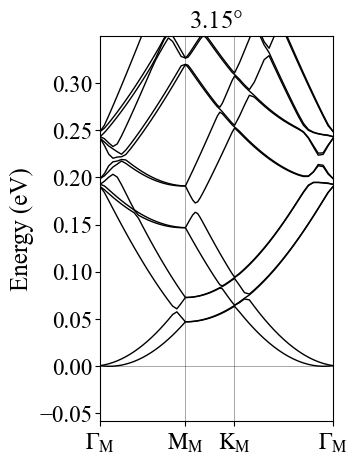

In [459]:
angle = '3.15'
band_cbm_G = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_7_cbm/band_Gamma_shell_7_ge_nsymm_eigsh_50__cbm.npy")
band_cbm_G = (band_cbm_G-np.min(band_cbm_G))*hartree
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
# plot_band(ax,kx61,eigenvalues_nsoc+.00,offset=0,num=np.shape(eigenvalues_nsoc)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,band_cbm_G+.00,offset=0,num=np.shape(band_cbm_G)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=False)
ymax = np.max(band_cbm_G[:,10])
ymin = -ymax/6
title = rf'{angle}$\degree$'
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

[0.00000000 0.12500000 0.19700000 0.34100000]
['${\\Gamma}_{\\mathrm{M}}$', '${\\mathrm{M}}_{\\mathrm{M}}$', '${\\mathrm{K}}_{\\mathrm{M}}$', '${\\Gamma}_{\\mathrm{M}}$']


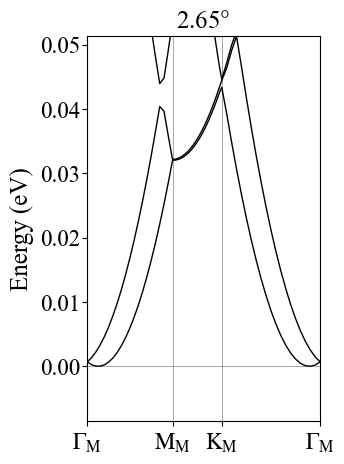

In [480]:
angle = '2.65'
band_cbm_G = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_6_cbm/band_Gamma_shell_6_st_nsymm_eigsh_50__cbm.npy")
band_cbm_G = (band_cbm_G-np.min(band_cbm_G))*hartree
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
# plot_band(ax,kx61,eigenvalues_nsoc+.00,offset=0,num=np.shape(eigenvalues_nsoc)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,band_cbm_G+.00,offset=0,num=np.shape(band_cbm_G)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=False)
ymax = np.max(band_cbm_G[:,1])
ymin = -ymax/6
# ymax = 0.056
# ymin = 0.04
title = rf'{angle}$\degree$'
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

[0.00000000 0.12500000 0.19700000 0.34100000]
['${\\Gamma}_{\\mathrm{M}}$', '${\\mathrm{M}}_{\\mathrm{M}}$', '${\\mathrm{K}}_{\\mathrm{M}}$', '${\\Gamma}_{\\mathrm{M}}$']


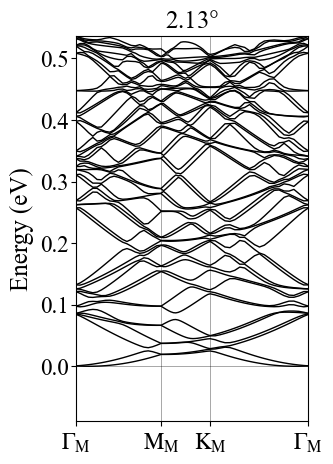

In [27]:
angle = '2.13'
band_cbm_G = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_6_cbm/band_Gamma_shell_6_ge_nsymm_eigsh_50__cbm.npy")
band_cbm_G = (band_cbm_G-np.min(band_cbm_G))*hartree
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
# plot_band(ax,kx61,eigenvalues_nsoc+.00,offset=0,num=np.shape(eigenvalues_nsoc)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,band_cbm_G+.00,offset=0,num=np.shape(band_cbm_G)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=False)
ymax = np.max(band_cbm_G[:,49])
ymin = -ymax/6
title = rf'{angle}$\degree$'
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

In [1]:
import numpy as np

In [2]:
hamk_G_valley = np.load("/data/work/zy/software/TAPW_tmdc/tGa2Se2/2.13/2soc/Q_shell_6_cbm/band_Gamma_shell_6_st_nsymm_eigsh_50__cbm_hamk.npy")

In [2]:
hamk_G_valley = np.load("/data/work/zy/software/1.tapw_code/moirekp/kp/configs/8_3.89/tapw/Q_shell_6/band/hamk_Gamma_valley.npy")

In [5]:
Qlayer1 = np.load("/data/work/zy/software/TAPW_tmdc/tGa2Se2/2.13/2soc/Q_shell_6_cbm/g_vec_list_6_Gamma_1layer.npy")
Qlayer2 = np.load("/data/work/zy/software/TAPW_tmdc/tGa2Se2/2.13/2soc/Q_shell_6_cbm/g_vec_list_6_Gamma_2layer.npy")
Qlayer1 = np.load("/data/work/zy/software/1.tapw_code/moirekp/kp/configs/8_3.89/tapw/Q_shell_6/g_vec_list_6_Gamma_1layer.npy")
Qlayer2 = np.load("/data/work/zy/software/1.tapw_code/moirekp/kp/configs/8_3.89/tapw/Q_shell_6/g_vec_list_6_Gamma_2layer.npy")

Q_set1 = np.array([rot(np.mean(Qlayer1,axis=0) - Qlayer1[i],210) for i in range(len(Qlayer1))])
Q_set2 = np.array([rot(np.mean(Qlayer2,axis=0) - Qlayer2[i],210) for i in range(len(Qlayer2))])
index_1 = np.argsort(np.linalg.norm(Q_set1,axis=1))
index_2 = np.argsort(np.linalg.norm(Q_set2,axis=1))
Qlayer_list = [[Q_set1], [Q_set2]]

In [48]:
def get_H_block(Hamk_list, Qlayer_list, num_layer_list, num_orb_per_layer_list, nlow_state_list, norb_fix_list, spin='up', mode='gamma'):
    """
    Get the Hamiltonian block for the given spin and layer.

    Parameters:
    Hamk_list (list): List of Hamiltonian matrices.
    Qlayer_list (list): List of Q layers. [[Qlayer1], [Qlayer2, Qlayer2]] for A-AB tMote2 and [[Qlayer1], [Qlayer2, Qlayer2, Qlayer2]] for A-ABA tMote2.
    num_layer_list (list): List of number of layers, like [1, 2] for A-AB tMote2 and [1, 3] for A-ABA tMote2.
    num_orb_per_layer_list (list): List of number of orbitals in each layer. like [[71], [71, 71]] for A-AB tMote2 and [[71], [71, 71, 71]] for A-ABA tMote2.
    spin (str): The spin type ('up' or 'down' or 'all').

    Returns:
    numpy.ndarray: The Hamiltonian block for the specified spin and layer.
    """
    # return None, None, None
    num_hamk = 1
    # H_diag_block = [[] for _ in range(num_hamk)]
    # H_GM_diag_eig = [[] for _ in range(num_hamk)]
    # H_GM_diag_eig_vec = [[] for _ in range(num_hamk)]
    H_diag_block = []
    H_GM_diag_eig = []
    H_GM_diag_eig_vec = []
    U_new_block = []
    
    # Qlayer_list = np.array(Qlayer_list)
    num_layer_list = np.array(num_layer_list)
    num_orb_per_layer_list = [np.array(num_orb_per_layer_list[i]) for i in range(len(num_layer_list))]                  
    num_q_list = [np.array([len(gamma_layer) for gamma_layer in qlayer_group]) for qlayer_group in Qlayer_list] # [[21], [21,21]]
    
    flag = False

    hamk = Hamk_list
    ihx=0
    U_big_ix = []
    U_big_iy = []
    U_big_val = []
    if mode == 'gamma':
        for iqx in tqdm(range(num_q_list[0][0]), total=num_q_list[0][0],miniters=1):
            same_q_index = []
            for ilx in range(2):
                for j in range(num_layer_list[ilx]):
            # 生成基础索引，不变的原始索引数组
            # base_same_q_index = np.arange(iqx * num_orb_per_layer_list[0][0],
            #                                 (iqx + 1) * num_orb_per_layer_list[0][0])
            # # 计算每层的平移量
            # shift = num_q_list[0][0] * num_orb_per_layer_list[0][0]
            # # 根据层数（np.sum(num_layer_list)）计算所有层的索引
            # same_q_index = np.concatenate([base_same_q_index + shift * j for j in range(np.sum(num_layer_list))])
                    iqx_ = iqx*num_layer_list[ilx] + j
                    base_same_q_index = np.arange(iqx_ * num_orb_per_layer_list[0][0],
                                                (iqx_ + 1) * num_orb_per_layer_list[0][0])
                    # base_same_q_index *= num_layer_list[ilx]
                    # base_same_q_index += j
                    shift = num_q_list[0][0] * num_orb_per_layer_list[0][0]
                
                    same_q_index.append(  base_same_q_index +  shift*num_layer_list[:ilx].sum())
            same_q_index = np.concatenate(same_q_index)
            if hamk[same_q_index].shape[0] != np.sum(num_layer_list)*num_orb_per_layer_list[0][0]:
                raise ValueError(f"The shape of the Hamk is {hamk[ihx][same_q_index].shape[0]} not equal to the number of bands {np.sum(num_layer_list)}@{num_orb_per_layer_list[0]}={np.sum(num_layer_list)*num_orb_per_layer_list[0][0]} and spin {spin}.")
            if spin == 'all':
                same_q_index = np.concatenate((same_q_index, same_q_index + np.shape(hamk)[1]//2))
            elif spin == 'down' and flag:
                same_q_index = same_q_index + np.shape(hamk)[1]//2
            # print(f"len of same_q_index = {len(same_q_index)}")
            hamk_i = hamk[np.ix_(same_q_index,same_q_index)]
            # print(same_q_index)
            print(hamk_i[10,20])
            
            # print("shape of hamk i = ",np.shape(hamk_i))
            # H_diag_block[ihx].append(temp)
            
            # print(f"ihx = {ihx} iqx = {iqx} shape of hamk = {hamk[np.ix_(same_q_index,same_q_index)].shape}")
            eig,vec = np.linalg.eigh(hamk_i)
            bands = np.array(nlow_state_list[0])
            comps = norb_fix_list[0]
            print(np.sort(eig)[:5],np.linalg.norm(hamk_i))
            # eig, vec, U_new = find_unitary_for_multiple_bands(hamk_i, bands, comps)
            Phi_ref = np.zeros_like(vec[:,bands], dtype=complex)
            for i in range(len(nlow_state_list[0])):
                # for j in comps:
                Phi_ref[comps[i], i] = 1
            
            # Phi_ref[248, 0] = 1
            # Phi_ref[35, 1] = 1
            # Phi_ref[319, 2] = np.sqrt(2)/2
            # Phi_ref[390, 2] = 1j*np.sqrt(2)/2
            # Phi_ref[106, 3] = np.sqrt(2)/2
            # Phi_ref[177, 3] = -1j*np.sqrt(2)/2
            U_aligned, V_1 = align_eigenstates(vec[:,bands], Phi_ref)
            vec[:, bands] = U_aligned
            # vec[:, bands] = Phi_ref
            V_0 = np.zeros((len(bands), len(bands)), dtype=complex)
            for i in range(len(bands)):
                phase = np.abs(vec[comps[i], bands[i]]) / vec[comps[i], bands[i]]
                V_0[i, i] = phase
            vec[:, bands] = vec[:, bands] @ V_0
                
            
            row_idx, col_idx = np.meshgrid(same_q_index, same_q_index, indexing='ij')
            rows = row_idx.ravel()       # 长度 k*k
            cols = col_idx.ravel()       # 长度 k*k
            # data = U_new.ravel()         # 长度 k*k
            U_big_ix.append(rows)
            U_big_iy.append(cols)
            # U_big_val.append(data)
            # print(f"shape of U_new = {np.shape(U_new)} len of U_big_ix = {len(U_big_ix)} len of same_q_index = {len(same_q_index)} len of nonzero = {len(U_new[U_new.nonzero()])}")
            # print(f"U_new = {U_new}")
            # vec =  U_new.conj().T@vec @U_new
            # eig,vec = np.linalg.eigh(U_new@hamk_i@U_new.conj().T)
            # eig,vec = _,_
            H_GM_diag_eig.append(eig)
            H_GM_diag_eig_vec.append(vec)
            H_diag_block.append(hamk_i)
            # U_new_block.append(U_new)
        H_GM_diag_eig = np.array(H_GM_diag_eig)
        H_GM_diag_eig_vec = np.array(H_GM_diag_eig_vec)
        H_diag_block = np.array(H_diag_block)
    
    else:
        for ilx in range(2):
            for j in range(num_layer_list[ilx]):
                for iqx in range(num_q_list[ilx][0]):
                    iqx = iqx*num_layer_list[ilx] + j
                    base_same_q_index = np.arange(iqx * num_orb_per_layer_list[0][0],
                                                (iqx + 1) * num_orb_per_layer_list[0][0])
                    # base_same_q_index *= num_layer_list[ilx]
                    # base_same_q_index += j
                    shift = num_q_list[0][0] * num_orb_per_layer_list[0][0]
                
                    same_q_index =  base_same_q_index + shift*j*0 + shift*num_layer_list[:ilx].sum()
                    # print(f"ilx = {ilx} iqx = {iqx} j = {j} same_q_index = {same_q_index[0]} shift = {shift} num_layer_list = {num_layer_list[:ilx].sum()}")
                    if spin == 'all':
                        same_q_index = np.concatenate((same_q_index, same_q_index + np.shape(hamk)[1]//2))
                    elif spin == 'down':# and flag:
                        same_q_index = same_q_index + np.shape(hamk)[1]//2
                    
                    H_diag_block.append(hamk[np.ix_(same_q_index,same_q_index)])
                    eig,vec = np.linalg.eigh(hamk[np.ix_(same_q_index,same_q_index)])
                    
                    
                    bands = np.array(nlow_state_list[ilx])
                    comps = norb_fix_list[ilx]
                    # Phi_ref = np.zeros_like(vec[:,bands], dtype=complex)
                    # for i in range(len(nlow_state_list[ilx])):
                    #     # for j in comps:
                    #     Phi_ref[comps[i], i] = 1
                    # if ilx == 1:
                    #     Phi_ref[5, 0] = 1
                    #     Phi_ref[41, 1] = 1
                    #     Phi_ref[42, 1] = -1j
                        # Phi_ref[57, 2] = 1j
                        # Phi_ref[62, 2] = 1
                    # U_aligned, V_1 = align_eigenstates(vec[:,bands], Phi_ref)
                    # vec[:, bands] = U_aligned

                    
                    
                    H_GM_diag_eig.append(eig)
                    H_GM_diag_eig_vec.append(vec)
                    # print(f"ilx = {ilx} iqx = {iqx} j = {j} shape of hamk = {hamk[np.ix_(same_q_index,same_q_index)].shape}")
        H_GM_diag_eig = np.array(H_GM_diag_eig)
        H_GM_diag_eig_vec = np.array(H_GM_diag_eig_vec)
    # U_big = scipy.sparse.csr_matrix((np.concatenate(U_big_val), (np.concatenate(U_big_ix), np.concatenate(U_big_iy))), shape=np.shape(Hamk_list))
    # return H_GM_diag_eig, H_GM_diag_eig_vec,H_diag_block, U_big
    return H_GM_diag_eig, H_GM_diag_eig_vec, H_diag_block, U_new_block


In [49]:
from tqdm_joblib import tqdm
nlow_state_list = [[14,15,16,17],[14,15,16,17]]
nlow_state_list = [range(14,22),range(14,22)]
norb_fix_list = nlow_state_list
H_GM_diag_eig, H_GM_diag_eig_vec, H_diag_block, U_new_block = get_H_block(hamk_G_valley[0], Qlayer_list, [1, 1], [[46], [46]], nlow_state_list, norb_fix_list, spin='all', mode='gamma')

  0%|          | 0/31 [00:00<?, ?it/s]

(-0.00018427993559028277-2.984718238530826e-08j)
[-48.49531977 -48.49531977 -48.49450347 -48.49450347 -48.21242782] 320.2844533096926
(-0.04505087279578109-0.08250103439148802j)
[-48.49535384 -48.49529648 -48.49473079 -48.49444008 -48.21243213] 314.9051579295439
(-0.14162219194725822-0.15578730405962052j)
[-48.49594253 -48.49572221 -48.49537974 -48.49509968 -48.21281645] 303.5662910075624
(0.021556862034991985-0.6589930803985902j)
[-48.49535432 -48.49529504 -48.49473095 -48.4944391  -48.21245005] 314.9050979423066
(0.022180658190175062-0.7415377429346058j)
[-48.4953545  -48.49529208 -48.49472997 -48.4944383  -48.21242546] 314.91229344057183
(-0.0632434404327456-0.7987273282440867j)
[-48.49544946 -48.49532959 -48.49493999 -48.4944569  -48.21245707] 307.8358920890482
(-0.17751178621311967-0.8235684758746135j)
[-48.49672536 -48.49653182 -48.49622335 -48.49590435 -48.21341448] 294.603851818832
(0.06669596848177177-1.2502356975603708j)
[-48.49594317 -48.49572105 -48.49538047 -48.49509597 -4

In [20]:
efermi = np.min(np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_6_cbm/band_Gamma_shell_6_ge_nsymm_eigsh_50__cbm.npy"))

In [12]:
efermi = -4.168612

In [51]:
np.save("/data/work/zy/software/1.tapw_code/moirekp/kp/block.npy",H_diag_block[0])

Text(0, 0.5, 'Energy (eV)')

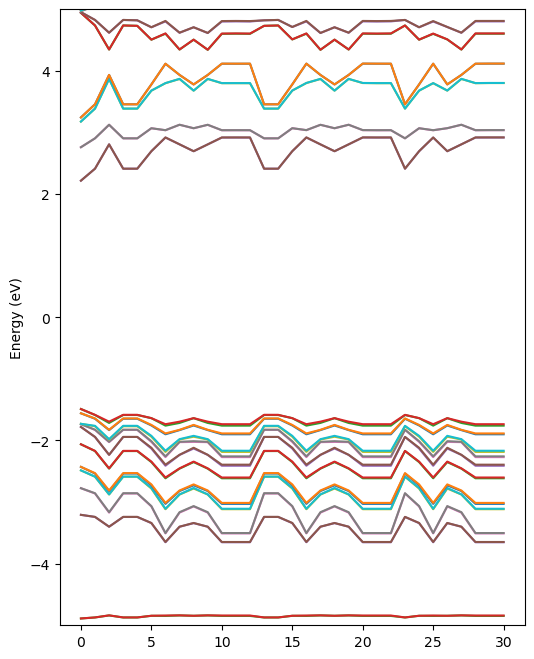

In [33]:
fig,ax = plt.subplots(figsize=(6,8))
for i in range(np.shape(H_GM_diag_eig)[1]):
    # ax.scatter(np.arange(len(Q_set1)),H_GM_diag_eig[index_1,i]*hartree,s=10)
    ax.plot(np.arange(len(Q_set1)),(H_GM_diag_eig[:,i]-efermi))
    # ax.plot(np.arange(19),H_GM_diag_eig[0][index_1,i]*hartree)
    # ax.scatter(np.arange(19*3),H_GM_diag_eig[0][:,i]*hartree)
ax.set_ylim(-3,-1.4)
# ax.set_ylim(2,4)
ax.set_ylim(-5,5)
ax.set_ylabel(r'Energy (eV)')
# plt.savefig('/data/work/zy/software/TAPW_tmdc/tGa2Se2/model.png',dpi=300)

In [39]:
H_GM_diag_eig[:,0]

array([-48.49531977, -48.49535384, -48.49594253, -48.49535432,
       -48.4953545 , -48.49544946, -48.49672536, -48.49594317,
       -48.49544955, -48.49594133, -48.49675365, -48.49675498,
       -48.49672742, -48.4953545 , -48.49535384, -48.495448  ,
       -48.49671921, -48.49594133, -48.49544946, -48.49594253,
       -48.49674494, -48.49675365, -48.49672536, -48.49535432,
       -48.49544955, -48.49672742, -48.495448  , -48.49594317,
       -48.49675498, -48.49674494, -48.49671921])

In [ ]:
band_eff = np.loadtxt("/data/work/zy/software/1.tapw_code/moirekp/kp/configs/plots_mgi2/heff_spectrum_4.txt")
band = np.loadtxt("/data/work/zy/software/1.tapw_code/moirekp/kp/configs/8_3.89/tapw/Q_shell_6/band/band_VBM_Gamma_valley.txt")
print(np.max(band_eff))
band_eff = band_eff - np.max(band_eff)
band = band - np.max(band)

-5.6479644743


(-0.1, 0.02)

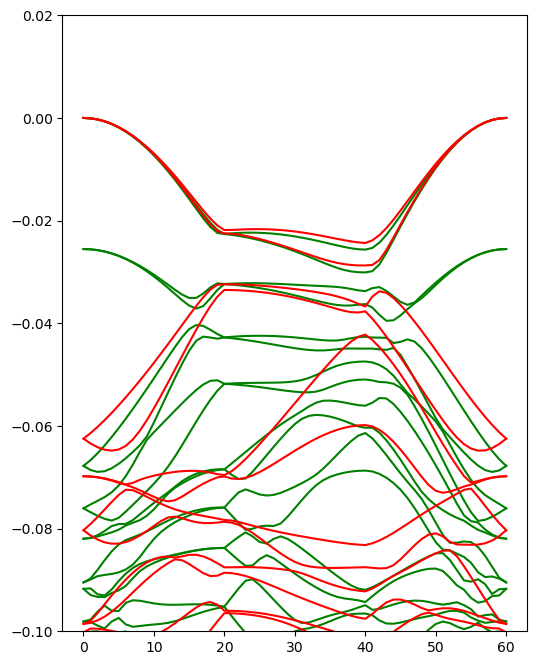

In [3]:
fig,ax = plt.subplots(figsize=(6,8))
for i in range(np.shape(band)[1]):
    ax.plot(range(61),band[:,i],c='g')
for i in range(np.shape(band_eff)[1]):
    ax.plot(range(61),band_eff[:,i],c='r')
ax.set_ylim(-0.1,0.02)


In [41]:
band_eff = np.loadtxt("/data/work/zy/software/1.tapw_code/moirekp/kp/configs/plots/heff_spectrum.txt")
band = np.loadtxt("/data/work/zy/software/1.tapw_code/tapw/examples/tGa2Se2/2.13/2soc/Q_shell_6_cbm/band_data/band_data_Gamma_valley.txt")
band_eff = band_eff - np.min(band_eff)
band = band - np.min(band)

(-0.1, 0.2)

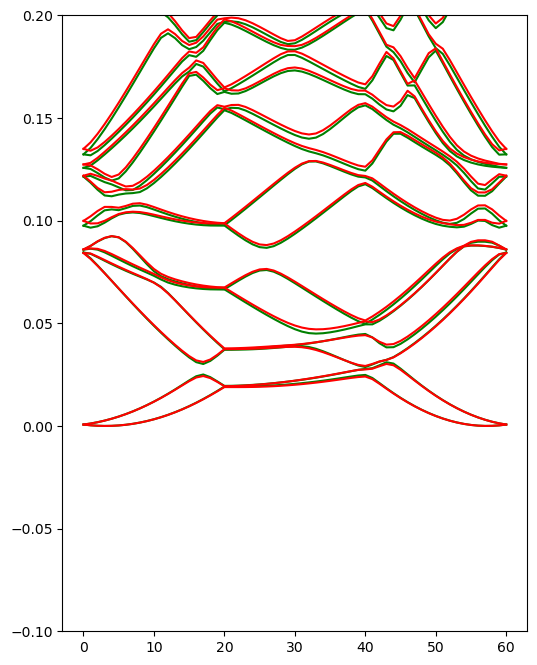

In [42]:
fig,ax = plt.subplots(figsize=(6,8))
for i in range(np.shape(band)[1]):
    ax.plot(range(61),band[:,i],c='g')
for i in range(np.shape(band_eff)[1]):
    ax.plot(range(61),band_eff[:,i],c='r')
ax.set_ylim(-0.1,0.2)


Text(0, 0.5, 'Energy (eV)')

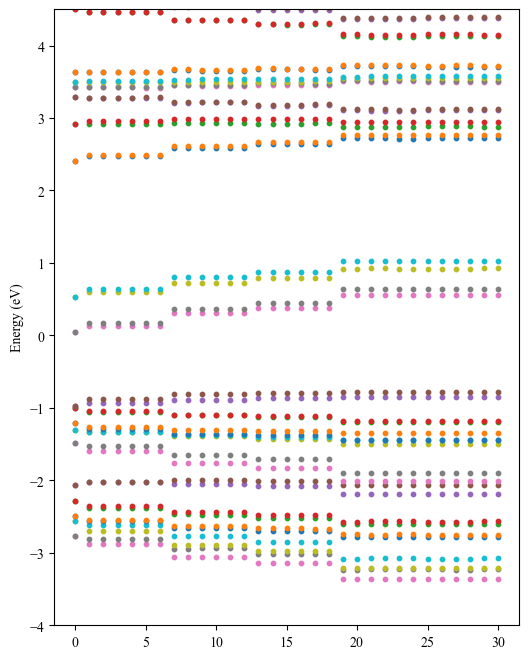

In [22]:
fig,ax = plt.subplots(figsize=(6,8))
for i in range(np.shape(H_GM_diag_eig)[1]):
    # ax.scatter(np.arange(len(Q_set1)),H_GM_diag_eig[index_1,i]*hartree,s=10)
    ax.scatter(np.arange(len(Q_set1)),(H_GM_diag_eig[index_1,i]-efermi)*hartree,s=10)
    # ax.plot(np.arange(19),H_GM_diag_eig[0][index_1,i]*hartree)
    # ax.scatter(np.arange(19*3),H_GM_diag_eig[0][:,i]*hartree)
ax.set_ylim(-4,4.5)
# ax.set_ylim(-8,10)
# ax.set_xlim(-1,20)
ax.set_ylabel(r'Energy (eV)')
# plt.savefig('/data/work/zy/software/TAPW_tmdc/tGa2Se2/model.png',dpi=300)

In [68]:
(H_GM_diag_eig[0,76:80])*hartree,H_GM_diag_eig.shape

(array([-4.0715, -4.0715, -3.5829, -3.5829]), (31, 304))

In [117]:

def calculate_energy_lists(H_GM_diag_eig_vec,nlow_state_list,norb_fix_list, Qlayer1,Qlayer2):
    """
    Calculate low energy and high energy lists from the given eigenvector matrix.

    Parameters:
    H_GM_diag_eig_vec (numpy.ndarray): Eigenvector matrix.
    norb_fix (int): Index of the fixed orbital.
    nlow_state (int): Index of the low energy state.
    theta_rot (float): Rotation angle in degrees.
    orb_num (int): Number of orbitals.

    Returns:
    tuple: Low energy list (numpy.ndarray), High energy list (numpy.ndarray).
    """
    # nlow_state_list = self.nlow_state
    # norb_fix_list = self.norb_fix
    theta_rot = 0
    #============================================20241104============================================
    # orb_num = self.temp_num_orbs_per_unit_cell
    # ULowEnergyList = []
    U_low_proj = None
    U_low_proj_list = []
    phase = 1
    for ilayer in range(len(nlow_state_list)):
        nlow_state = nlow_state_list[ilayer]
        if nlow_state == []:
            continue
        norb_fix = norb_fix_list[ilayer]
        Qlayer = Qlayer1 if ilayer == 0 else Qlayer2
        ULowEnergyList = [[] for _ in range(len(nlow_state))]
        Phi_ref = np.zeros_like(H_GM_diag_eig_vec[0][:, nlow_state], dtype=complex)
        for i in range(len(nlow_state)):
            # for j in norb_fix:
                # Phi_ref[j,i] = 1
            Phi_ref[norb_fix[i], i] = 1
        
        for i in range(len(Qlayer)):
            V_0 = np.zeros((len(nlow_state), len(nlow_state)), dtype=complex)
            U_aligned, V_1 = align_eigenstates(H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state], Phi_ref)
            for j in range(len(nlow_state)):
                # vecpart = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]]
                vecpart = U_aligned[:, j]
                # print(f"Q_{i} {j} vecpart[norb_fix[j]] = {vecpart[norb_fix[j]]} phi_ref[end=j] = {Phi_ref[norb_fix[j],j]} original = {H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]][norb_fix[j]]}")
                # print(f"Q_{i} {j} vecpart[norb_fix[j]] = {abs(vecpart[norb_fix[j]])} phi_ref[end=j] = {Phi_ref[norb_fix[j],j]} original = {abs(H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]][norb_fix[j]])} diff = {abs(vecpart[norb_fix[j]]) - abs(H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]][norb_fix[j]])}")
                # phase =  ((vecpart[norb_fix[j]] / np.abs(vecpart[norb_fix[j]])) ** (-1)) * np.exp(-1j * 2 * theta_rot * np.pi / 180)
                phase =  np.exp(-1j * 2 * theta_rot * np.pi / 180)
                V_0[j,j] = phase
            # print(f" {np.sum(abs(vecpart[norb_fix])**2)}, { np.sum(np.abs(H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]][norb_fix])**2)}")
            # H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state] = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state] @ V
            H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state] = U_aligned@V_0
            
        for j in range(len(nlow_state)):
            # if j == 0 and ilayer == 1:
            #     phase = -1
            for i in range(len(Qlayer)):
                vecpart = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, nlow_state[j]]
                # vecpart = vecpart * ((vecpart[norb_fix[j]] / np.abs(vecpart[norb_fix[j]])) ** (-1)) * np.exp(-1j * 2 * theta_rot * np.pi / 180)

                ULowEnergyList[j].append(vecpart)
            ULowEnergyList[j] = scipy.linalg.block_diag(*ULowEnergyList[j])
        U_low_proj_list.append(np.concatenate(ULowEnergyList,axis=0))
    U_low_proj = scipy.linalg.block_diag(*U_low_proj_list).T
    # spin_up = np.array([j for i in range(57) for j in range(i * 142, i * 142 + 71)])
    # spin_down = np.array([j for i in range(57) for j in range(i * 142 + 71, i * 142 + 142)])
    n_g = len(Qlayer1)
    nlayers = 2
    spin_up = np.array([j for i in range(n_g) for j in range(i * 152*nlayers, i * 152*nlayers + 76*nlayers)])
    spin_down = np.array([j for i in range(n_g) for j in range(i * 152*nlayers + 76*nlayers, i * 152*nlayers + 152*nlayers)])
    # print("max of spin_up = ",np.max(spin_up))
    # print("max of spin_down = ",np.max(spin_down))
    orb_layer1_up = np.array([j for i in range(n_g) for j in range(i * 76*nlayers, i * 76*nlayers + 76)])
    orb_layer1_down = orb_layer1_up+np.shape(U_low_proj)[0]//2
    orb_layer2_up = np.array([j for i in range(n_g) for j in range(i * 76*nlayers + 76, i * 76*nlayers + 76*nlayers)])
    orb_layer2_down = orb_layer2_up+np.shape(U_low_proj)[0]//2
    # print(len(spin_up),len(spin_down),len(orb_layer1_up),len(orb_layer1_down),len(orb_layer2_up),len(orb_layer2_down))
    
    # U_low_proj = np.concatenate((U_low_proj[orb_layer1_up], U_low_proj[orb_layer2_up], U_low_proj[orb_layer1_down], U_low_proj[orb_layer2_down]), axis=0)
    
    # U_low_proj = np.concatenate((U_low_proj[spin_up], U_low_proj[spin_down]), axis=0)
    # U_low_proj = np.concatenate((U_low_proj[orb_layer1_up], U_low_proj[orb_layer2_up]), axis=0)
    
    
    
    U_low_proj = np.concatenate((U_low_proj[spin_up], U_low_proj[spin_down]), axis=0)
    U_low_proj = np.concatenate((U_low_proj[orb_layer1_up], U_low_proj[orb_layer2_up], U_low_proj[orb_layer1_down], U_low_proj[orb_layer2_down]), axis=0)
    
    if len(nlow_state_list) == 2:
        if nlow_state_list[0] == []:
            U_low_proj = np.concatenate((np.zeros((len(H_GM_diag_eig_vec[0])*len(Qlayer1),np.shape(U_low_proj)[1])),U_low_proj),axis=0)
        if nlow_state_list[1] == []:
            U_low_proj = np.concatenate((U_low_proj,np.zeros((len(H_GM_diag_eig_vec[-1])*len(Qlayer2),np.shape(U_low_proj)[1]))),axis=0)
    
    # print("shape of Uproj = ",np.shape(U_low_proj))
    U_high_proj = None
    UHighEnergyList = []
    for ilayer in range(len(nlow_state_list)):
        nlow_state = nlow_state_list[ilayer]
        if nlow_state == []:
            continue
        Qlayer = Qlayer1 if ilayer == 0 else Qlayer2
        for i in range(len(Qlayer)):
            orb_num = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)].shape[1]
            vecpart = H_GM_diag_eig_vec[i+ilayer*len(Qlayer)][:, np.delete(np.arange(orb_num), nlow_state)]
            # for j in range(vecpart.shape[1]):
            #     vecpart[:,j] = vecpart[:,j] * ((vecpart[norb_fix,j] / np.abs(vecpart[norb_fix,j])) ** (-1)) * np.exp(-1j * 2 * theta_rot * np.pi / 180)
            vecpart_transposed = vecpart
            UHighEnergyList.append(vecpart_transposed)
    U_high_proj = scipy.linalg.block_diag(*UHighEnergyList)
    
    # U_high_proj = np.concatenate((U_high_proj[orb_layer1], U_high_proj[orb_layer2]), axis=0)
    # U_high_proj = np.concatenate((U_high_proj[orb_layer1_up], U_high_proj[orb_layer2_up], U_high_proj[orb_layer1_down], U_high_proj[orb_layer2_down]), axis=0)
    
    # U_high_proj = np.concatenate((U_high_proj[spin_up], U_high_proj[spin_down]), axis=0)
    # U_high_proj = np.concatenate((U_high_proj[orb_layer1_up], U_high_proj[orb_layer2_up]), axis=0)
    
    
    U_high_proj = np.concatenate((U_high_proj[spin_up], U_high_proj[spin_down]), axis=0)
    U_high_proj = np.concatenate((U_high_proj[orb_layer1_up], U_high_proj[orb_layer2_up], U_high_proj[orb_layer1_down], U_high_proj[orb_layer2_down]), axis=0)
    
    if len(nlow_state_list) == 2:
        if nlow_state_list[0] == []:
            U_high_proj = np.concatenate((np.zeros((len(H_GM_diag_eig_vec[0])*len(Qlayer1),np.shape(U_high_proj)[1])),U_high_proj),axis=0)
        if nlow_state_list[1] == []:
            U_high_proj = np.concatenate((U_high_proj,np.zeros((len(H_GM_diag_eig_vec[-1])*len(Qlayer2),np.shape(U_high_proj)[1]))),axis=0)
    # print("shape of U_high_proj = ",np.shape(U_high_proj))
    # ULowEnergyList = np.array(ULowEnergyList)
    # UHighEnergyList = np.array(UHighEnergyList)

    # return ULowEnergyList, UHighEnergyList
    return U_low_proj, U_high_proj


def get_h_dft_low(hamk, nlow_state_list, norb_fix_list, Qlayer1, Qlayer2):
    Qlayer_list = [[Qlayer1], [Qlayer2]]
    h_dft = hamk* hartree #* 1000
    H_GM_diag_eig, H_GM_diag_eig_vec, H_diag_block, U_new_block  = get_H_block(h_dft, Qlayer_list, [1, 1], [[76], [76]],nlow_state_list, norb_fix_list, spin='all', mode='gamma')
    Uproj, UHighEnergy = calculate_energy_lists(H_GM_diag_eig_vec, nlow_state_list, norb_fix_list, Qlayer1, Qlayer2)
    print("shape of Uproj = ",Uproj.shape,UHighEnergy.shape,h_dft.shape)
    # Uproj = U_big.conj().T @ Uproj
    # UHighEnergy = U_big.conj().T @ UHighEnergy
    dim = h_dft.shape[0]
    # h_dft = h_dft[:dim//2,:dim//2]
    h00 = np.dot(Uproj.T.conj(), np.dot(h_dft, Uproj))
    # print(f"end h00 time = {time.strftime('%Y-%m-%d %H:%M:%S',time.localtime())}")
    X = np.dot(h_dft, UHighEnergy)
    h11 = np.dot(UHighEnergy.T.conj(), X)
    h01 = np.dot(Uproj.T.conj(), X)
    h10 = h01.T.conj()
    # eff_energy = np.mean(np.linalg.eigvalsh(h00))+00
    
    eff_energy = np.mean(np.linalg.eigvalsh(h00))
    eff_energy = eff_energy#*hartree
    # eff_energy = efermi*hartree-0.1
    print(f"eff_energy = {eff_energy}")
    # heff = h00 + h01 @ np.linalg.inv(eff_energy * np.identity(h11.shape[0]) - h11) @ h10
    temp = np.linalg.solve(eff_energy * np.identity(h11.shape[0]) - h11, h10)
    heff = h00 + h01 @ temp
    heff = (heff+heff.T.conj())/2
    eig,eig_vec = np.linalg.eigh(heff)
    sort_index = np.argsort(eig)
    eig = eig[sort_index]
    eig_vec = eig_vec[:,sort_index]
    
    return heff, eig, eig_vec



In [129]:
nlow_state_list = [[16,17],[16,17]]
norb_fix_list = [[41,5],[5,42]]
nlow_state_list = [[13,14,15,16,17],[14,15,16,17,18]]
norb_fix_list = [[1,2,3,4,5],[1,2,3,4,5]]
nlow_state_list = [[14,15,16,17],[14,15,16,17]]
nlow_state_list = [[76,77,78,79]]
norb_fix_list = [[1,153,77,229]]
results = Parallel(n_jobs=8)(delayed(get_h_dft_low)(hamk_G_valley[i], nlow_state_list, norb_fix_list, Q_set1, Q_set2) for i in tqdm(range(61)))

# 解包结果到各自列表"
heff_list = [res[0] for res in results]
eig_list  = [res[1] for res in results]
eig_vec_list = [res[2] for res in results]

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]
shape of Uproj =  (9424, 124) (9424, 9300) (9424, 9424)
eff_energy = -3.502324663956766
  0%|          | 0/31 [00:00<?, ?it/s]
shape of Uproj =  (9424, 124) (9424, 9300) (9424, 9424)
eff_energy = -3.5011593139651325
  0%|          | 0/31 [00:00<?, ?it/s]
shape of Uproj =  (9424, 124) (9424, 9300) (9424, 9424)
eff_energy = -3.4954438641745837
  0%|          | 0/31 [00:00<?, ?it/s]
shape of Uproj =  (9424, 124) (9424, 9300) (9424, 9424)
eff_energy = -3.4910264267996816
  0%|          | 0/31 [00:00<?, ?it/s]
shape of Uproj =  (9424, 124) (9424, 9300) (9424, 9424)
eff_energy = -3.489527149444085
  0%|          | 0/31 [00:00<?, ?it/s]
shape of Uproj =  (9424, 124) (9424, 9300) (9424, 9424)
eff_energy = -3.488792016120442
  0%|          | 0/31 [00:00<?, ?it/s]
shape of Uproj =  (9424, 124) (9424, 9300) (9424, 9424)
eff_energy = -3.497348942906995
  0%|          | 0/31 [00:00<?, ?it/s]
shape of Uproj =  (9424, 124) (9424, 9300) (9424, 9424)
eff_energy = 

In [130]:
np.save("/data/work/zy/software/TAPW_tmdc/tGa2Se2/2.13/2soc/Q_shell_6_cbm/heff_list.npy",np.array(heff_list))

In [127]:
nlow_state_list = [[76,77,78,79]]
norb_fix_list = [[1,153,77,229]]
H_GM_diag_eig, H_GM_diag_eig_vec, H_diag_block, U_new_block = get_H_block(hamk_G_valley[0], Qlayer_list, [1, 1], [[76], [76]], nlow_state_list, norb_fix_list, spin='all', mode='gamma')

  0%|          | 0/31 [00:00<?, ?it/s]

In [131]:
from joblib import Parallel, delayed
import numpy as np
from tqdm.notebook import tqdm

# 假设 hamk_gamma 是长度为 61 的列表或数组，每个元素都是一个 Hamiltonian 矩阵

def diag_half(ham):
    """
    对 Hamiltonian 的下半区块（dim//2:, dim//2:）做对称实矩阵对角化，
    返回本征值（已排序）
    """
    # dim = np.shape(ham)[0]
    # ham = ham[dim//2:,dim//2:]
    return np.linalg.eigvalsh(ham)

# 并行计算 61 个 k 点的本征值
eigenvalues_list = Parallel(n_jobs=20, verbose=5, backend='threading')(
    delayed(diag_half)(ham) for ham in tqdm(heff_list)
)

# 如果需要，转换为 NumPy 数组，形状 (61, dim/2)
eigenvalues = np.array(eigenvalues_list)
# eigenvalues = (eigenvalues - efermi)*hartree
eigenvalues = eigenvalues - efermi*hartree
# 示例：打印第一个 k 点的本征值
# print(eigenvalues[0])


  0%|          | 0/61 [00:00<?, ?it/s]

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  35 out of  61 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=20)]: Done  48 out of  61 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  61 out of  61 | elapsed:    0.2s finished


In [ ]:
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
plot_band(ax,kx61,band+.00,offset=0,num=np.shape(band)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,eigenvalues+.00,offset=1350,num=50,lw=1.,linestyle='-',label="dft",smooth=False,c='red',sca=True)
ymin = -.2
ymax = - ymin / 6
title = rf'{angle}'
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

[0.0000 0.1250 0.1970 0.3410]
['${\\Gamma}_{\\mathrm{M}}$', '${\\mathrm{M}}_{\\mathrm{M}}$', '${\\mathrm{K}}_{\\mathrm{M}}$', '${\\Gamma}_{\\mathrm{M}}$']


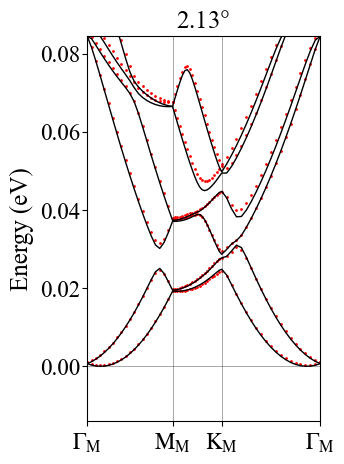

In [132]:
angle = '2.13'
band_cbm_G = np.load(f"/data/work/zy/software/TAPW_tmdc/tGa2Se2/{angle}/2soc/Q_shell_6_cbm/band_Gamma_shell_6_ge_nsymm_eigsh_50__cbm.npy")
band_cbm_G = (band_cbm_G-np.min(band_cbm_G))*hartree
fig, ax = plt.subplots(figsize=(3*1., 5*1.))
# plot_band(ax,kx61,eigenvalues_nsoc+.00,offset=0,num=np.shape(eigenvalues_nsoc)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=True)
plot_band(ax,kx61,band_cbm_G+.00,offset=0,num=np.shape(band_cbm_G)[1],lw=1.,linestyle='-',label="model",smooth=False,c='black',sca=False)
plot_band(ax,kx61,eigenvalues+.005,offset=0,num=50,lw=1.,linestyle='-',label="dft",smooth=False,c='red',sca=True)
ymax = np.max(band_cbm_G[:,2])
ymin = -ymax/6
title = rf'{angle}$\degree$'
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
set_pic(ax,ymin,ymax,ylim=True,meV=False,legend_show=False,title=title,save=False,transparent_flag=True,savepath='/',legend_fontsize=6)

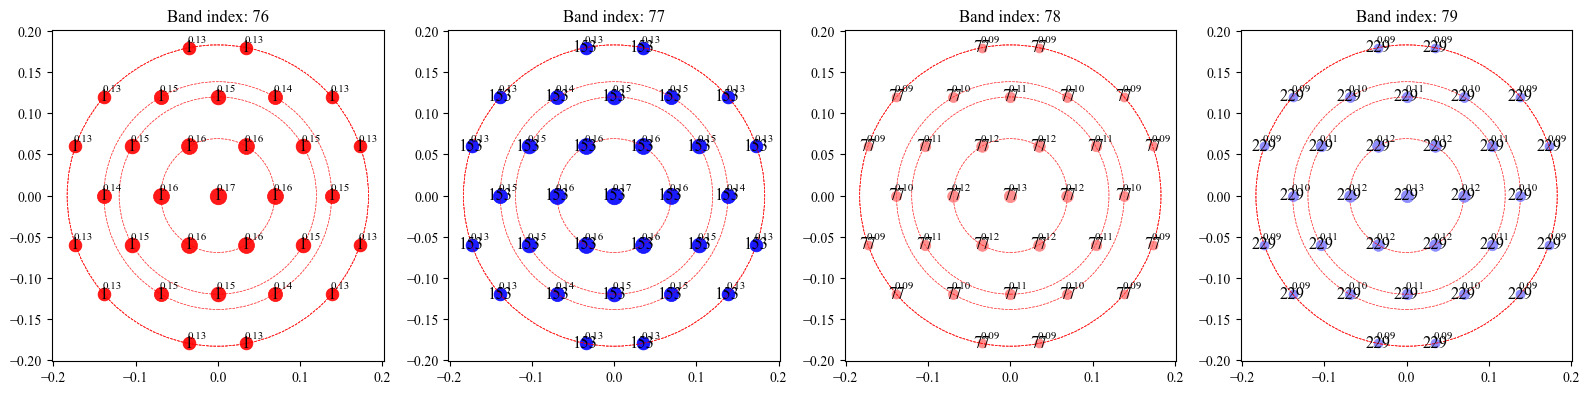

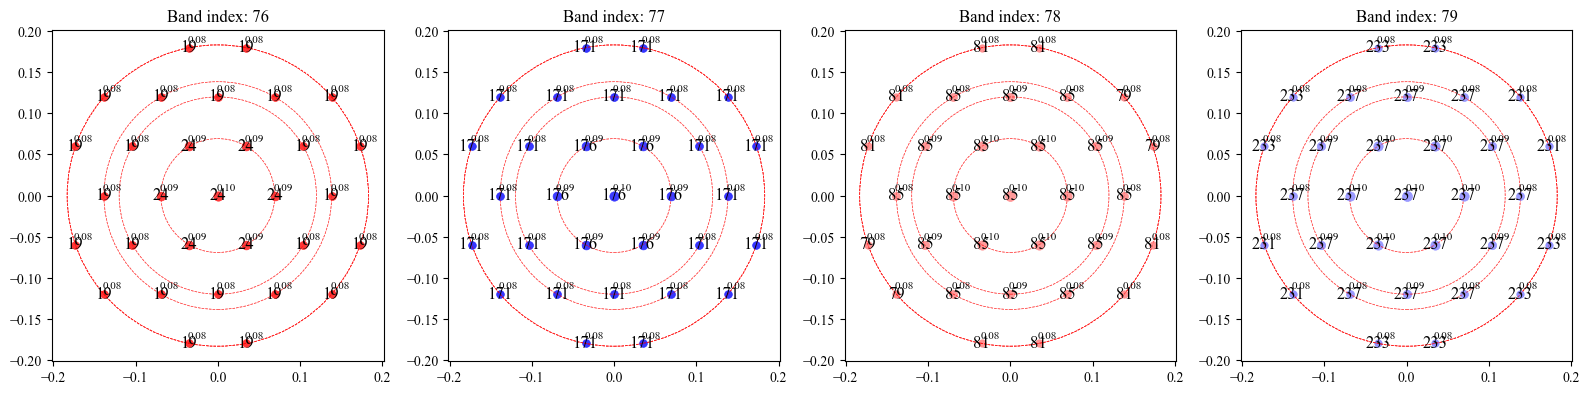

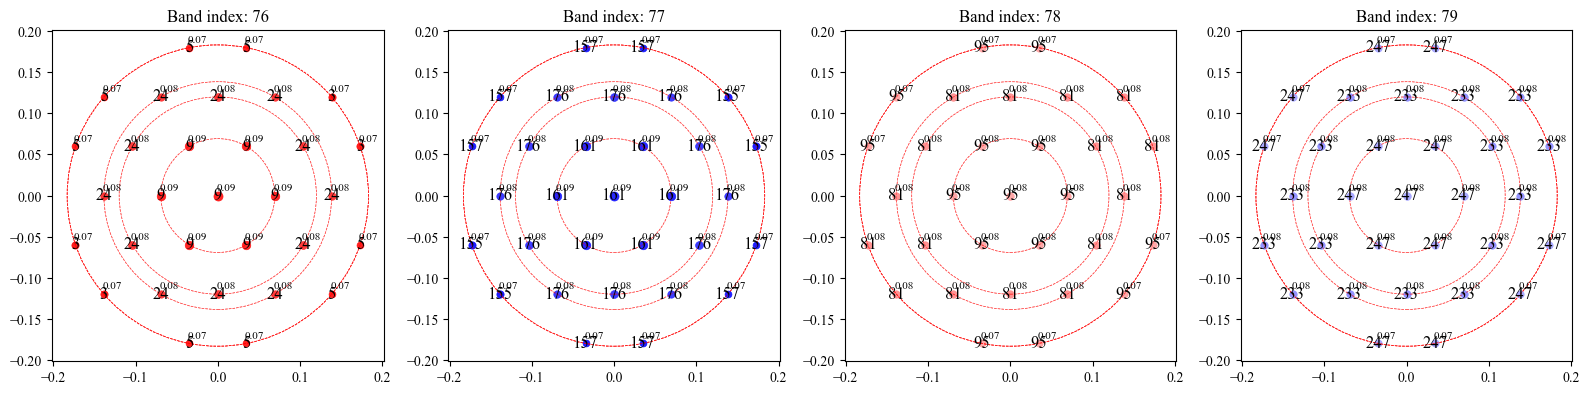

In [128]:
band_indices = [32,33, 34, 35]
band_indices = [76,77,78,79]
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, ga2se2_orb, index_1, max_id = -1, cmap_name='bwr_r')
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, ga2se2_orb, index_1, max_id = -2, cmap_name='bwr_r')
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, ga2se2_orb, index_1, max_id = -3, cmap_name='bwr_r')

In [400]:
nlow_state_list = [[16,17],[16,17]]
norb_fix_list = [[41,5],[5,42]]
nlow_state_list = [[13,14,15,16,17],[14,15,16,17,18]]
norb_fix_list = [[1,2,3,4,5],[1,2,3,4,5]]
nlow_state_list = [[14,15,16,17],[14,15,16,17]]
nlow_state_list = [range(14,22),range(14,22)]
norb_fix_list = nlow_state_list
results = Parallel(n_jobs=4)(delayed(get_h_dft_low)(hamk_gamma[i], nlow_state_list, norb_fix_list, Q_set1, Q_set2) for i in tqdm(range(61)))

# 解包结果到各自列表"
heff_list = [res[0] for res in results]
eig_list  = [res[1] for res in results]
eig_vec_list = [res[2] for res in results]

array([-0.76323973, -0.76300545, -0.76292661, ...,  3.91477142,
        3.95221728,  3.96719327])

Text(0, 0.5, 'Energy (eV)')

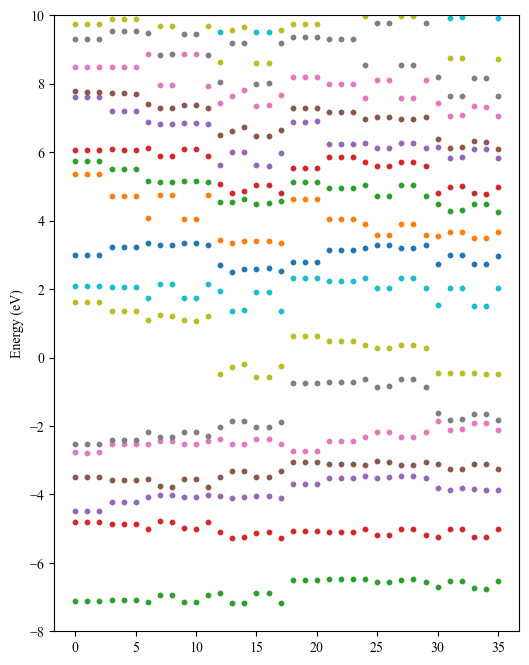

In [412]:
fig,ax = plt.subplots(figsize=(6,8))
for i in range(np.shape(H_GM_diag_eig)[1]):
    # ax.scatter(np.arange(len(Q_set1)),H_GM_diag_eig[index_1,i]*hartree,s=10)
    ax.scatter(np.arange(len(Q_set1)+len(Q_set2)),(H_GM_diag_eig[np.concatenate([index_1,index_2+len(Q_set1)]),i]-efermi)*hartree,s=10)
    # ax.plot(np.arange(19),H_GM_diag_eig[0][index_1,i]*hartree)
    # ax.scatter(np.arange(19*3),H_GM_diag_eig[0][:,i]*hartree)
ax.set_ylim(-4.8,-4.5)
ax.set_ylim(-8,10)
# ax.set_xlim(-1,20)
ax.set_ylabel(r'Energy (eV)')
# plt.savefig('/data/work/zy/software/TAPW_tmdc/tGa2Se2/model.png',dpi=300)

In [221]:
H_GM_diag_eig[np.concatenate([index_1,index_2+len(Q_set1)]),12]*hartree

array([-11.87704541, -11.87459652, -11.87712072, -11.85922576,
       -11.86094576, -11.85596902, -11.92438986, -11.71201124,
       -11.71258086, -11.91963194, -11.92374074, -11.71422114,
       -11.65195644, -11.95539581, -11.95343253, -11.65577614,
       -11.65084907, -11.94974008, -11.26294625, -11.26403889,
       -11.26420587, -11.25600539, -11.25501711, -11.25369044,
       -11.25821703, -11.33665852, -11.33040063, -11.26164079,
       -11.25890003, -11.33433229, -11.48501809, -11.30832853,
       -11.29687737, -11.50517322, -11.52323667, -11.31387854])

In [121]:
ga2se2_orb[41:43],ga2se2_orb[[5,42,57,62]]

(array(['Se$_2$1p$_x$', 'Se$_2$1p$_y$'], dtype='<U20'),
 array(['Se$_1$1p$_z$', 'Se$_2$1p$_y$', 'Ga$_1$1s', 'Ga$_1$1p$_z$'], dtype='<U20'))

In [34]:
H_GM_diag_eig[0,30:40]*hartree
H_GM_diag_eig[0,15:20]*hartree

array([-8.25715479, -7.52909957, -7.29899711, -3.11939058, -2.67607245])

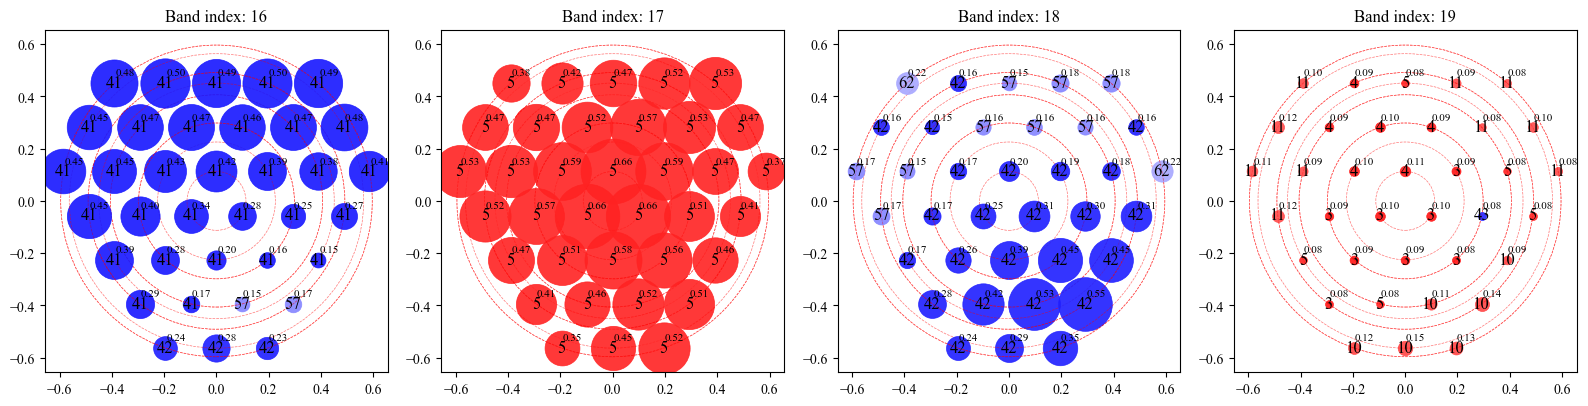

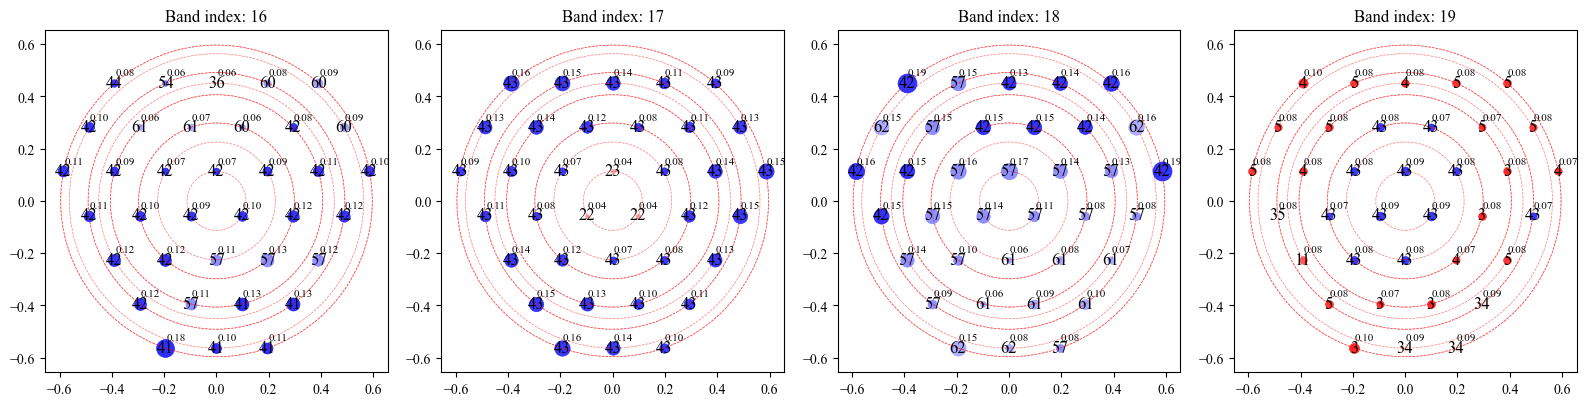

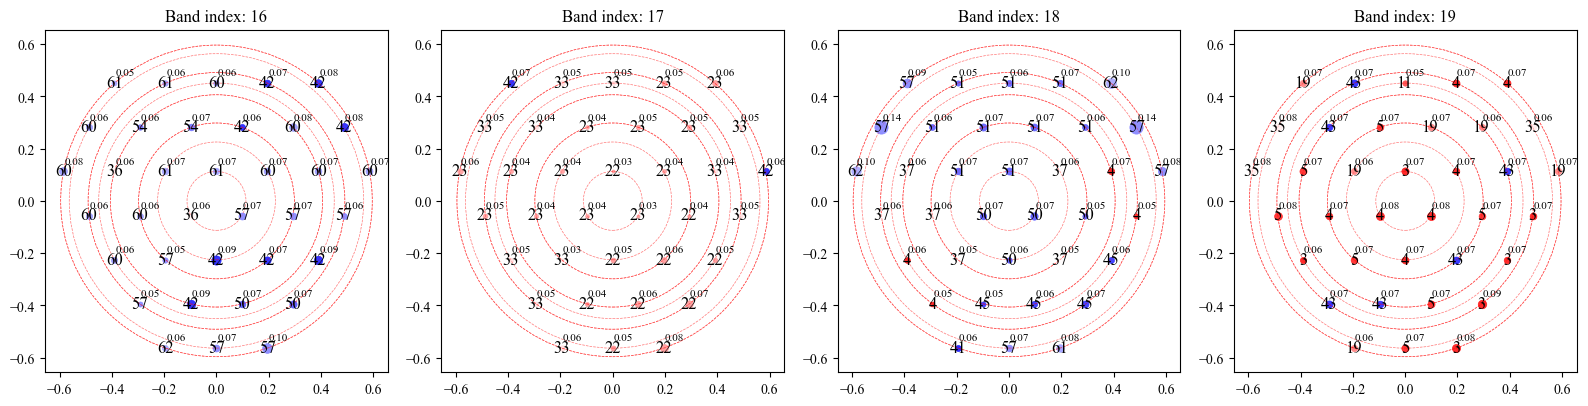

In [175]:
band_indices = [32,33, 34, 35]
band_indices = [16,17,18,19]
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, ga2se2_orb, index_1, max_id = -1, cmap_name='bwr_r')
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, ga2se2_orb, index_1, max_id = -2, cmap_name='bwr_r')
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, ga2se2_orb, index_1, max_id = -3, cmap_name='bwr_r')

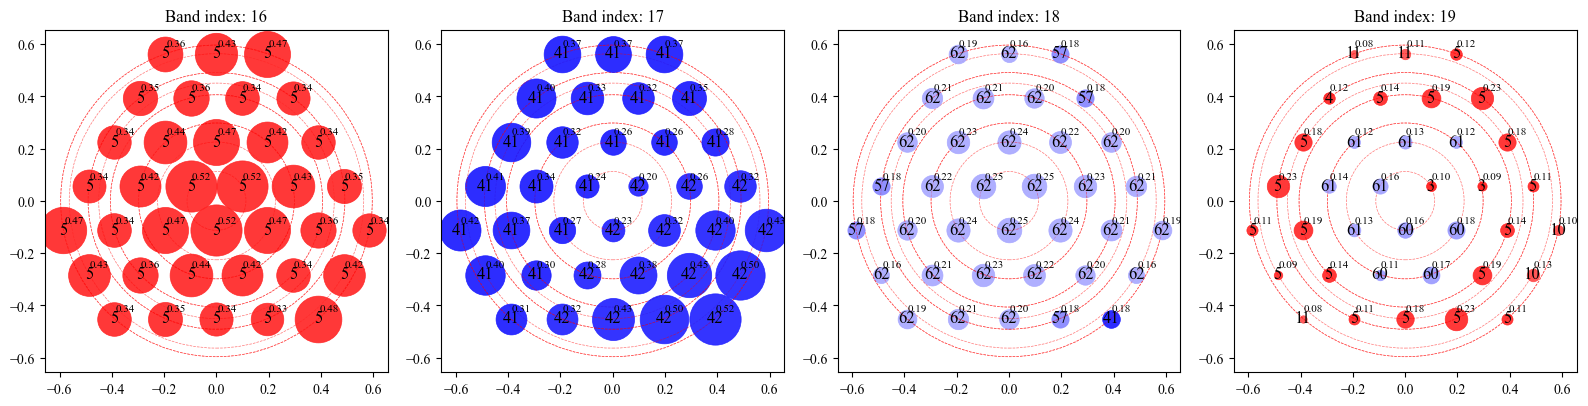

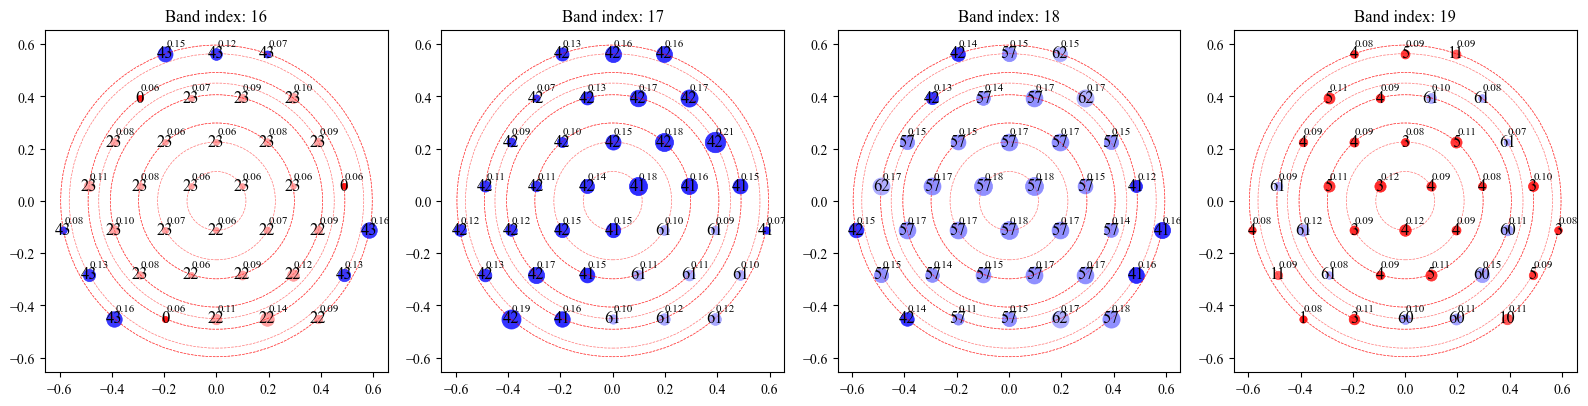

In [130]:
band_indices = [32,33, 34, 35]
band_indices = [16,17,18,19]
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set2, ga2se2_orb, index_2+len(Q_set1), max_id = -1, cmap_name='bwr_r')
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set2, ga2se2_orb, index_2+len(Q_set1), max_id = -2, cmap_name='bwr_r')
# plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set2, ga2se2_orb, index_2+len(Q_set1), max_id = -3, cmap_name='bwr_r')

In [250]:
H_GM_diag_eig[0,30:40]*hartree
H_GM_diag_eig[0,15:20]*hartree

array([-8.38118286, -7.43551147, -7.27466331, -3.36498416, -2.73116218])

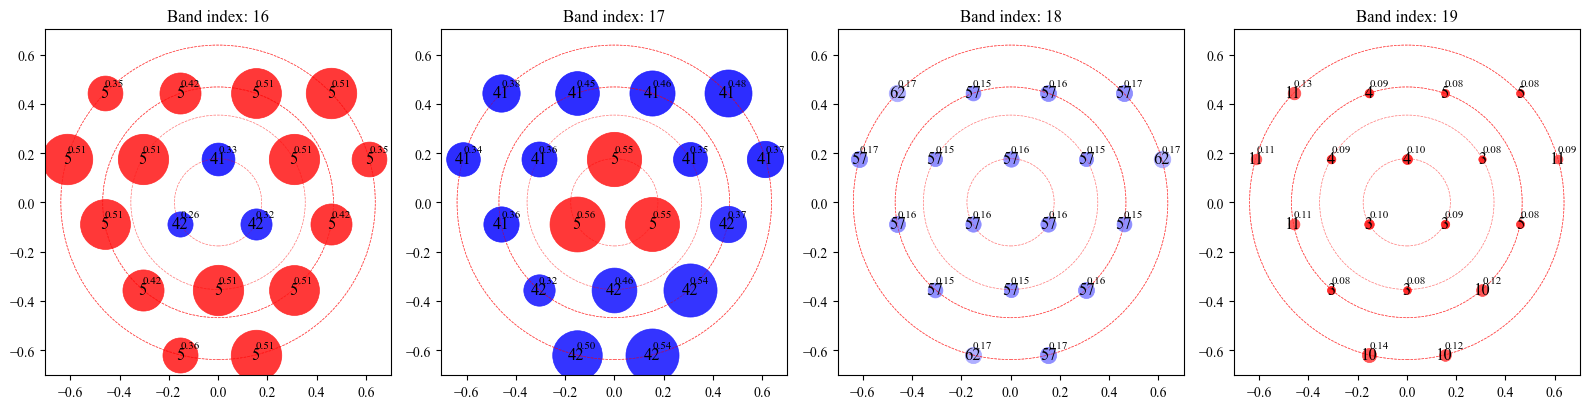

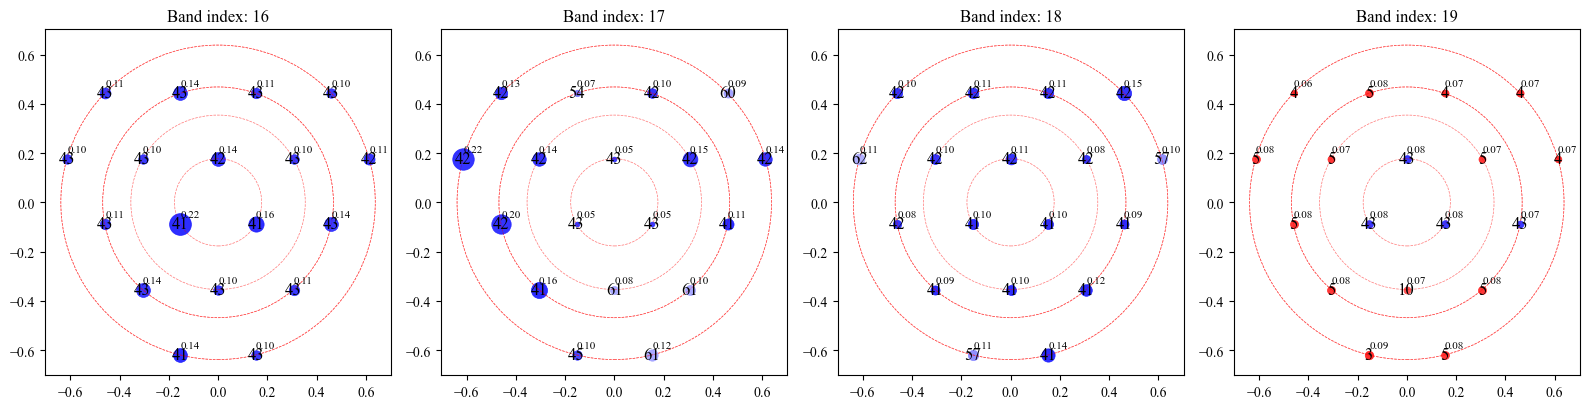

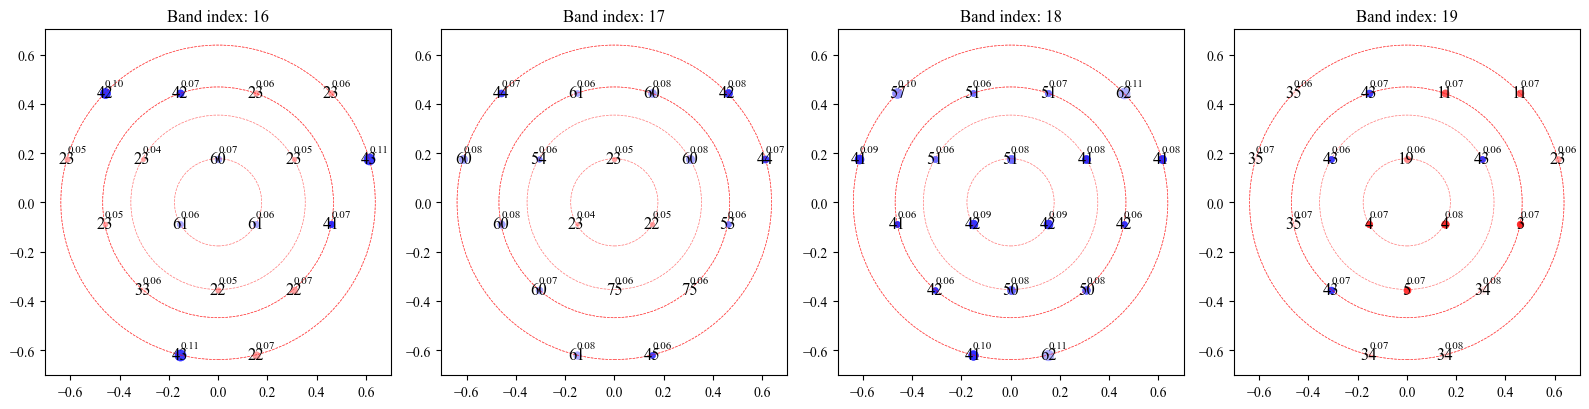

In [273]:
band_indices = [32,33, 34, 35]
band_indices = [16,17,18,19]
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, mote2_orb_6, index_1, max_id = -1, cmap_name='bwr_r')
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, mote2_orb_6, index_1, max_id = -2, cmap_name='bwr_r')
plot_orbital_scatter_multi(band_indices, H_GM_diag_eig_vec, Q_set1, mote2_orb_6, index_1, max_id = -3, cmap_name='bwr_r')

In [263]:
ga2se2_orb[[41,42,5,22]]

array(['Se$_2$1p$_x$', 'Se$_2$1p$_y$', 'Se$_1$1p$_z$', 'Ga$_2$1p$_x$'],
      dtype='<U20')

Text(0, 0.5, 'Energy (eV)')

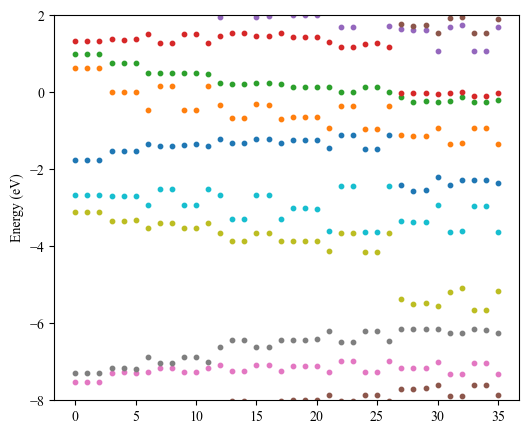

In [135]:
fig,ax = plt.subplots(figsize=(6, 5))
for i in range(np.shape(H_GM_diag_eig)[1]):
    ax.scatter(np.arange(36),H_GM_diag_eig[index_1,i]*hartree,s=10)
    # ax.plot(np.arange(19),H_GM_diag_eig[0][index_1,i]*hartree)
    # ax.scatter(np.arange(19*3),H_GM_diag_eig[0][:,i]*hartree)
ax.set_ylim(-4.8,-4.5)
ax.set_ylim(-8,2)
# ax.set_xlim(-1,20)
ax.set_ylabel(r'Energy (eV)')

In [148]:
eig,vec = np.linalg.eigh(hamk_gamma[0])

In [165]:
np.sum(np.abs(vec[:,-1][10944//2:])**2)

0.09021646737409068

In [171]:
K1_vec_up = np.load("/data/work/zy/software/TAPW_tmdc/tGa2Se2/5.09/2soc/Q_shell_8/K1_valley/K1_valley_down.npy")


In [175]:
K1_vec_up[0,:,-1].shape

(5472,)

In [174]:
np.sum(np.abs(K1_vec_up[0,:,-1])**2)

0.0021527897182319453

In [149]:
(eig*hartree)[2700:2800]

array([-5.12824834, -5.12093738, -5.12040352, -5.09484830, -5.09386533,
       -5.07979272, -5.06926107, -5.06726185, -5.06464044, -5.06013425,
       -5.05869390, -5.05532737, -5.05175550, -5.04086409, -5.03481193,
       -5.01587130, -5.01012312, -5.00363840, -4.98152204, -4.98066524,
       -4.98047622, -4.95980040, -4.94867303, -4.94071448, -4.92811570,
       -4.92234161, -4.91778283, -4.91266562, -4.89362331, -4.89142110,
       -4.88729018, -4.88712906, -4.88587667, -4.81433541, -4.79299929,
       -4.79225517, -4.01687581, -4.01343843, -4.01109871, -3.98995448,
       -3.98646283, -3.98441069, -3.93101712, -3.92165009, -3.92058773,
       -3.90177830, -3.89225322, -3.89099184, -3.68129260, -3.67628906,
       -3.67379414, -3.65949817, -3.65254772, -3.65013145, -3.62348018,
       -3.61908927, -3.61709605, -3.60953441, -3.60349147, -3.60153985,
       -3.59739208, -3.58986152, -3.58752067, -3.56341242, -3.55862439,
       -3.55774239, -3.54451739, -3.53942911, -3.53830085, -3.50

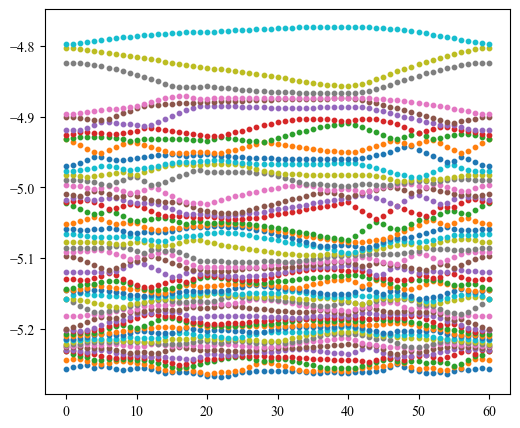

In [218]:
band_K1 = np.load("/data/work/zy/software/TAPW_tmdc/tGa2Se2/6.01/2soc/Q_shell_8/band_K1_shell_8_st_nsymm_eigsh_50_.npy")
# band_K1 = np.load("/data/work/zy/software/TAPW_tmdc/tMoS2/AA/3.89/2soc/Q_shell_4/band_K1_shell_4_st_nsymm_eigsh_50_.npy")
fig,ax = plt.subplots(figsize=(6, 5))
for i in range(np.shape(band_K1)[1]):
    ax.scatter(np.arange(len(band_K1)),band_K1[:,i]*hartree,s=10)

In [84]:
np.load("/data/work/zy/software/TAPW_tmdc/tGa2Se2/3.89/2soc/Q_shell_10/g_vec_list_10_K1_1layer.npy").shape

(48, 2)